# **RAG + RAGAS + EXTRA METRICS**

In [1]:
import subprocess
import sys

result = subprocess.run(
    [sys.executable, "-m", "pip", "freeze"],
    capture_output=True,
    text=True
)

print(result.stdout)

aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
annotated-doc==0.0.4
annotated-types==0.7.0
anyio==4.13.0
appdirs==1.4.4
asttokens==3.0.1
attrs==26.1.0
backoff==2.2.1
bcrypt==5.0.0
build==1.5.0
certifi==2026.4.22
charset-normalizer==3.4.7
chromadb==1.3.7
click==8.3.3
colorama==0.4.6
comm==0.2.3
contourpy==1.3.3
cycler==0.12.1
dataclasses-json==0.6.7
datasets==4.4.1
debugpy==1.8.20
decorator==5.2.1
dill==0.4.0
diskcache==5.6.3
distro==1.9.0
docstring_parser==0.18.0
durationpy==0.10
evaluate==0.4.6
executing==2.2.1
filelock==3.29.0
flatbuffers==25.12.19
fonttools==4.62.1
frozenlist==1.8.0
fsspec==2025.10.0
googleapis-common-protos==1.74.0
greenlet==3.5.0
grpcio==1.80.0
h11==0.16.0
hf-xet==1.4.3
httpcore==1.0.9
httptools==0.7.1
httpx==0.28.1
httpx-sse==0.4.3
huggingface-hub==0.36.0
idna==3.13
importlib_metadata==8.7.1
importlib_resources==7.1.0
instructor==1.15.1
ipykernel==7.2.0
ipython==9.13.0
ipython_pygments_lexers==1.1.1
jedi==0.20.0
Jinja2==3.1.6
jiter==0.13.0
joblib==1.5.3

In [2]:
import json
from pathlib import Path
from typing import List, Dict
import pandas as pd

BASE_DIR = Path("arabicaqa_rag_results/dataset")

# Optional: simple cleaner
def clean_text(text: str) -> str:
    if text is None:
        return ""
    return str(text).strip()

def flatten_qa_split(json_path: Path, split_name: str) -> pd.DataFrame:
    """
    Load one QA JSON file (MRC or Open-Domain with context)
    and flatten it into a DataFrame.
    """
    with open(json_path, "r", encoding="utf-8") as f:
        raw = json.load(f)

    records: List[Dict] = []

    for article in raw["data"]:
        for para in article["paragraphs"]:
            context = clean_text(para.get("context", ""))
            document_id = para.get("document_id")

            for qa in para["qas"]:
                question = clean_text(qa.get("question", ""))
                # base is_impossible flag (from file if present)
                is_impossible = bool(qa.get("is_impossible", False))

                answers_list = qa.get("answers", [])
                answer_texts = [clean_text(a.get("text", "")) for a in answers_list]

                # ---- NEW LOGIC: '.' = unanswerable ----
                # if the only answer is "." → treat as unanswerable
                has_only_dot = (
                    len(answer_texts) > 0
                    and all(ans == "." for ans in answer_texts)
                )

                if has_only_dot:
                    is_impossible = True
                    # Usually for unanswerable we keep answers empty
                    answer_texts = []

                # Also: if there are no answers at all, mark as impossible
                if len(answer_texts) == 0:
                    is_impossible = True

                records.append(
                    {
                        "split": split_name,       # train / validation / test
                        "document_id": document_id,
                        "question_id": qa.get("id"),
                        "question": question,
                        "context": context,
                        "answers": answer_texts,   # list of strings
                        "is_impossible": is_impossible,
                    }
                )

    return pd.DataFrame(records)

# ---- Build all three MRC splits ----
df_train_mrc = flatten_qa_split(BASE_DIR / "MRC" / "train.json", "train")
df_val_mrc   = flatten_qa_split(BASE_DIR / "MRC" / "validation.json", "validation")
df_test_mrc  = flatten_qa_split(BASE_DIR / "MRC" / "test.json", "test")

# (Optional) If Open-Domain uses the same structure & has context now:
# df_train_open = flatten_qa_split(BASE_DIR / "Open-Domain" / "train.json", "train")
# df_val_open   = flatten_qa_split(BASE_DIR / "Open-Domain" / "validation.json", "validation")
# df_test_open  = flatten_qa_split(BASE_DIR / "Open-Domain" / "test.json", "test")

# ---- Merge MRC into one DataFrame ----
df_all_mrc = pd.concat([df_train_mrc, df_val_mrc, df_test_mrc], ignore_index=True)

df_all_mrc.head()


,split,document_id,question_id,question,context,answers,is_impossible
0,train,1338857,645198,ما هو عدد المقاطعات في إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,[15],False
1,train,1338857,645409,ما هي أكبر طائفة مسيحية في إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,[الكنيسة الإنجيلية اللوثرية الإستونية],False
2,train,1338857,645410,كم عدد المسلمين في إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,[المسلمين يتجاوز عددهم 10000],False
3,train,1338857,645203,ما هو عدد سكان إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,"[1,319,133مليون نسمة]",False
4,train,1338857,645202,ما هي عاصمة إستونيا؟,إستونيا ، رسميًا جمهورية إستونيا ؛ هي دولة تقع...,[تالين],False


In [3]:
from pathlib import Path
import pandas as pd
import json

BASE_DIR = Path("arabicaqa_rag_results/dataset")
BASE_DIR.mkdir(parents=True, exist_ok=True)

df_export = df_all_mrc.copy()

list_columns = ["answers"] 

for col in list_columns:
    df_export[col] = df_export[col].apply(
        lambda x: json.dumps(x, ensure_ascii=False) if isinstance(x, list) else "[]"
    )

df_export.to_csv(BASE_DIR / "df_all_mrc.csv", index=False, encoding="utf-8-sig")

print("✅ df_all_mrc.csv saved")


✅ df_all_mrc.csv saved


In [4]:
import pandas as pd
import json

df_all_mrc = pd.read_csv("arabicaqa_rag_results/dataset/df_all_mrc.csv")

list_columns = ["answers"]

for col in list_columns:
    df_all_mrc[col] = df_all_mrc[col].apply(lambda x: json.loads(x) if isinstance(x, str) else [])


| **Category**            | **Training** | **Validation** | **Test** | **Total**  |
| ----------------------- | ------------ | -------------- | -------- | ---------- |
|<mark> **MRC (with answers)**  | 62,186       | 13,483         | 13,426   | **89,095**|
|<mark> **MRC (unanswerable)**  | 2,596        | 561            | 544      | **3,701**  |
| **Open-Domain**         | 62,057       | 13,475         | 13,414   | **88,946** |
| **Open-Domain (Human)** | 58,676       | 12,715         | 12,592   | **83,983** |

We will take a sample of **MRC (with answers)** and **MRC (unanswerable)** => 500 form each part => Total 1000

In [5]:
df_all_mrc["is_impossible"].value_counts()

is_impossible
False    89095
True      3701
Name: count, dtype: int64

In [6]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt

# ============= 1) Helper functions =============

def word_count(text: str) -> int:
    if pd.isna(text):
        return 0
    return len(str(text).split())

latin_pattern = re.compile(r"[A-Za-z]")

def foreign_word_count(text: str) -> int:
    if pd.isna(text):
        return 0
    tokens = str(text).split()
    return sum(1 for t in tokens if latin_pattern.search(t))


# ============= 2) Compute statistics =============

# Lengths
df_all_mrc["context_word_len"] = df_all_mrc["context"].apply(word_count)
df_all_mrc["question_word_len"] = df_all_mrc["question"].apply(word_count)

# Number of answers
def answers_len_safe(x):
    if isinstance(x, list):
        return len(x)
    return 0

df_all_mrc["n_answers"] = df_all_mrc["answers"].apply(answers_len_safe)

# Answer lengths (flatten all answers)
all_answer_lengths = []
for ans_list in df_all_mrc["answers"]:
    if isinstance(ans_list, list):
        for a in ans_list:
            all_answer_lengths.append(word_count(a))

mean_answer_len = float(np.mean(all_answer_lengths)) if all_answer_lengths else 0.0

# Foreign words in context
df_all_mrc["context_foreign_word_count"] = df_all_mrc["context"].apply(
    foreign_word_count
)

# Means
mean_context_len = df_all_mrc["context_word_len"].mean()
mean_question_len = df_all_mrc["question_word_len"].mean()
mean_n_answers = df_all_mrc["n_answers"].mean()
mean_foreign_per_context = df_all_mrc["context_foreign_word_count"].mean()

print("📊 Dataset stats (MRC):")
print(f"- Mean context length (words):        {mean_context_len:.2f}")
print(f"- Mean question length (words):       {mean_question_len:.2f}")
print(f"- Mean #answers per question:         {mean_n_answers:.2f}")
print(f"- Mean answer length (words, global): {mean_answer_len:.2f}")
print(f"- Mean foreign words per context:     {mean_foreign_per_context:.2f}")

📊 Dataset stats (MRC):
- Mean context length (words):        456.87
- Mean question length (words):       7.71
- Mean #answers per question:         0.96
- Mean answer length (words, global): 8.83
- Mean foreign words per context:     2.20


Saved → arabicaqa_rag_results/ragas_full\figures_full\full_means_bar.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_means_bar.pdf


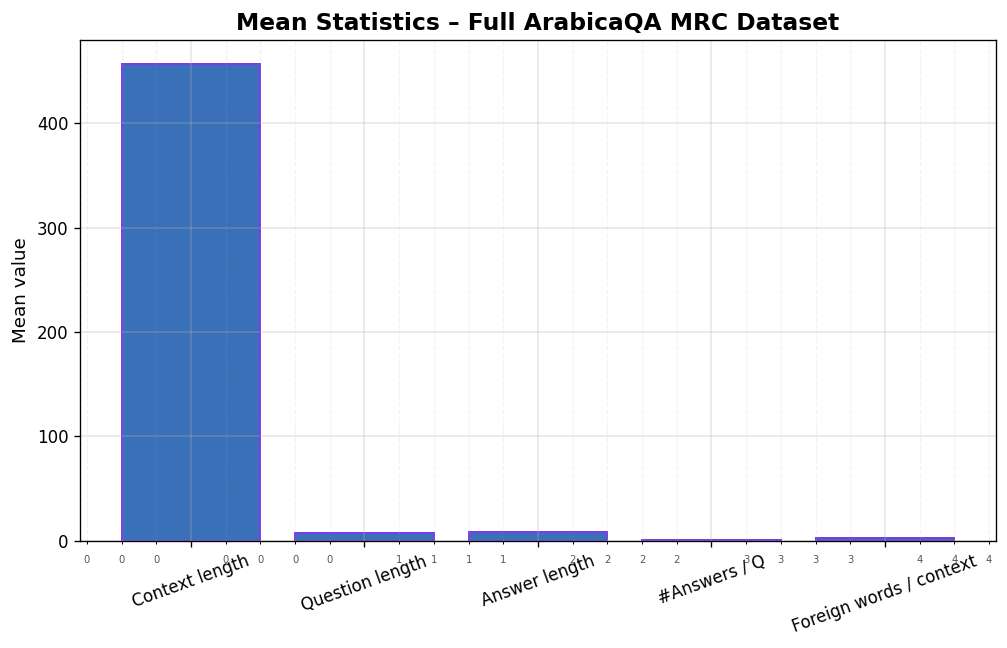

Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_context_length.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_context_length.pdf


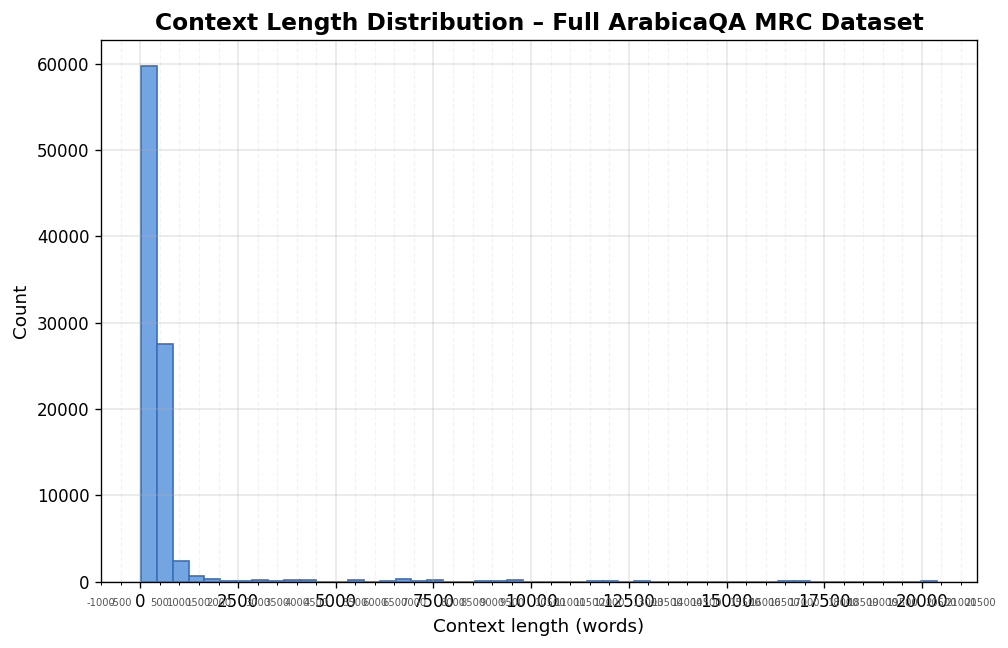

Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_question_length.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_question_length.pdf


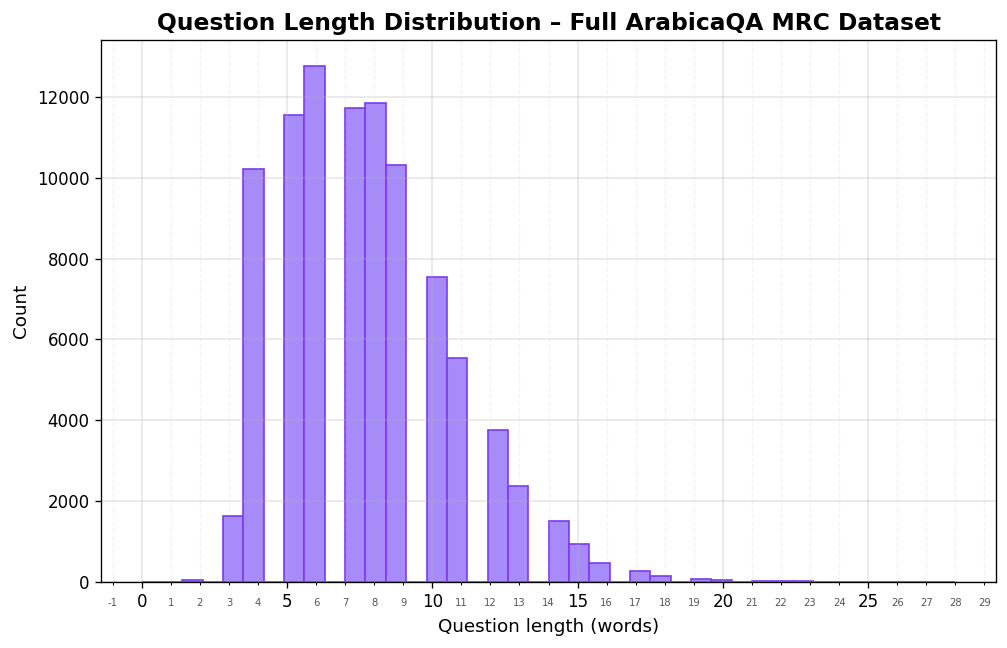

Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_answer_length.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_answer_length.pdf


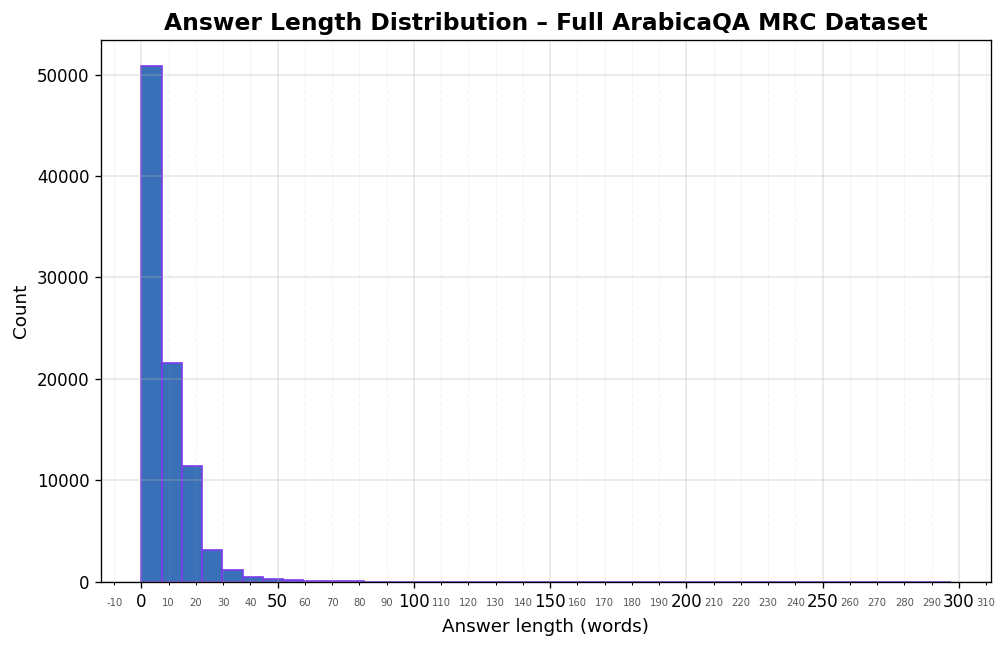

Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_foreign_words.png
Saved → arabicaqa_rag_results/ragas_full\figures_full\full_hist_foreign_words.pdf


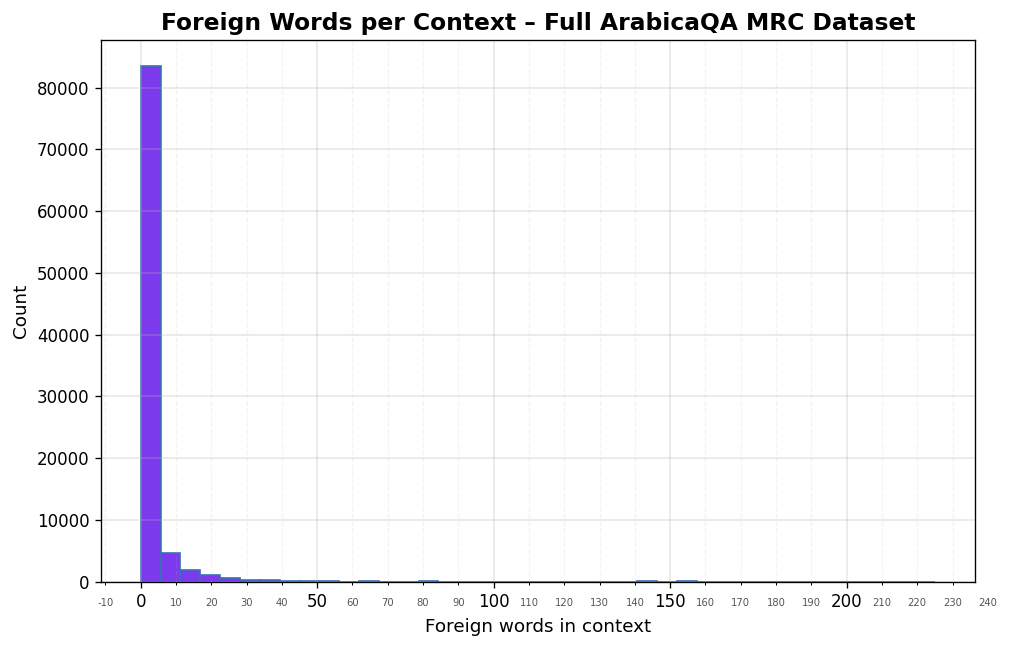

In [7]:
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ======================
# PATHS
# ======================
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures_full")
os.makedirs(FIG_DIR, exist_ok=True)

# ======================
# THEME
# ======================
PRIMARY   = "#3A70B8"   # Blue
SECONDARY = "#73A5E3"   # Light Blue
ACCENT1   = "#A78BFA"   # Light Purple
ACCENT2   = "#7C3AED"   # Purple

plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["figure.dpi"] = 120

def apply_style_with_minor_ticks(ax):
    """Apply theme + grid + minor ticks labels"""
    ax.grid(which="major", alpha=0.3, linewidth=1)
    ax.grid(which="minor", alpha=0.15, linestyle="--")

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))

    minor_ticks = ax.xaxis.get_minorticklocs()
    for tick in minor_ticks:
        ax.text(
            tick,
            -0.045,
            f"{int(tick)}",
            transform=ax.get_xaxis_transform(),
            fontsize=6,
            color="#555",
            ha="center"
        )

    plt.tight_layout()

def save_fig(name_base: str):
    """Save current figure as PNG + PDF."""
    png_path = os.path.join(FIG_DIR, f"{name_base}.png")
    pdf_path = os.path.join(FIG_DIR, f"{name_base}.pdf")
    plt.savefig(png_path, dpi=300, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    print("Saved →", png_path)
    print("Saved →", pdf_path)


# ======================================================
# 3) Bar plot of the means
# ======================================================
labels = [
    "Context length",
    "Question length",
    "Answer length",
    "#Answers / Q",
    "Foreign words / context",
]

values = [
    mean_context_len,
    mean_question_len,
    mean_answer_len,
    mean_n_answers,
    mean_foreign_per_context,
]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.bar(labels, values, color=PRIMARY, edgecolor=ACCENT2, linewidth=1.2)
ax.set_ylabel("Mean value")
ax.set_title("Mean Statistics – Full ArabicaQA MRC Dataset", fontsize=14)
ax.tick_params(axis="x", rotation=20)
apply_style_with_minor_ticks(ax)

save_fig("full_means_bar")
plt.show()


# ======================================================
# 4) Histograms for FULL DATA
# ======================================================

# ========= Context length =========
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_all_mrc["context_word_len"], bins=50, color=SECONDARY, edgecolor=PRIMARY)
ax.set_xlabel("Context length (words)")
ax.set_ylabel("Count")
ax.set_title("Context Length Distribution – Full ArabicaQA MRC Dataset", fontsize=14)
apply_style_with_minor_ticks(ax)

save_fig("full_hist_context_length")
plt.show()


# ========= Question length =========
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_all_mrc["question_word_len"], bins=40, color=ACCENT1, edgecolor=ACCENT2)
ax.set_xlabel("Question length (words)")
ax.set_ylabel("Count")
ax.set_title("Question Length Distribution – Full ArabicaQA MRC Dataset", fontsize=14)
apply_style_with_minor_ticks(ax)

save_fig("full_hist_question_length")
plt.show()


# ========= Answer length =========
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(all_answer_lengths, bins=40, color=PRIMARY, edgecolor=ACCENT2)
ax.set_xlabel("Answer length (words)")
ax.set_ylabel("Count")
ax.set_title("Answer Length Distribution – Full ArabicaQA MRC Dataset", fontsize=14)
apply_style_with_minor_ticks(ax)

save_fig("full_hist_answer_length")
plt.show()


# ========= Foreign words per context =========
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_all_mrc["context_foreign_word_count"], bins=40, color=ACCENT2, edgecolor=PRIMARY)
ax.set_xlabel("Foreign words in context")
ax.set_ylabel("Count")
ax.set_title("Foreign Words per Context – Full ArabicaQA MRC Dataset", fontsize=14)
apply_style_with_minor_ticks(ax)

save_fig("full_hist_foreign_words")
plt.show()


In [8]:
import pandas as pd
import json

# ========== 1) Read dataset ==========
df = pd.read_csv("arabicaqa_rag_results/dataset/df_all_mrc.csv")

# ========== 2) Decode list-like columns stored as JSON strings ==========
list_columns = ["answers"]  

for col in list_columns:
    df[col] = df[col].apply(
        lambda x: json.loads(x) if isinstance(x, str) and x.strip().startswith("[") else []
    )

# ========== 3) Split dataset into answerable / unanswerable ==========
df_answerable = df[df["is_impossible"] == False]
df_unanswerable = df[df["is_impossible"] == True]

# ========== 4) Sample 500 from each ==========
sample_answerable = df_answerable.sample(500, random_state=42)
sample_unanswerable = df_unanswerable.sample(500, random_state=42)

# ========== 5) Combine into final sample ==========
df_sample = pd.concat([sample_answerable, sample_unanswerable], ignore_index=True)

print("Sample shape:", df_sample.shape)
df_sample.head()


Sample shape: (1000, 7)


,split,document_id,question_id,question,context,answers,is_impossible
0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,[عام 2000],False
1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,[سبع حفريات],False
2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,[كصانع ألعاب],False
3,test,1582958,1068610,ما هي بعض المنتجات التي يمكن صنعها من القماش ا...,القماش الهَسِّيّ هو قماش منسوج يصنع عادة من أل...,[لصنع الحبال والشبكات والمنتجات المماثلة],False
4,test,1720179,1175188,ما هو مركز اللاعب رادو سابو؟,رادو سابو هو لاعب كرة قدم روماني في مركز الوسط...,[الوسط],False


In [9]:
import pandas as pd
import json

# ======================================================
# 1) Load the sample
# ======================================================

df_sample = df_sample.copy() 


# ======================================================
# 2) Helper: safe parsing for list-columns (answers)
# ======================================================

def safe_parse_list(x):
    """Return a clean Python list, fixing formatting problems."""
    
    if isinstance(x, list):
        return x
    
    if pd.isna(x):
        return []
    
    s = str(x).strip()
    if s == "":
        return []

    # Try JSON as-is
    try:
        return json.loads(s)
    except:
        pass
    
    # Try JSON with single-quotes replaced
    try:
        s2 = s.replace("'", '"')
        return json.loads(s2)
    except:
        pass
    
    # Fallback: return as single-item list
    return [s]


# ======================================================
# 3) Fix list-columns (answers)
# ======================================================

list_columns = ["answers"]

for col in list_columns:
    df_sample[col] = df_sample[col].apply(safe_parse_list)


# ======================================================
# 4) Clean other text columns: strip whitespace, ensure strings
# ======================================================

text_columns = ["question", "context"]

for col in text_columns:
    df_sample[col] = df_sample[col].fillna("").astype(str).str.strip()


# ======================================================
# 5) Optional safety checks (remove broken rows)
# ======================================================

# Remove empty context/question rows (rare but safe)
df_sample = df_sample[df_sample["question"] != ""]
df_sample = df_sample[df_sample["context"] != ""]

# Ensure is_impossible is boolean
df_sample["is_impossible"] = df_sample["is_impossible"].astype(bool)


# ======================================================
# 6) Save cleaned sample
# ======================================================

output_path = "arabicaqa_rag_results/dataset/df_sample_1000.csv"

# Convert lists into JSON before saving
df_to_save = df_sample.copy()
for col in list_columns:
    df_to_save[col] = df_to_save[col].apply(lambda x: json.dumps(x, ensure_ascii=False))

df_to_save.to_csv(output_path, index=False, encoding="utf-8-sig")

print("✨ Sample cleaned and saved to:", output_path)
print("Final shape:", df_sample.shape)


✨ Sample cleaned and saved to: arabicaqa_rag_results/dataset/df_sample_1000.csv
Final shape: (1000, 7)


In [10]:
import pandas as pd
import json

# ========== Load sample ==========
sample_path = "arabicaqa_rag_results/dataset/df_sample_1000.csv"
df_sample_loaded = pd.read_csv(sample_path)

# ========== Fix list columns after loading ==========
list_columns = ["answers"]

for col in list_columns:
    df_sample_loaded[col] = df_sample_loaded[col].apply(
        lambda x: json.loads(x) if isinstance(x, str) and x.strip().startswith("[") else []
    )

print("✨ Loaded sample shape:", df_sample_loaded.shape)
df_sample_loaded.head()


✨ Loaded sample shape: (1000, 7)


,split,document_id,question_id,question,context,answers,is_impossible
0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,[عام 2000],False
1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,[سبع حفريات],False
2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,[كصانع ألعاب],False
3,test,1582958,1068610,ما هي بعض المنتجات التي يمكن صنعها من القماش ا...,القماش الهَسِّيّ هو قماش منسوج يصنع عادة من أل...,[لصنع الحبال والشبكات والمنتجات المماثلة],False
4,test,1720179,1175188,ما هو مركز اللاعب رادو سابو؟,رادو سابو هو لاعب كرة قدم روماني في مركز الوسط...,[الوسط],False


In [11]:
import numpy as np
import re

def word_count(text: str) -> int:
    if pd.isna(text):
        return 0
    return len(str(text).split())

latin_pattern = re.compile(r"[A-Za-z]")

def foreign_word_count(text: str) -> int:
    if pd.isna(text):
        return 0
    tokens = str(text).split()
    return sum(1 for t in tokens if latin_pattern.search(t))


df_sample_loaded["context_word_len"] = df_sample_loaded["context"].apply(word_count)
df_sample_loaded["question_word_len"] = df_sample_loaded["question"].apply(word_count)

df_sample_loaded["n_answers"] = df_sample_loaded["answers"].apply(lambda x: len(x) if isinstance(x, list) else 0)

# answer lengths (global)
all_sample_answer_lengths = []
for ans_list in df_sample_loaded["answers"]:
    if isinstance(ans_list, list):
        for a in ans_list:
            all_sample_answer_lengths.append(word_count(a))

mean_context_len_s = df_sample_loaded["context_word_len"].mean()
mean_question_len_s = df_sample_loaded["question_word_len"].mean()
mean_n_answers_s = df_sample_loaded["n_answers"].mean()
mean_answer_len_s = np.mean(all_sample_answer_lengths) if all_sample_answer_lengths else 0
df_sample_loaded["foreign_words"] = df_sample_loaded["context"].apply(foreign_word_count)
mean_foreign_s = df_sample_loaded["foreign_words"].mean()

print("📊 Sample stats:")
print(f"- Mean context length (words):        {mean_context_len_s:.2f}")
print(f"- Mean question length (words):       {mean_question_len_s:.2f}")
print(f"- Mean #answers per question:         {mean_n_answers_s:.2f}")
print(f"- Mean answer length (words, global): {mean_answer_len_s:.2f}")
print(f"- Mean foreign words per context:     {mean_foreign_s:.2f}")


📊 Sample stats:
- Mean context length (words):        372.58
- Mean question length (words):       8.24
- Mean #answers per question:         0.50
- Mean answer length (words, global): 8.47
- Mean foreign words per context:     1.90


In [12]:
print("df_sample_loaded rows:", len(df_sample_loaded))
print("context_word_len non-null:", df_sample_loaded["context_word_len"].notna().sum())
print("unique context_word_len:", df_sample_loaded["context_word_len"].nunique(dropna=True))
print(df_sample_loaded["context_word_len"].describe())


df_sample_loaded rows: 1000
context_word_len non-null: 1000
unique context_word_len: 484
count    1000.000000
mean      372.585000
std       588.171091
min        12.000000
25%        89.000000
50%       296.500000
75%       500.000000
max      9463.000000
Name: context_word_len, dtype: float64


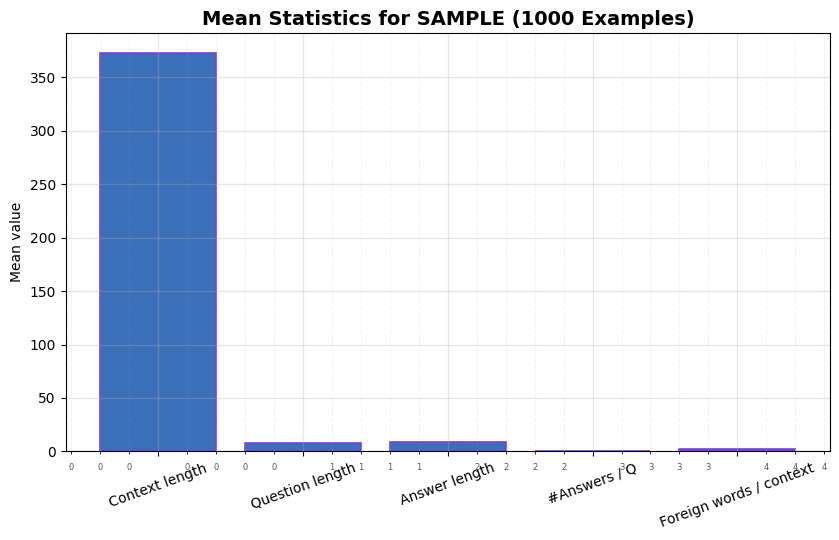

Saved → arabicaqa_rag_results/ragas_full\figures\mean_statistics_sample.png
Saved → arabicaqa_rag_results/ragas_full\figures\mean_statistics_sample.pdf


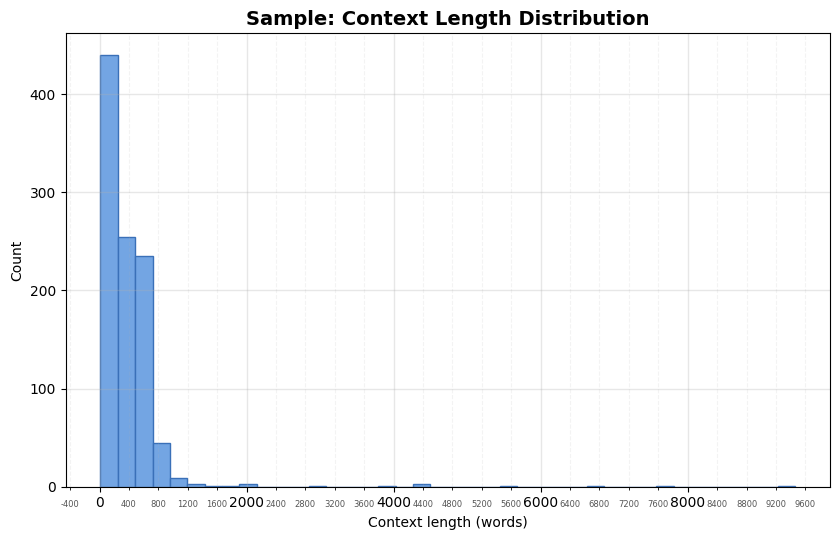

Saved → arabicaqa_rag_results/ragas_full\figures\hist_context_length.png
Saved → arabicaqa_rag_results/ragas_full\figures\hist_context_length.pdf


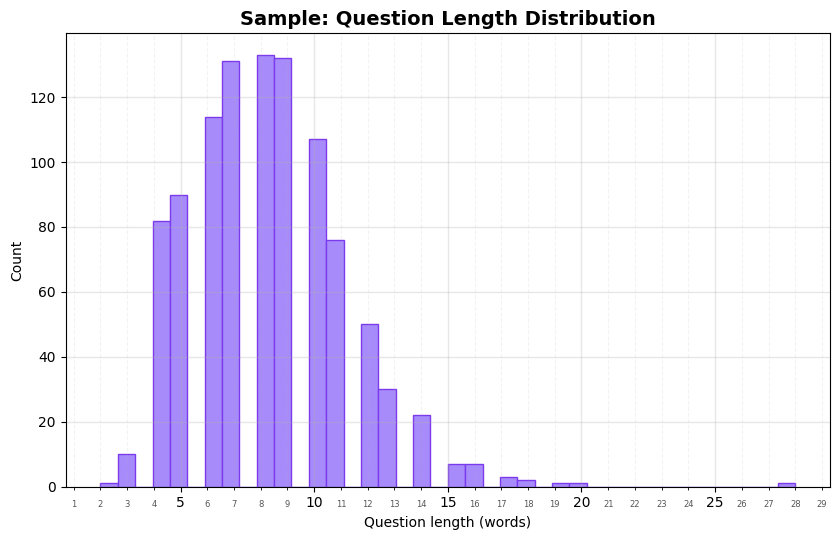

Saved → arabicaqa_rag_results/ragas_full\figures\hist_question_length.png
Saved → arabicaqa_rag_results/ragas_full\figures\hist_question_length.pdf


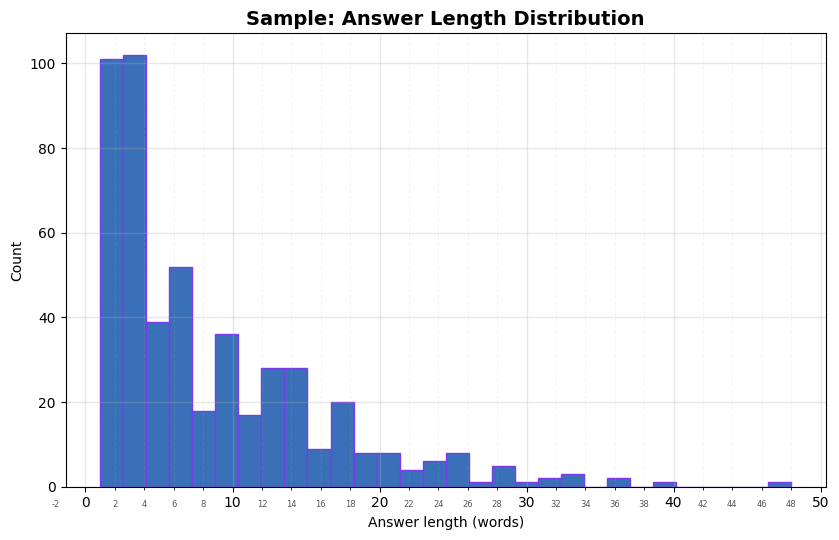

Saved → arabicaqa_rag_results/ragas_full\figures\hist_answer_length.png
Saved → arabicaqa_rag_results/ragas_full\figures\hist_answer_length.pdf


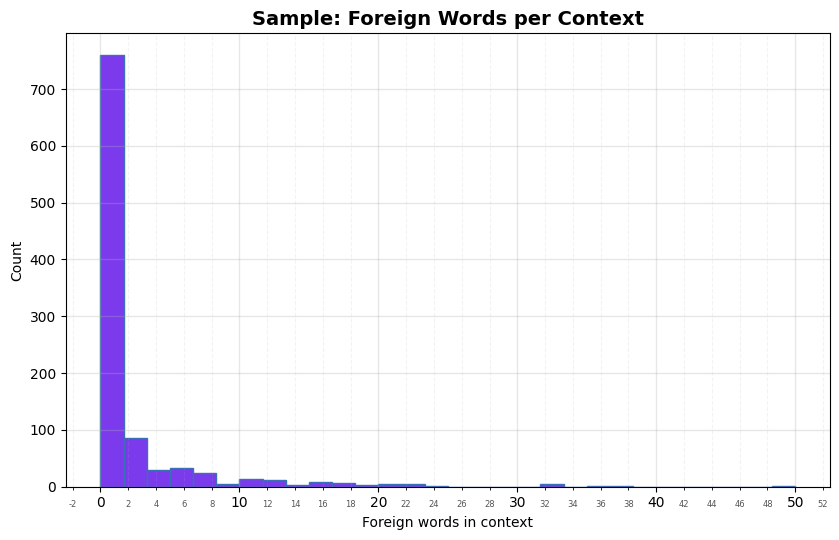

Saved → arabicaqa_rag_results/ragas_full\figures\hist_foreign_words.png
Saved → arabicaqa_rag_results/ragas_full\figures\hist_foreign_words.pdf


In [13]:
import os
import matplotlib.pyplot as plt
from matplotlib.ticker import AutoMinorLocator

# ======================
# PATHS
# ======================
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ======================
# THEME
# ======================
plt.style.use("default")

PRIMARY   = "#3A70B8"   # Blue
SECONDARY = "#73A5E3"   # Light Blue
ACCENT1   = "#A78BFA"   # Light Purple
ACCENT2   = "#7C3AED"   # Purple


def apply_style_with_minor_ticks(ax):
    """Apply theme + grid + minor ticks with small labels"""
    ax.grid(which="major", alpha=0.3, linewidth=1)
    ax.grid(which="minor", alpha=0.15, linestyle="--")

    ax.xaxis.set_minor_locator(AutoMinorLocator(5))

    minor_ticks = ax.xaxis.get_minorticklocs()
    for tick in minor_ticks:
        ax.text(
            tick,
            -0.045,
            f"{int(tick)}",
            transform=ax.get_xaxis_transform(),
            fontsize=6,
            color="#555555",
            ha="center"
        )

    plt.tight_layout()


# =====================================================
# 1) BAR CHART — MEAN STATISTICS
# =====================================================
labels = [
    "Context length",
    "Question length",
    "Answer length",
    "#Answers / Q",
    "Foreign words / context",
]

values = [
    mean_context_len_s,
    mean_question_len_s,
    mean_answer_len_s,
    mean_n_answers_s,
    mean_foreign_s,
]

fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.bar(labels, values, color=PRIMARY, edgecolor=ACCENT2, linewidth=1.2)
ax.set_ylabel("Mean value")
ax.set_title("Mean Statistics for SAMPLE (1000 Examples)", fontsize=14, weight="bold")
ax.tick_params(axis="x", rotation=20)

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "mean_statistics_sample.png")
pdf = os.path.join(FIG_DIR, "mean_statistics_sample.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


# =====================================================
# 2) HISTOGRAM — CONTEXT LENGTH
# =====================================================
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_sample_loaded["context_word_len"], bins=40,
        color=SECONDARY, edgecolor=PRIMARY)

ax.set_xlabel("Context length (words)")
ax.set_ylabel("Count")
ax.set_title("Sample: Context Length Distribution", fontsize=14, weight="bold")

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "hist_context_length.png")
pdf = os.path.join(FIG_DIR, "hist_context_length.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


# =====================================================
# 3) HISTOGRAM — QUESTION LENGTH
# =====================================================
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_sample_loaded["question_word_len"], bins=40,
        color=ACCENT1, edgecolor=ACCENT2)

ax.set_xlabel("Question length (words)")
ax.set_ylabel("Count")
ax.set_title("Sample: Question Length Distribution", fontsize=14, weight="bold")

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "hist_question_length.png")
pdf = os.path.join(FIG_DIR, "hist_question_length.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


# =====================================================
# 4) HISTOGRAM — ANSWER LENGTH
# =====================================================
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(all_sample_answer_lengths, bins=30,
        color=PRIMARY, edgecolor=ACCENT2)

ax.set_xlabel("Answer length (words)")
ax.set_ylabel("Count")
ax.set_title("Sample: Answer Length Distribution", fontsize=14, weight="bold")

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "hist_answer_length.png")
pdf = os.path.join(FIG_DIR, "hist_answer_length.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


# =====================================================
# 5) HISTOGRAM — FOREIGN WORDS PER CONTEXT
# =====================================================
fig, ax = plt.subplots(figsize=(8.5, 5.5))
ax.hist(df_sample_loaded["foreign_words"], bins=30,
        color=ACCENT2, edgecolor=PRIMARY)

ax.set_xlabel("Foreign words in context")
ax.set_ylabel("Count")
ax.set_title("Sample: Foreign Words per Context", fontsize=14, weight="bold")

apply_style_with_minor_ticks(ax)

png = os.path.join(FIG_DIR, "hist_foreign_words.png")
pdf = os.path.join(FIG_DIR, "hist_foreign_words.pdf")
plt.savefig(png, dpi=300, bbox_inches="tight")
plt.savefig(pdf, bbox_inches="tight")
plt.show()

print("Saved →", png)
print("Saved →", pdf)


In [2]:
import pandas as pd
import json

# ========== Load sample ==========
sample_path = "arabicaqa_rag_results/dataset/df_sample_1000.csv"
df_sample_loaded = pd.read_csv(sample_path)

# ========== Fix list columns after loading ==========
list_columns = ["answers"]

for col in list_columns:
    df_sample_loaded[col] = df_sample_loaded[col].apply(
        lambda x: json.loads(x) if isinstance(x, str) and x.strip().startswith("[") else []
    )

print("✨ Loaded sample shape:", df_sample_loaded.shape)
df_sample_loaded.head()


✨ Loaded sample shape: (1000, 7)


,split,document_id,question_id,question,context,answers,is_impossible
0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,[عام 2000],False
1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,[سبع حفريات],False
2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,[كصانع ألعاب],False
3,test,1582958,1068610,ما هي بعض المنتجات التي يمكن صنعها من القماش ا...,القماش الهَسِّيّ هو قماش منسوج يصنع عادة من أل...,[لصنع الحبال والشبكات والمنتجات المماثلة],False
4,test,1720179,1175188,ما هو مركز اللاعب رادو سابو؟,رادو سابو هو لاعب كرة قدم روماني في مركز الوسط...,[الوسط],False


In [3]:
from transformers import AutoTokenizer, AutoModelForTokenClassification, pipeline
import pandas as pd
from tqdm import tqdm
from collections import Counter

model_id = "CAMeL-Lab/bert-base-arabic-camelbert-msa-ner"

tokenizer = AutoTokenizer.from_pretrained(model_id)
model = AutoModelForTokenClassification.from_pretrained(model_id)

ner = pipeline(
    "ner",
    model=model,
    tokenizer=tokenizer,
    aggregation_strategy="simple"
)

def get_entity_counts(texts, max_tokens=512):
    entity_counter = Counter()
    for t in tqdm(texts):
        if not isinstance(t, str) or not t.strip():
            continue

        enc = tokenizer(
            t,
            truncation=True,
            max_length=max_tokens,
            return_tensors=None
        )
       
        input_ids = enc["input_ids"]
       
        if isinstance(input_ids[0], int):
            truncated_text = tokenizer.decode(input_ids, skip_special_tokens=True)
        else:
            truncated_text = tokenizer.decode(input_ids[0], skip_special_tokens=True)

        ents = ner(truncated_text)
        for e in ents:
            entity_counter[e["entity_group"]] += 1

    return entity_counter


# ==============================
# SAMPLE entities (ACTIVE)
# ==============================
sample_contexts = df_sample_loaded["context"].dropna().tolist()

sample_entity_counts = get_entity_counts(sample_contexts)

print("\n=== SAMPLE NER STATISTICS ===")
for k, v in sample_entity_counts.items():
    print(f"{k}: {v}")

df_ner = pd.DataFrame({
    "entity_type": list(sample_entity_counts.keys()),
    "sample": list(sample_entity_counts.values()),
})
df_ner.head()


Loading weights: 100%|██████████| 199/199 [00:00<00:00, 17135.07it/s]
[transformers] BertForTokenClassification LOAD REPORT from: CAMeL-Lab/bert-base-arabic-camelbert-msa-ner
Key                      | Status     |  | 
-------------------------+------------+--+-
bert.pooler.dense.weight | UNEXPECTED |  | 
bert.pooler.dense.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
100%|██████████| 1000/1000 [08:16<00:00,  2.02it/s]


=== SAMPLE NER STATISTICS ===
ORG: 2058
LOC: 11581
PERS: 6686
MISC: 3737


,entity_type,sample
0,ORG,2058
1,LOC,11581
2,PERS,6686
3,MISC,3737


In [2]:
import pandas as pd

ner_results_path = "arabicaqa_rag_results/dataset/sample_ner_counts.csv"

df_ner_loaded = pd.read_csv(ner_results_path)

print("✨ Loaded NER results:")
print(df_ner_loaded.head())


✨ Loaded NER results:
  entity_type  sample
0         ORG    2058
1         LOC   11581
2        PERS    6686
3        MISC    3737


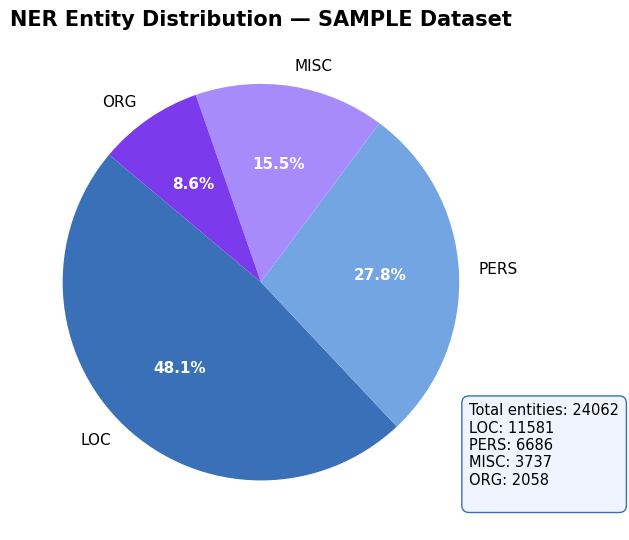

Saved → arabicaqa_rag_results/ragas_full\figures\ner_entity_distribution_pie.png
Saved → arabicaqa_rag_results/ragas_full\figures\ner_entity_distribution_pie.pdf


In [3]:
import os
import matplotlib.pyplot as plt

# ====== Theme colors ======
PRIMARY   = "#3A70B8"   # Blue
SECONDARY = "#73A5E3"   # Light Blue
ACCENT1   = "#A78BFA"   # Light Purple
ACCENT2   = "#7C3AED"   # Purple

colors = [PRIMARY, SECONDARY, ACCENT1, ACCENT2, "#4FB6A0", "#F2A93B", "#D96459"]

# ======================
# PATHS
# ======================
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

# ======================
# PREPARE DATA
# ======================
df_plot = df_ner_loaded.sort_values("sample", ascending=False)

labels = df_plot["entity_type"].astype(str).tolist()
sizes  = df_plot["sample"].astype(float).tolist()

total_entities = int(sum(sizes))

# ======================
# PIE CHART
# ======================
fig, ax = plt.subplots(figsize=(6.5, 5.5))

patches, texts, autotexts = ax.pie(
    sizes,
    labels=labels,
    autopct="%1.1f%%",
    colors=colors[:len(labels)],
    startangle=140,
    textprops={"fontsize": 11}
)

# improve label style on wedges
for autotext in autotexts:
    autotext.set_color("white")
    autotext.set_fontsize(11)
    autotext.set_weight("bold")

ax.set_title("NER Entity Distribution — SAMPLE Dataset", fontsize=15, weight="bold")

# ========= Inset Box ==========
box_text = f"Total entities: {total_entities}\n"
for ent, count in zip(labels, sizes):
    box_text += f"{ent}: {int(count)}\n"

props = dict(boxstyle="round,pad=0.5", facecolor="#F0F4FF", edgecolor=PRIMARY)

ax.text(
    0.92, 0.05,                 # box position inside axes
    box_text,
    transform=ax.transAxes,
    fontsize=10.5,
    verticalalignment="bottom",
    horizontalalignment="left",
    bbox=props
)

plt.tight_layout()

# ======================
# SAVE
# ======================
png_path = os.path.join(FIG_DIR, "ner_entity_distribution_pie.png")
pdf_path = os.path.join(FIG_DIR, "ner_entity_distribution_pie.pdf")

plt.savefig(png_path, dpi=300, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()

print(f"Saved → {png_path}")
print(f"Saved → {pdf_path}")


# **RAG Pipeline**

In [1]:
import pandas as pd
import json

# ========== Load sample ==========
sample_path = "arabicaqa_rag_results/dataset/df_sample_1000.csv"
df_sample_loaded = pd.read_csv(sample_path)

# ========== Fix list columns after loading ==========
list_columns = ["answers"]

for col in list_columns:
    df_sample_loaded[col] = df_sample_loaded[col].apply(
        lambda x: json.loads(x) if isinstance(x, str) and x.strip().startswith("[") else []
    )

print("✨ Loaded sample shape:", df_sample_loaded.shape)
df_sample_loaded.head()


✨ Loaded sample shape: (1000, 7)


,split,document_id,question_id,question,context,answers,is_impossible
0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,[عام 2000],False
1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,[سبع حفريات],False
2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,[كصانع ألعاب],False
3,test,1582958,1068610,ما هي بعض المنتجات التي يمكن صنعها من القماش ا...,القماش الهَسِّيّ هو قماش منسوج يصنع عادة من أل...,[لصنع الحبال والشبكات والمنتجات المماثلة],False
4,test,1720179,1175188,ما هو مركز اللاعب رادو سابو؟,رادو سابو هو لاعب كرة قدم روماني في مركز الوسط...,[الوسط],False


In [2]:
from langchain_text_splitters import RecursiveCharacterTextSplitter
from langchain_community.embeddings import HuggingFaceEmbeddings
from langchain_community.vectorstores import Chroma
from langchain_community.llms import Ollama
from langchain_classic.chains import RetrievalQA


print("✅ all imports OK (new LangChain)")


c:\Users\Zohoor Almalki\Projects\NLP\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


✅ all imports OK (new LangChain)


In [3]:
# ========= 1) corpus with document_id =========
unique_contexts = (
    df_sample_loaded[["document_id", "context"]]
    .dropna(subset=["context"])
    .drop_duplicates(subset=["document_id"])
    .reset_index(drop=True)
)

len(unique_contexts), unique_contexts.iloc[0]["context"][:200]


(919,
 'توب غولف هي شركة ترفيهية رياضية عالمية مقرها في دالاس، تكساس ولها مواقع في الولايات المتحدة والمملكة المتحدة وأستراليا والمكسيك ودبي. تم الاستحواذ على الشركة من قبل Callaway Golf المتداولة علنًا في ما')

In [4]:
from langchain_core.documents import Document
from langchain_text_splitters import RecursiveCharacterTextSplitter

text_splitter = RecursiveCharacterTextSplitter(chunk_size=500, chunk_overlap=100)

unique_contexts = (
    df_sample_loaded[["document_id", "context"]]
    .dropna(subset=["context"])
    .drop_duplicates(subset=["document_id"])
    .reset_index(drop=True)
)

docs = []
for _, row in unique_contexts.iterrows():
    doc_id = int(row["document_id"])
    text = row["context"]

    chunks = text_splitter.split_text(text)
    for i, chunk in enumerate(chunks):
        docs.append(
            Document(
                page_content=chunk,
                metadata={"document_id": doc_id, "chunk_id": i}
            )
        )

print("Example metadata:", docs[0].metadata)
print(f"✅ Created {len(docs)} chunks")


Example metadata: {'document_id': 1732461, 'chunk_id': 0}
✅ Created 6026 chunks


In [5]:
import os
import gc
import time

import chromadb
from langchain_community.vectorstores import Chroma
from langchain_community.embeddings import HuggingFaceEmbeddings
from tqdm.auto import tqdm

# ============================================================
# Chroma configuration
# ============================================================
CHROMA_DIR = "chroma_arabicaqa_docid"
COLLECTION_NAME = "arabicaqa_mrc_v1_docid"

# ============================================================
# Release old in-memory references if they exist
# ============================================================
for var_name in ["retriever", "vectordb", "vectorstore", "db", "client", "collection"]:
    if var_name in globals():
        try:
            del globals()[var_name]
            print(f"Deleted old variable reference: {var_name}")
        except Exception as e:
            print(f"Could not delete variable reference {var_name}: {e}")

gc.collect()
time.sleep(1)

# ============================================================
# Reset the Chroma collection without deleting the directory
# ============================================================
# This keeps the same CHROMA_DIR path while removing old persisted chunks
# from the target collection. It avoids Windows file-lock errors caused by
# deleting the full directory while Chroma files are still locked.

os.makedirs(CHROMA_DIR, exist_ok=True)

client = chromadb.PersistentClient(path=CHROMA_DIR)

try:
    client.delete_collection(COLLECTION_NAME)
    print(f"Deleted old Chroma collection: {COLLECTION_NAME}")
except Exception as e:
    print(f"No existing collection deleted, or collection was not found: {e}")

gc.collect()
time.sleep(1)

# ============================================================
# Create embeddings
# ============================================================
embeddings = HuggingFaceEmbeddings(
    model_name="sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2"
)

# ============================================================
# Recreate Chroma vector store in the same directory
# ============================================================
vectordb = Chroma(
    collection_name=COLLECTION_NAME,
    embedding_function=embeddings,
    persist_directory=CHROMA_DIR,
    client=client,
)

# ============================================================
# Add documents using stable unique IDs
# ============================================================
BATCH_SIZE = 5000

for i in tqdm(range(0, len(docs), BATCH_SIZE)):
    batch_docs = docs[i : i + BATCH_SIZE]

    # Stable unique IDs prevent duplicated documents inside Chroma.
    batch_ids = [
        f"doc_{d.metadata['document_id']}_chunk_{d.metadata['chunk_id']}"
        for d in batch_docs
    ]

    vectordb.add_documents(batch_docs, ids=batch_ids)

# ============================================================
# Persist the vector store and create the retriever
# ============================================================
vectordb.persist()

retriever = vectordb.as_retriever(search_kwargs={"k": 5})

print("✅ Chroma collection rebuilt without duplicated persisted chunks.")
print(f"✅ Chroma directory used: {CHROMA_DIR}")
print(f"✅ Chroma collection used: {COLLECTION_NAME}")

# ============================================================
# Verify that Chroma was rebuilt without duplicated chunks
# ============================================================

source_count = len(docs)
chroma_count = vectordb._collection.count()

print("Number of source docs:", source_count)
print("Number of Chroma docs:", chroma_count)

assert chroma_count == source_count, (
    f"Chroma count mismatch. Expected {source_count}, but found {chroma_count}. "
    "This may indicate duplicated or missing chunks."
)

print("✅ Verified: Chroma contains exactly one entry per source chunk.")


Deleted old Chroma collection: arabicaqa_mrc_v1_docid


C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_9336\2446374920.py:53: LangChainDeprecationWarning: The class `HuggingFaceEmbeddings` was deprecated in LangChain 0.2.2 and will be removed in 1.0. An updated version of the class exists in the `langchain-huggingface package and should be used instead. To use it run `pip install -U `langchain-huggingface` and import as `from `langchain_huggingface import HuggingFaceEmbeddings``.
  embeddings = HuggingFaceEmbeddings(
C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_9336\2446374920.py:60: LangChainDeprecationWarning: The class `Chroma` was deprecated in LangChain 0.2.9 and will be removed in 1.0. An updated version of the class exists in the `langchain-chroma package and should be used instead. To use it run `pip install -U `langchain-chroma` and import as `from `langchain_chroma import Chroma``.
  vectordb = Chroma(
100%|██████████| 2/2 [03:59<00:00, 119.91s/it]

✅ Chroma collection rebuilt without duplicated persisted chunks.
✅ Chroma directory used: chroma_arabicaqa_docid
✅ Chroma collection used: arabicaqa_mrc_v1_docid
Number of source docs: 6026
Number of Chroma docs: 6026
✅ Verified: Chroma contains exactly one entry per source chunk.



C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_9336\2446374920.py:86: LangChainDeprecationWarning: Since Chroma 0.4.x the manual persistence method is no longer supported as docs are automatically persisted.
  vectordb.persist()


In [6]:
def deduplicate_docs_by_content_and_id(docs):
    seen = set()
    unique_docs = []

    for d in docs:
        key = (
            d.metadata.get("document_id"),
            d.metadata.get("chunk_id"),
            d.page_content.strip()
        )

        if key not in seen:
            unique_docs.append(d)
            seen.add(key)

    return unique_docs

question = df_sample_loaded.iloc[0]["question"]

retrieved_docs = retriever.invoke(question)
retrieved_docs = deduplicate_docs_by_content_and_id(retrieved_docs)

retrieved_contexts = [d.page_content for d in retrieved_docs]
retrieved_doc_ids = [d.metadata.get("document_id") for d in retrieved_docs]
retrieved_chunk_ids = [d.metadata.get("chunk_id") for d in retrieved_docs]

print(question)
print(retrieved_doc_ids)
print(retrieved_chunk_ids)
print(retrieved_contexts[0][:300])

متي تم بناء الموقع الأول لشركة توب غولف؟
[1732461, 1732461, 1727247, 1364429, 1583150]
[4, 5, 1, 5, 3]
في المملكة المتحدة. بعد ستة أشهر، كان لدى منشأة دالاس انتظار لمدة ست ساعات. استحوذت شركة توب غولف أنترناشيونال (الولايات المتحدة) على توب غولف (المملكة البريطانية) في عام 2009. ومن ثم في يوليو استحوذت على ورلد غولف سيستيمس وبالتحديد الجوانب الملكية الفكرية. وفي عام 2011 أصبح إريك أندرسون الرئيس التن


In [7]:
q = df_sample_loaded.iloc[0]["question"]

retrieved_docs = retriever.invoke(q)
for i, d in enumerate(retrieved_docs):
    print(i)
    print(d.metadata)
    print(d.page_content[:150])
    print("-" * 80)

0
{'chunk_id': 4, 'document_id': 1732461}
في المملكة المتحدة. بعد ستة أشهر، كان لدى منشأة دالاس انتظار لمدة ست ساعات. استحوذت شركة توب غولف أنترناشيونال (الولايات المتحدة) على توب غولف (المملك
--------------------------------------------------------------------------------
1
{'document_id': 1732461, 'chunk_id': 5}
توب غولف إلى 163 مليون دولار. بحلول عام 2015، كان لدى توب غولف 28 موقعاً وجلبت لهم 8 ملايين زائر. اشترت توب غولف شركة «ورلد جلف تور» للألعاب في 2016. 
--------------------------------------------------------------------------------
2
{'chunk_id': 1, 'document_id': 1727247}
إلى 70 متجرًا في المملكة المتحدة، وتَقررأن العلامة التجارية بحاجة إلى هوية جديدة. تمت إعادة تسمية لويس باسم تشيلسي جيرل، ويعود اختيارهذا الاسم في ذلك 
--------------------------------------------------------------------------------
3
{'chunk_id': 5, 'document_id': 1364429}
تعُود الفكرة الرئيسيَّة وراء إعادة تنّظيم المعلومات حول مواقع الويب إلى عام 1995، عندما طور ومُطورون آخرون من مختبر أبحاث كمبيوتر أبل إط

## **Answers Generation**

In [7]:
from dotenv import load_dotenv
load_dotenv()

True

In [8]:
import os
import json
import time
import ast
import math
import requests
import pandas as pd
from tqdm import tqdm
from dotenv import load_dotenv

from typing import Optional, List, Any
from langchain_core.language_models.llms import LLM
from langchain_core.prompts import PromptTemplate
from langchain_core.callbacks.manager import CallbackManagerForLLMRun
from langchain_classic.chains import RetrievalQA

# ============================================================
# 0) Configuration
# ============================================================
TEST_MODE = False
N_ANSWERABLE_TEST = 1
N_UNANSWERABLE_TEST = 1

SKIP_IF_MODEL_FILE_EXISTS = False
MERGE_AT_END = True

SAMPLE_PATH = "arabicaqa_rag_results/dataset/df_sample_1000.csv"
OUTPUT_DIR = "arabicaqa_rag_results/predictions"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FINAL_OUTPUT_CSV = os.path.join(OUTPUT_DIR, "comparison_llama_mistral_command_1000.csv")
FINAL_OUTPUT_JSON = os.path.join(OUTPUT_DIR, "comparison_llama_mistral_command_1000.json")

# ============================================================
# OpenRouter Configuration
# ============================================================
load_dotenv()

OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")

if not OPENROUTER_API_KEY:
    raise ValueError("OPENROUTER_API_KEY environment variable is not set.")

OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1/chat/completions"

# ============================================================
# Models: OpenRouter model IDs
# ============================================================
MODELS = {
    "command": "cohere/command-r7b-12-2024",
    "llama":   "meta-llama/llama-3-8b-instruct", 
    "mistral": "mistralai/mistral-7b-instruct-v0.1" 
    # This version "mistralai/mistral-7b-instruct-v0.1" on OpenRouter will Going away May 30, 2026 
    # We used Ollama = mistral:7b-instruct, ID = 6577803aa9a0 in the first experement
  
}

# Free-tier safety delay to reduce rate-limit errors.
SLEEP_BETWEEN_REQUESTS = 0.0  # use 3.0 only for OpenRouter free-tier models

# ============================================================
# Custom LangChain LLM wrapper for OpenRouter
# ============================================================
class OpenRouterLLM(LLM):
    model_name: str
    api_key: str
    temperature: float = 0.0
    max_tokens: int = 64
    timeout: int = 120

    @property
    def _llm_type(self) -> str:
        return "openrouter"

    @property
    def _identifying_params(self):
        return {"model_name": self.model_name}

    def _call(
        self,
        prompt: str,
        stop: Optional[List[str]] = None,
        run_manager: Optional[CallbackManagerForLLMRun] = None,
        **kwargs: Any,
    ) -> str:
        headers = {
            "Authorization": f"Bearer {self.api_key}",
            "Content-Type": "application/json",
            "HTTP-Referer": "https://arabicaqa-rag.local",
            "X-Title": "ArabicaQA RAG Evaluation",
        }

        payload = {
            "model": self.model_name,
            "messages": [
                {
                    "role": "user",
                    "content": prompt,
                }
            ],
            "temperature": self.temperature,
            "max_tokens": self.max_tokens,
        }

        if stop:
            payload["stop"] = stop

        last_error = None

        for attempt in range(3):
            try:
                response = requests.post(
                    OPENROUTER_BASE_URL,
                    headers=headers,
                    json=payload,
                    timeout=self.timeout,
                )

                if response.status_code == 429:
                    wait = 60 * (attempt + 1)
                    print(f"\n[Rate limit hit] Waiting {wait}s before retry {attempt + 1}/3...")
                    time.sleep(wait)
                    continue

                response.raise_for_status()
                data = response.json()

                return data["choices"][0]["message"]["content"].strip()

            except requests.exceptions.Timeout as e:
                last_error = e
                print(f"\n[Timeout] Attempt {attempt + 1}/3 for model {self.model_name}")
                time.sleep(10)

            except requests.exceptions.RequestException as e:
                last_error = e
                print(f"\n[Request error] Attempt {attempt + 1}/3 for model {self.model_name}: {e}")
                time.sleep(10)

            except Exception as e:
                last_error = e
                print(f"\n[Unexpected error] Attempt {attempt + 1}/3 for model {self.model_name}: {e}")
                time.sleep(10)

        raise RuntimeError(
            f"OpenRouter call failed after 3 attempts for model {self.model_name}. "
            f"Last error: {last_error}"
        )

# ============================================================
# 1) Load the fixed evaluation subset
# ============================================================
df_sample = pd.read_csv(SAMPLE_PATH)

print("=" * 90)
print("SEQUENTIAL MULTI-MODEL RAG GENERATION - OpenRouter")
print("=" * 90)
print("Loaded sample:", SAMPLE_PATH)
print("Original shape:", df_sample.shape)

# ============================================================
# 2) Optional Smoke Test
# is_impossible == False => answerable
# is_impossible == True  => unanswerable
# ============================================================
if TEST_MODE:
    df_ans = df_sample[df_sample["is_impossible"] == False].head(N_ANSWERABLE_TEST)
    df_un = df_sample[df_sample["is_impossible"] == True].head(N_UNANSWERABLE_TEST)
    df_sample = pd.concat([df_ans, df_un], ignore_index=True)

    print("\nTEST MODE ENABLED")
    print("Smoke test shape:", df_sample.shape)
    print(df_sample["is_impossible"].value_counts())
else:
    print("\nFULL RUN MODE")
    print("Running all rows:", df_sample.shape)

# ============================================================
# 3) Basic validation and parsing
# ============================================================
required_cols = ["is_impossible", "question", "answers"]
missing = [c for c in required_cols if c not in df_sample.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

def parse_answers(x):
    if x is None:
        return []
    if isinstance(x, float) and math.isnan(x):
        return []
    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]
    if isinstance(x, str):
        s = x.strip()
        if not s:
            return []
        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
        except Exception:
            pass
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
            return [str(parsed).strip()] if str(parsed).strip() else []
        except Exception:
            return [s]
    return []

df_sample["answers"] = df_sample["answers"].apply(parse_answers)
df_sample["is_impossible"] = df_sample["is_impossible"].astype(bool)
df_sample["is_answerable"] = ~df_sample["is_impossible"]

print("\nSample ready:", df_sample.shape)

# ============================================================
# 4) Shared prompt
# ============================================================
template = """
أجب عن السؤال التالي باللغة العربية الفصحى فقط،
وبأقصر وأدق إجابة ممكنة.
لا تضف أي شرح أو مقدمة أو معلومات من خارج السياق.
إذا لم تكن الإجابة موجودة في السياق، اكتب فقط: "غير موجود في السياق."

السؤال: {question}

السياق:
{context}

الإجابة:
"""

prompt = PromptTemplate(
    template=template,
    input_variables=["question", "context"]
)

# ============================================================
# 5) Helper: run one model fully
# ============================================================
def run_single_model(model_key, openrouter_model_name, df_eval):
    output_csv = os.path.join(OUTPUT_DIR, f"predictions_{model_key}_1000.csv")
    output_json = os.path.join(OUTPUT_DIR, f"predictions_{model_key}_1000.json")

    if SKIP_IF_MODEL_FILE_EXISTS and os.path.exists(output_csv):
        print("\n" + "=" * 90)
        print(f"SKIPPING {model_key}: existing file found")
        print(output_csv)
        print("=" * 90)
        return pd.read_csv(output_csv, encoding="utf-8-sig")

    print("\n" + "=" * 90)
    print(f"RUNNING MODEL: {model_key} -> {openrouter_model_name}")
    print("=" * 90)

    llm = OpenRouterLLM(
        model_name=openrouter_model_name,
        api_key=OPENROUTER_API_KEY,
        temperature=0.0,
        max_tokens=128,
        timeout=120,
    )

    qa_chain = RetrievalQA.from_chain_type(
        llm=llm,
        retriever=retriever,  # assumes retriever exists
        chain_type="stuff",
        chain_type_kwargs={"prompt": prompt},
        return_source_documents=True,
    )

    answer_col = f"predicted_answer_{model_key}"
    latency_col = f"latency_sec_{model_key}"
    error_col = f"error_{model_key}"

    results = []

    for idx, row in tqdm(
        df_eval.iterrows(),
        total=len(df_eval),
        desc=f"Generating with {model_key}"
    ):
        question = row["question"]

        record = {
            "row_idx": idx,
            "split": row.get("split", ""),
            "document_id": row.get("document_id", ""),
            "question_id": row.get("question_id", ""),
            "question": question,
            "context": row.get("context", ""),
            "correct_answers": row["answers"],
            "is_impossible": bool(row.get("is_impossible", False)),
            "is_answerable": not bool(row.get("is_impossible", False)),

            "retrieved_contexts": [],
            "retrieved_doc_ids": [],
            "retrieved_chunk_ids": [],

            answer_col: "ERROR",
            latency_col: None,
            error_col: "",
        }

        start_time = time.perf_counter()

        try:
            output = qa_chain.invoke({"query": question})

            source_docs = output.get("source_documents", [])

            record["retrieved_contexts"] = [
                d.page_content for d in source_docs
            ]

            record["retrieved_doc_ids"] = [
                d.metadata.get("document_id", None)
                for d in source_docs
            ]

            record["retrieved_chunk_ids"] = [
                d.metadata.get("chunk_id", None)
                for d in source_docs
            ]

            if isinstance(output, dict) and "result" in output:
                record[answer_col] = str(output["result"]).strip()
            else:
                record[answer_col] = str(output).strip()

        except Exception as e:
            record[error_col] = str(e)
            print(f"\n{model_key} error on question {idx}: {e}")

        end_time = time.perf_counter()
        record[latency_col] = end_time - start_time

        results.append(record)

        # OpenRouter free-tier safety delay
        time.sleep(SLEEP_BETWEEN_REQUESTS)

    df_model = pd.DataFrame(results)

    df_model.to_csv(output_csv, index=False, encoding="utf-8-sig")
    df_model.to_json(output_json, orient="records", lines=True, force_ascii=False)

    print("\nDONE:", model_key)
    print("Saved CSV :", output_csv)
    print("Saved JSON:", output_json)
    print("Rows:", len(df_model))

    n_errors = int((df_model[answer_col] == "ERROR").sum())
    mean_latency = df_model[latency_col].mean()
    median_latency = df_model[latency_col].median()
    p95_latency = df_model[latency_col].quantile(0.95)

    print("Errors:", n_errors)
    print(f"Mean latency:   {mean_latency:.3f} sec/query")
    print(f"Median latency: {median_latency:.3f} sec/query")
    print(f"P95 latency:    {p95_latency:.3f} sec/query")

    return df_model

# ============================================================
# 6) Run models sequentially
# ============================================================
model_dfs = {}

for model_key, openrouter_model_name in MODELS.items():
    df_model = run_single_model(model_key, openrouter_model_name, df_sample)
    model_dfs[model_key] = df_model

print("\n" + "=" * 90)
print("ALL REQUESTED MODEL RUNS FINISHED OR SKIPPED")
print("=" * 90)

# ============================================================
# 7) Merge model outputs
# ============================================================
if MERGE_AT_END:
    print("\nMerging model files...")

    model_files = {
        model_key: os.path.join(OUTPUT_DIR, f"predictions_{model_key}_1000.csv")
        for model_key in MODELS.keys()
    }

    existing_model_files = {
        model_key: path
        for model_key, path in model_files.items()
        if os.path.exists(path)
    }

    if not existing_model_files:
        raise FileNotFoundError("No model prediction files found to merge.")

    print("Files found:")
    for model_key, path in existing_model_files.items():
        print(f" - {model_key}: {path}")

    dfs = {}
    for model_key, path in existing_model_files.items():
        df = pd.read_csv(path, encoding="utf-8-sig")
        dfs[model_key] = df
        print(model_key, df.shape)

    # Prefer llama as base if available; otherwise first available model.
    base_model = "llama" if "llama" in dfs else list(dfs.keys())[0]
    print("\nBase model for metadata:", base_model)

    base_cols = [
        "row_idx",
        "split",
        "document_id",
        "question_id",
        "question",
        "context",
        "correct_answers",
        "is_impossible",
        "is_answerable",
        "retrieved_contexts",
        "retrieved_doc_ids",
        "retrieved_chunk_ids",
    ]

    available_base_cols = [c for c in base_cols if c in dfs[base_model].columns]

    df_merged = dfs[base_model][available_base_cols].copy()

    for model_key, df_model in dfs.items():
        model_cols = [
            "row_idx",
            f"predicted_answer_{model_key}",
            f"latency_sec_{model_key}",
            f"error_{model_key}",
        ]

        missing_model_cols = [c for c in model_cols if c not in df_model.columns]
        if missing_model_cols:
            raise KeyError(f"Missing columns in {model_key} file: {missing_model_cols}")

        df_merged = df_merged.merge(
            df_model[model_cols],
            on="row_idx",
            how="left",
            validate="one_to_one",
        )

    df_merged = df_merged.sort_values("row_idx").reset_index(drop=True)

    df_merged.to_csv(FINAL_OUTPUT_CSV, index=False, encoding="utf-8-sig")
    df_merged.to_json(FINAL_OUTPUT_JSON, orient="records", lines=True, force_ascii=False)

    print("\nMerged results saved:")
    print("CSV :", FINAL_OUTPUT_CSV)
    print("JSON:", FINAL_OUTPUT_JSON)
    print("Shape:", df_merged.shape)

    print("\nMerged summary:")
    for model_key in existing_model_files.keys():
        answer_col = f"predicted_answer_{model_key}"
        latency_col = f"latency_sec_{model_key}"

        n_errors = int((df_merged[answer_col] == "ERROR").sum())
        mean_latency = df_merged[latency_col].mean()
        median_latency = df_merged[latency_col].median()
        p95_latency = df_merged[latency_col].quantile(0.95)

        print(f"\nModel: {model_key}")
        print(f"Errors:         {n_errors}")
        print(f"Mean latency:   {mean_latency:.3f} sec/query")
        print(f"Median latency: {median_latency:.3f} sec/query")
        print(f"P95 latency:    {p95_latency:.3f} sec/query")

    print("\nAnswerability counts:")
    print(df_merged["is_impossible"].value_counts())

    print("\nRetrieved evidence check:")
    print("retrieved_contexts missing:", df_merged["retrieved_contexts"].isna().sum())
    print("retrieved_doc_ids missing:", df_merged["retrieved_doc_ids"].isna().sum())
    print("retrieved_chunk_ids missing:", df_merged["retrieved_chunk_ids"].isna().sum())

    display(df_merged.head())

SEQUENTIAL MULTI-MODEL RAG GENERATION - OpenRouter
Loaded sample: arabicaqa_rag_results/dataset/df_sample_1000.csv
Original shape: (1000, 7)

FULL RUN MODE
Running all rows: (1000, 7)

Sample ready: (1000, 8)

RUNNING MODEL: command -> cohere/command-r7b-12-2024


Generating with command:   0%|          | 0/1000 [00:00<?, ?it/s]

Generating with command: 100%|██████████| 1000/1000 [25:14<00:00,  1.51s/it]



DONE: command
Saved CSV : arabicaqa_rag_results/predictions\predictions_command_1000.csv
Saved JSON: arabicaqa_rag_results/predictions\predictions_command_1000.json
Rows: 1000
Errors: 0
Mean latency:   1.512 sec/query
Median latency: 1.340 sec/query
P95 latency:    2.546 sec/query

RUNNING MODEL: llama -> meta-llama/llama-3-8b-instruct


Generating with llama: 100%|██████████| 1000/1000 [20:35<00:00,  1.24s/it]



DONE: llama
Saved CSV : arabicaqa_rag_results/predictions\predictions_llama_1000.csv
Saved JSON: arabicaqa_rag_results/predictions\predictions_llama_1000.json
Rows: 1000
Errors: 0
Mean latency:   1.233 sec/query
Median latency: 1.122 sec/query
P95 latency:    1.892 sec/query

RUNNING MODEL: mistral -> mistralai/mistral-7b-instruct-v0.1


Generating with mistral: 100%|██████████| 1000/1000 [1:47:28<00:00,  6.45s/it]



DONE: mistral
Saved CSV : arabicaqa_rag_results/predictions\predictions_mistral_1000.csv
Saved JSON: arabicaqa_rag_results/predictions\predictions_mistral_1000.json
Rows: 1000
Errors: 0
Mean latency:   6.445 sec/query
Median latency: 6.019 sec/query
P95 latency:    10.231 sec/query

ALL REQUESTED MODEL RUNS FINISHED OR SKIPPED

Merging model files...
Files found:
 - command: arabicaqa_rag_results/predictions\predictions_command_1000.csv
 - llama: arabicaqa_rag_results/predictions\predictions_llama_1000.csv
 - mistral: arabicaqa_rag_results/predictions\predictions_mistral_1000.csv
command (1000, 15)
llama (1000, 15)
mistral (1000, 15)

Base model for metadata: llama

Merged results saved:
CSV : arabicaqa_rag_results/predictions\comparison_llama_mistral_command_1000.csv
JSON: arabicaqa_rag_results/predictions\comparison_llama_mistral_command_1000.json
Shape: (1000, 21)

Merged summary:

Model: command
Errors:         0
Mean latency:   1.512 sec/query
Median latency: 1.340 sec/query
P95 

,row_idx,split,document_id,question_id,question,context,correct_answers,is_impossible,is_answerable,retrieved_contexts,...,retrieved_chunk_ids,predicted_answer_command,latency_sec_command,error_command,predicted_answer_llama,latency_sec_llama,error_llama,predicted_answer_mistral,latency_sec_mistral,error_mistral
0,0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,['عام 2000'],False,True,['في المملكة المتحدة. بعد ستة أشهر، كان لدى من...,...,"[4, 5, 1, 5, 3]",غير موجود في السياق.,3.673629,NaN,1995.,1.433770,NaN,غير موجود في السياق للسنة التي تم بناء الموقع ...,5.209762,NaN
1,1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,['سبع حفريات'],False,True,['ولما أزيح التراب من فوق هرم. اكتشفت 21 مقبرة...,...,"[1, 0, 2, 4, 5]",تم اكتشاف سبع حفريات لببر نغاندونغ.,1.807783,NaN,21,1.845930,NaN,غير موجود في السياق للعدد الخاص بالحفريات التي...,5.265048,NaN
2,2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,['كصانع ألعاب'],False,True,"['بورت غالب.', 'ما بعد لافوازييه.', 'البنية.',...",...,"[8, 8, 76, 4, 0]",غير موجود في السياق.,1.694605,NaN,لاعب وسط.,1.491944,NaN,غير موجود في السياق لمعرفة مركز ميو تساكتاش.,4.074893,NaN
3,3,test,1582958,1068610,ما هي بعض المنتجات التي يمكن صنعها من القماش ا...,القماش الهَسِّيّ هو قماش منسوج يصنع عادة من أل...,['لصنع الحبال والشبكات والمنتجات المماثلة'],False,True,['المعلومات الغذائية عن مقلوبة الباذنجان.\nتحت...,...,"[2, 1, 0, 0, 2]",غير موجود في السياق.,1.623586,NaN,القماش الهسي.,1.695586,NaN,غير موجود في السياق.,2.316705,NaN
4,4,test,1720179,1175188,ما هو مركز اللاعب رادو سابو؟,رادو سابو هو لاعب كرة قدم روماني في مركز الوسط...,['الوسط'],False,True,"['بورت غالب.', 'فترتي «استعراش كنمو» ثم «نان ب...",...,"[8, 29, 8, 0, 0]",غير موجود في السياق.,1.568155,NaN,لا يوجد في السياق.,1.107627,NaN,غير موجود في السياق لمعرفة مركز لاعب رادو سابو.,4.023189,NaN


In [9]:
# ============================================================
# 0) Paths + Load df_results
# ============================================================
import os
import pandas as pd

output_dir = "arabicaqa_rag_results/predictions"
df_results_name = "comparison_llama_mistral_command_1000.csv"
df_results_path = os.path.join(output_dir, df_results_name)

os.makedirs(output_dir, exist_ok=True)

if not os.path.exists(df_results_path):
    raise FileNotFoundError(f"df_results not found at: {df_results_path}")

df_results = pd.read_csv(df_results_path)
df_results.head()

,row_idx,split,document_id,question_id,question,context,correct_answers,is_impossible,is_answerable,retrieved_contexts,...,retrieved_chunk_ids,predicted_answer_command,latency_sec_command,error_command,predicted_answer_llama,latency_sec_llama,error_llama,predicted_answer_mistral,latency_sec_mistral,error_mistral
0,0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,['عام 2000'],False,True,['في المملكة المتحدة. بعد ستة أشهر، كان لدى من...,...,"[4, 5, 1, 5, 3]",غير موجود في السياق.,3.673629,NaN,1995.,1.433770,NaN,غير موجود في السياق للسنة التي تم بناء الموقع ...,5.209762,NaN
1,1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,['سبع حفريات'],False,True,['ولما أزيح التراب من فوق هرم. اكتشفت 21 مقبرة...,...,"[1, 0, 2, 4, 5]",تم اكتشاف سبع حفريات لببر نغاندونغ.,1.807783,NaN,21,1.845930,NaN,غير موجود في السياق للعدد الخاص بالحفريات التي...,5.265048,NaN
2,2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,['كصانع ألعاب'],False,True,"['بورت غالب.', 'ما بعد لافوازييه.', 'البنية.',...",...,"[8, 8, 76, 4, 0]",غير موجود في السياق.,1.694605,NaN,لاعب وسط.,1.491944,NaN,غير موجود في السياق لمعرفة مركز ميو تساكتاش.,4.074893,NaN
3,3,test,1582958,1068610,ما هي بعض المنتجات التي يمكن صنعها من القماش ا...,القماش الهَسِّيّ هو قماش منسوج يصنع عادة من أل...,['لصنع الحبال والشبكات والمنتجات المماثلة'],False,True,['المعلومات الغذائية عن مقلوبة الباذنجان.\nتحت...,...,"[2, 1, 0, 0, 2]",غير موجود في السياق.,1.623586,NaN,القماش الهسي.,1.695586,NaN,غير موجود في السياق.,2.316705,NaN
4,4,test,1720179,1175188,ما هو مركز اللاعب رادو سابو؟,رادو سابو هو لاعب كرة قدم روماني في مركز الوسط...,['الوسط'],False,True,"['بورت غالب.', 'فترتي «استعراش كنمو» ثم «نان ب...",...,"[8, 29, 8, 0, 0]",غير موجود في السياق.,1.568155,NaN,لا يوجد في السياق.,1.107627,NaN,غير موجود في السياق لمعرفة مركز لاعب رادو سابو.,4.023189,NaN


In [10]:
# ============================================================
# Data Integrity Check:
# Empty gold answers vs. is_impossible labels
# ============================================================

import os
import math
import pandas as pd

def is_empty_gold(x):
    if x is None:
        return True

    if isinstance(x, float) and math.isnan(x):
        return True

    if isinstance(x, (list, tuple)):
        cleaned = [str(t).strip() for t in x if str(t).strip()]
        return len(cleaned) == 0

    return str(x).strip() == ""

empty_mask = df_results["correct_answers"].apply(is_empty_gold)

# Make sure is_impossible is boolean
df_results["is_impossible"] = df_results["is_impossible"].astype(bool)

empty_gold_count = int(empty_mask.sum())
empty_gold_pct = round(empty_mask.mean() * 100, 2)

empty_gold_but_answerable = df_results[
    empty_mask & (df_results["is_impossible"] == False)
].copy()

nonempty_gold_but_unanswerable = df_results[
    (~empty_mask) & (df_results["is_impossible"] == True)
].copy()

print("=" * 80)
print("DATA INTEGRITY CHECK: GOLD ANSWERS vs ANSWERABILITY")
print("=" * 80)
print(f"Total rows: {len(df_results):,}")
print(f"Empty gold count: {empty_gold_count:,}")
print(f"Empty gold %: {empty_gold_pct:.2f}%")
print("-" * 80)
print(
    "Empty gold but is_impossible=False count:",
    len(empty_gold_but_answerable)
)
print(
    "Non-empty gold but is_impossible=True count:",
    len(nonempty_gold_but_unanswerable)
)
print("=" * 80)

# Save diagnostics
diagnostics_dir = "arabicaqa_rag_results/diagnostics"
os.makedirs(diagnostics_dir, exist_ok=True)

summary = pd.DataFrame([
    {
        "total_rows": len(df_results),
        "empty_gold_count": empty_gold_count,
        "empty_gold_percent": empty_gold_pct,
        "empty_gold_but_answerable_count": len(empty_gold_but_answerable),
        "nonempty_gold_but_unanswerable_count": len(nonempty_gold_but_unanswerable),
    }
])

summary_path = os.path.join(diagnostics_dir, "gold_answer_integrity_summary.csv")
summary.to_csv(summary_path, index=False, encoding="utf-8-sig")

if len(empty_gold_but_answerable) > 0:
    path1 = os.path.join(diagnostics_dir, "empty_gold_but_answerable_rows.csv")
    empty_gold_but_answerable.to_csv(path1, index=False, encoding="utf-8-sig")
    print("Saved problematic rows:", path1)

if len(nonempty_gold_but_unanswerable) > 0:
    path2 = os.path.join(diagnostics_dir, "nonempty_gold_but_unanswerable_rows.csv")
    nonempty_gold_but_unanswerable.to_csv(path2, index=False, encoding="utf-8-sig")
    print("Saved inconsistent rows:", path2)

print("Saved summary:", summary_path)

summary

DATA INTEGRITY CHECK: GOLD ANSWERS vs ANSWERABILITY
Total rows: 1,000
Empty gold count: 0
Empty gold %: 0.00%
--------------------------------------------------------------------------------
Empty gold but is_impossible=False count: 0
Non-empty gold but is_impossible=True count: 500
Saved inconsistent rows: arabicaqa_rag_results/diagnostics\nonempty_gold_but_unanswerable_rows.csv
Saved summary: arabicaqa_rag_results/diagnostics\gold_answer_integrity_summary.csv


,total_rows,empty_gold_count,empty_gold_percent,empty_gold_but_answerable_count,nonempty_gold_but_unanswerable_count
0,1000,0,0.0,0,500


In [11]:
import os
import json
import math
import ast
import re
import pandas as pd
from datetime import datetime
from evaluate import load

# ============================================================
# 0) Paths + Load df_results
# ============================================================
output_dir = "arabicaqa_rag_results/predictions"

df_results_name = "comparison_llama_mistral_command_1000.csv"
df_results_path = os.path.join(output_dir, df_results_name)

os.makedirs(output_dir, exist_ok=True)

if not os.path.exists(df_results_path):
    raise FileNotFoundError(f"df_results not found at: {df_results_path}")

df_results = pd.read_csv(df_results_path)

print("\n" + "=" * 80)
print(" CALCULATING OFFICIAL SCORES")
print("=" * 80)
print(f"Loaded df_results: {df_results_path}")
print(f"Rows: {len(df_results):,}")
print(f"Columns: {list(df_results.columns)}")

# ============================================================
# 1) Detect models dynamically
# ============================================================
prediction_prefix = "predicted_answer_"

model_keys = [
    col.replace(prediction_prefix, "")
    for col in df_results.columns
    if col.startswith(prediction_prefix)
]

if not model_keys:
    raise KeyError("No predicted_answer_* columns found in df_results.")

print("\nDetected models:")
for m in model_keys:
    print(f" - {m}")

required_cols = ["correct_answers", "is_impossible"]
missing = [c for c in required_cols if c not in df_results.columns]
if missing:
    raise KeyError(f"Missing required columns in df_results: {missing}")

# ============================================================
# 2) Arabic normalization + No-answer detector
# ============================================================
def normalize_arabic_text(s: str) -> str:
    if s is None:
        return ""

    s = str(s).strip()

    # Remove Arabic diacritics
    s = re.sub(r"[\u064B-\u065F\u0670]", "", s)

    # Normalize common Arabic variants
    s = re.sub(r"[إأآا]", "ا", s)
    s = re.sub(r"ى", "ي", s)
    s = re.sub(r"ؤ", "و", s)
    s = re.sub(r"ئ", "ي", s)
    s = re.sub(r"ة", "ه", s)

    # Remove tatweel
    s = re.sub(r"ـ", "", s)

    # Remove punctuation
    s = re.sub(r"[.,!?؟،؛:\"'«»()\[\]{}]", " ", s)

    # Normalize whitespace
    s = re.sub(r"\s+", " ", s).strip()

    return s

NO_ANSWER = "غير موجود في السياق"
NO_ANSWER_CANON = normalize_arabic_text(NO_ANSWER)

NO_ANSWER_PATTERNS = [
    r"غير موجود",
    r"لم يكن في السياق",
    r"لم يكن موجود في السياق",
    r"غير متوفر",
    r"غير مذكور",
    r"ليس مذكور",
    r"لا (يوجد|توجد)",
    r"لا يذكر",
    r"لا تتوفر",
    r"لا يمكن (العثور|تحديد|الاجابه|الإجابة)",
    r"المعلومات غير متوفره",
    r"المعلومات غير متوفرة",
    r"لا يحتوي السياق",
]

def is_no_answer(text: str) -> bool:
    t = normalize_arabic_text(text)
    if not t:
        return False

    if t == NO_ANSWER_CANON:
        return True

    for pat in NO_ANSWER_PATTERNS:
        if re.search(pat, t):
            return True

    return False

# ============================================================
# 3) Parse correct_answers from CSV
# ============================================================
def parse_maybe_list(x):
    if x is None:
        return x

    if isinstance(x, float) and math.isnan(x):
        return x

    if isinstance(x, str):
        s = x.strip()

        if s.startswith("[") and s.endswith("]"):
            try:
                return json.loads(s)
            except Exception:
                pass

            try:
                return ast.literal_eval(s)
            except Exception:
                return x

        return x

    return x

def force_list(x):
    """
    Make correct_answers always a list.
    If empty or missing, map to [NO_ANSWER].
    """
    if x is None:
        return [NO_ANSWER]

    if isinstance(x, float) and math.isnan(x):
        return [NO_ANSWER]

    if isinstance(x, (list, tuple)):
        x = list(x)
        cleaned = []
        for item in x:
            if item is None:
                continue
            if isinstance(item, float) and math.isnan(item):
                continue
            item = str(item).strip()
            if item:
                cleaned.append(item)

        return cleaned if cleaned else [NO_ANSWER]

    s = str(x).strip()
    return [s] if s else [NO_ANSWER]

df_results["correct_answers"] = (
    df_results["correct_answers"]
    .apply(parse_maybe_list)
    .apply(force_list)
)

df_results["is_impossible"] = df_results["is_impossible"].astype(bool)

# ============================================================
# 4) Load official metrics
# ============================================================
em_metric = load("exact_match")
em25_metric = load("exact_match", "exact_match_25")

def normalize_refs(refs):
    if refs is None:
        return [NO_ANSWER]

    if isinstance(refs, float) and math.isnan(refs):
        return [NO_ANSWER]

    if isinstance(refs, str):
        s = refs.strip()
        return [s] if s else [NO_ANSWER]

    if isinstance(refs, (list, tuple)):
        if len(refs) == 1 and isinstance(refs[0], (list, tuple)):
            refs = refs[0]

        cleaned = []
        for r in refs:
            if r is None:
                continue
            if isinstance(r, float) and math.isnan(r):
                continue
            r = str(r).strip()
            if r:
                cleaned.append(r)

        return cleaned if cleaned else [NO_ANSWER]

    s = str(refs).strip()
    return [s] if s else [NO_ANSWER]

def normalize_pred(pred):
    if pred is None:
        return ""

    if isinstance(pred, float) and math.isnan(pred):
        return ""

    return str(pred).strip()

def compute_scores(predictions, references_list):
    em_scores = []
    em25_scores = []

    for pred, refs in zip(predictions, references_list):
        pred = normalize_pred(pred)
        refs = normalize_refs(refs)

        best_em = max(
            em_metric.compute(
                predictions=[pred],
                references=[ref],
                ignore_case=True,
                ignore_punctuation=True
            )["exact_match"]
            for ref in refs
        )

        best_em25 = max(
            em25_metric.compute(
                predictions=[pred],
                references=[ref],
                ignore_case=True,
                ignore_punctuation=True
            )["exact_match"]
            for ref in refs
        )

        em_scores.append(best_em)
        em25_scores.append(best_em25)

    avg_em = round(sum(em_scores) / len(em_scores) * 100, 2) if em_scores else 0.0
    avg_em25 = round(sum(em25_scores) / len(em25_scores) * 100, 2) if em25_scores else 0.0

    return avg_em, avg_em25

def no_answer_stats(pred_series):
    flags = pred_series.fillna("").apply(is_no_answer)
    y = int(flags.sum())
    x = int(len(flags))
    acc = round((y / x) * 100, 2) if x else 0.0
    return y, x, acc

# ============================================================
# 5) Compute scores for all detected models
# ============================================================
ans_mask = df_results["is_impossible"] == False
un_mask = df_results["is_impossible"] == True

df_ans = df_results[ans_mask].copy()
df_un = df_results[un_mask].copy()

gold_answers = df_results["correct_answers"].tolist()

summary_rows = []
summary = {
    "date": datetime.now().isoformat(),
    "dataset": "ArabicaQA fixed 1,000-question sample",
    "df_results_path": df_results_path,
    "no_answer_label": NO_ANSWER,
    "counts": {
        "total": int(len(df_results)),
        "answerable": int(len(df_ans)),
        "unanswerable": int(len(df_un)),
    },
    "models": {}
}

for model_key in model_keys:
    pred_col = f"predicted_answer_{model_key}"
    latency_col = f"latency_sec_{model_key}"
    error_col = f"error_{model_key}"

    preds_all = df_results[pred_col].tolist()
    preds_ans = df_ans[pred_col].tolist()

    # Overall:
    # unanswerables are mapped to NO_ANSWER through correct_answers.
    em_overall, em25_overall = compute_scores(preds_all, gold_answers)

    # Answerable only
    em_ans, em25_ans = compute_scores(
        preds_ans,
        df_ans["correct_answers"].tolist()
    )

    # Unanswerable abstention
    noans_y, noans_x, noans_acc = no_answer_stats(df_un[pred_col])

    # Errors
    n_errors = int((df_results[pred_col].fillna("") == "ERROR").sum())

    # Latency, if available
    if latency_col in df_results.columns:
        latency_mean = round(float(df_results[latency_col].mean()), 4)
        latency_median = round(float(df_results[latency_col].median()), 4)
        latency_p95 = round(float(df_results[latency_col].quantile(0.95)), 4)
        latency_std = round(float(df_results[latency_col].std()), 4)
    else:
        latency_mean = None
        latency_median = None
        latency_p95 = None
        latency_std = None

    row = {
        "model": model_key,
        "overall_em": em_overall,
        "overall_em25": em25_overall,
        "answerable_em": em_ans,
        "answerable_em25": em25_ans,
        "unanswerable_no_answer_count": noans_y,
        "unanswerable_total": noans_x,
        "unanswerable_abstention_accuracy": noans_acc,
        "errors": n_errors,
        "latency_mean_sec": latency_mean,
        "latency_median_sec": latency_median,
        "latency_p95_sec": latency_p95,
        "latency_std_sec": latency_std,
    }

    summary_rows.append(row)

    summary["models"][model_key] = row

df_summary = pd.DataFrame(summary_rows)

# Sort by overall EM25
df_summary = df_summary.sort_values(
    by="overall_em25",
    ascending=False
).reset_index(drop=True)

winner = df_summary.iloc[0]["model"]
winner_score = df_summary.iloc[0]["overall_em25"]

summary["winner_by_overall_em25"] = {
    "model": str(winner),
    "overall_em25": float(winner_score),
}

# ============================================================
# 6) Print results
# ============================================================
print("\n" + "=" * 100)
print(" OVERALL RESULTS")
print("=" * 100)
print(
    df_summary[
        [
            "model",
            "overall_em",
            "overall_em25",
            "answerable_em",
            "answerable_em25",
            "unanswerable_abstention_accuracy",
            "latency_mean_sec",
            "latency_median_sec",
            "latency_p95_sec",
            "errors",
        ]
    ].to_string(index=False)
)

print("\n" + "=" * 100)
print(" WINNER")
print("=" * 100)
print(f"Winner by Overall EM25: {winner} ({winner_score:.2f}%)")

# ============================================================
# 7) Save results
# ============================================================
timestamp = datetime.now().strftime("%Y%m%d_%H%M")

summary_csv_path = os.path.join(output_dir, "final_scores_llama_mistral_command.csv")
summary_json_path = os.path.join(output_dir, "final_scores_llama_mistral_command.json")
summary_txt_path = os.path.join(output_dir, "FINAL_SCORES_LLaMA_Mistral_Command.txt")
summary_md_path = os.path.join(output_dir, "README_LLaMA_Mistral_Command.md")

df_summary.to_csv(summary_csv_path, index=False, encoding="utf-8-sig")

with open(summary_json_path, "w", encoding="utf-8") as f:
    json.dump(summary, f, ensure_ascii=False, indent=2)

with open(summary_txt_path, "w", encoding="utf-8") as f:
    f.write("ArabicaQA RAG Evaluation – Final QA Results\n")
    f.write("=" * 80 + "\n")
    f.write(f"Date: {datetime.now().strftime('%Y-%m-%d %H:%M')}\n")
    f.write(f"Results file: {df_results_path}\n")
    f.write(f"Total questions: {len(df_results):,}\n")
    f.write(f"Answerable: {len(df_ans):,}\n")
    f.write(f"Unanswerable: {len(df_un):,}\n")
    f.write(f"No-answer label: {NO_ANSWER}\n\n")
    f.write(df_summary.to_string(index=False))
    f.write("\n\n")
    f.write(f"Winner by Overall EM25: {winner} ({winner_score:.2f}%)\n")

markdown_table = df_summary.to_markdown(index=False)

with open(summary_md_path, "w", encoding="utf-8") as f:
    f.write("# ArabicaQA RAG Evaluation – LLaMA vs Mistral vs Command\n\n")
    f.write(f"Evaluation subset: **{len(df_results):,} questions**  \n")
    f.write(f"Answerable: **{len(df_ans):,}**  \n")
    f.write(f"Unanswerable: **{len(df_un):,}**  \n")
    f.write(f"No-answer label: **{NO_ANSWER}**  \n\n")
    f.write("## Final QA Scores\n\n")
    f.write(markdown_table)
    f.write("\n\n")
    f.write(f"**Winner by Overall EM25:** {winner} ({winner_score:.2f}%)\n")

print("\nAll results saved successfully!")
print(f"CSV  → {summary_csv_path}")
print(f"JSON → {summary_json_path}")
print(f"TXT  → {summary_txt_path}")
print(f"MD   → {summary_md_path}")


 CALCULATING OFFICIAL SCORES
Loaded df_results: arabicaqa_rag_results/predictions\comparison_llama_mistral_command_1000.csv
Rows: 1,000
Columns: ['row_idx', 'split', 'document_id', 'question_id', 'question', 'context', 'correct_answers', 'is_impossible', 'is_answerable', 'retrieved_contexts', 'retrieved_doc_ids', 'retrieved_chunk_ids', 'predicted_answer_command', 'latency_sec_command', 'error_command', 'predicted_answer_llama', 'latency_sec_llama', 'error_llama', 'predicted_answer_mistral', 'latency_sec_mistral', 'error_mistral']

Detected models:
 - command
 - llama
 - mistral

 OVERALL RESULTS
  model  overall_em  overall_em25  answerable_em  answerable_em25  unanswerable_abstention_accuracy  latency_mean_sec  latency_median_sec  latency_p95_sec  errors
command        27.5          27.5            1.2              1.2                              54.2            1.5116              1.3402           2.5462       0
  llama         5.4           5.4            3.2              3.2     

## **Statistical significance analysis**

In [16]:
import numpy as np
import pandas as pd
import math
import ast
import re
import os
from collections import Counter
from itertools import combinations

# ============================================================
# 0) Paths + Load df_results
# ============================================================
predictions_dir = "arabicaqa_rag_results/predictions"

df_results_name = "comparison_llama_mistral_command_1000.csv"
df_results_path = os.path.join(predictions_dir, df_results_name)

if not os.path.exists(df_results_path):
    raise FileNotFoundError(f"df_results not found at: {df_results_path}")

df_results = pd.read_csv(df_results_path)

print("\nLoaded:", df_results_path)
print("Rows:", len(df_results))
print("Columns:", list(df_results.columns))

# ============================================================
# 1) Model name mapping
# ============================================================
# These are the original short keys used in the saved prediction columns.
# Example: predicted_answer_command, latency_sec_command
MODEL_DISPLAY_NAMES = {
    "command": "command-r7b-12-2024",
    "llama": "llama-3-8b-instruct",
    "mistral": "mistral-7b-instruct-v0.1",
}

# ============================================================
# 2) Detect models dynamically from prediction columns
# ============================================================
prediction_prefix = "predicted_answer_"

detected_model_keys = [
    col.replace(prediction_prefix, "")
    for col in df_results.columns
    if col.startswith(prediction_prefix)
]

if len(detected_model_keys) < 2:
    raise ValueError("At least two predicted_answer_* columns are required for paired comparisons.")

# Create a mapping between original keys and display names.
# If a model is not in MODEL_DISPLAY_NAMES, keep its original key.
model_key_to_display = {
    key: MODEL_DISPLAY_NAMES.get(key, key)
    for key in detected_model_keys
}

display_to_model_key = {
    display: key
    for key, display in model_key_to_display.items()
}

model_names = [model_key_to_display[key] for key in detected_model_keys]

print("\nDetected models:")
for key in detected_model_keys:
    print(f" - {key} -> {model_key_to_display[key]}")

required_cols = ["correct_answers", "is_impossible"]
missing = [c for c in required_cols if c not in df_results.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

# ============================================================
# 3) Bootstrap settings
# ============================================================
RANDOM_SEED = 42
N_BOOT = 10000
ALPHA = 0.05

rng = np.random.default_rng(RANDOM_SEED)

# ============================================================
# 4) Helpers
# ============================================================
def safe_str(x):
    if x is None:
        return ""
    if isinstance(x, float) and math.isnan(x):
        return ""
    return str(x)

def parse_correct_answers(x):
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
            return [str(parsed).strip()] if str(parsed).strip() else []
        except Exception:
            return [s]

    return []

def normalize_arabic_text(s):
    s = safe_str(s).strip()

    # Remove Arabic diacritics
    s = re.sub(r"[\u064B-\u065F\u0670]", "", s)

    # Normalize common Arabic letter variants
    s = re.sub(r"[إأآا]", "ا", s)
    s = re.sub(r"ى", "ي", s)
    s = re.sub(r"ؤ", "و", s)
    s = re.sub(r"ئ", "ي", s)
    s = re.sub(r"ة", "ه", s)

    # Remove tatweel
    s = re.sub(r"ـ", "", s)

    # Remove punctuation/symbols except Arabic, English, and digits
    s = re.sub(r"[^\w\s\u0600-\u06FF]", " ", s)

    # Normalize whitespace
    s = re.sub(r"\s+", " ", s).strip()

    return s

NO_ANSWER_PATTERNS = [
    "لا اعلم",
    "لا اعرف",
    "غير مذكور",
    "غير موجود",
    "غير متوفر",
    "لا توجد معلومات",
    "لا يوجد جواب",
    "لا يمكن الاجابه",
    "لا يمكنني الاجابه",
    "ليس مذكورا",
    "ليس مذكور",
    "المعلومات غير متوفره",
    "المعلومات غير متوفرة",
    "لا يحتوي السياق",
]

def is_no_answer(pred):
    p = normalize_arabic_text(pred)
    return any(pattern in p for pattern in NO_ANSWER_PATTERNS)

def token_f1(pred, gold):
    pred_tokens = normalize_arabic_text(pred).split()
    gold_tokens = normalize_arabic_text(gold).split()

    if len(pred_tokens) == 0 and len(gold_tokens) == 0:
        return 1.0

    if len(pred_tokens) == 0 or len(gold_tokens) == 0:
        return 0.0

    common = Counter(pred_tokens) & Counter(gold_tokens)
    num_same = sum(common.values())

    if num_same == 0:
        return 0.0

    precision = num_same / len(pred_tokens)
    recall = num_same / len(gold_tokens)

    return 2 * precision * recall / (precision + recall)

def exact_match(pred, gold):
    return float(normalize_arabic_text(pred) == normalize_arabic_text(gold))

def max_over_gold(metric_fn, pred, golds):
    if not golds:
        return 0.0
    return max(metric_fn(pred, g) for g in golds)

# ============================================================
# 5) Prepare data
# ============================================================
df_boot = df_results.copy()
df_boot["correct_answers"] = df_boot["correct_answers"].apply(parse_correct_answers)
df_boot["is_impossible"] = df_boot["is_impossible"].astype(bool)

# ============================================================
# 6) Per-question metric columns for each model
# ============================================================
# Important:
# - Read predictions using original short column names.
# - Save computed metric columns using full display names.
for original_key in detected_model_keys:
    model_name = model_key_to_display[original_key]
    pred_col = f"predicted_answer_{original_key}"

    if pred_col not in df_boot.columns:
        raise KeyError(f"Missing prediction column: {pred_col}")

    df_boot[f"{model_name}_em_ans"] = df_boot.apply(
        lambda r: max_over_gold(exact_match, r[pred_col], r["correct_answers"])
        if not r["is_impossible"] else np.nan,
        axis=1
    )

    df_boot[f"{model_name}_f1_ans"] = df_boot.apply(
        lambda r: max_over_gold(token_f1, r[pred_col], r["correct_answers"])
        if not r["is_impossible"] else np.nan,
        axis=1
    )

    df_boot[f"{model_name}_noans_acc"] = df_boot.apply(
        lambda r: float(is_no_answer(r[pred_col]))
        if r["is_impossible"] else np.nan,
        axis=1
    )

    df_boot[f"{model_name}_overall_acc"] = df_boot.apply(
        lambda r: (
            float(is_no_answer(r[pred_col]))
            if r["is_impossible"]
            else max_over_gold(exact_match, r[pred_col], r["correct_answers"])
        ),
        axis=1
    )

# ============================================================
# 7) Bootstrap functions
# ============================================================
def bootstrap_ci(values, n_boot=10000, alpha=0.05):
    values = np.asarray(values, dtype=float)
    values = values[~np.isnan(values)]

    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan

    boot_means = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_means[b] = values[idx].mean()

    mean = values.mean()
    lower = np.percentile(boot_means, 100 * alpha / 2)
    upper = np.percentile(boot_means, 100 * (1 - alpha / 2))

    return mean, lower, upper

def bootstrap_paired_diff_ci(values_a, values_b, n_boot=10000, alpha=0.05):
    values_a = np.asarray(values_a, dtype=float)
    values_b = np.asarray(values_b, dtype=float)

    mask = ~np.isnan(values_a) & ~np.isnan(values_b)
    values_a = values_a[mask]
    values_b = values_b[mask]

    diffs = values_a - values_b
    n = len(diffs)

    if n == 0:
        return np.nan, np.nan, np.nan, np.nan

    boot_diffs = np.empty(n_boot)

    for b in range(n_boot):
        idx = rng.integers(0, n, size=n)
        boot_diffs[b] = diffs[idx].mean()

    observed_diff = diffs.mean()
    lower = np.percentile(boot_diffs, 100 * alpha / 2)
    upper = np.percentile(boot_diffs, 100 * (1 - alpha / 2))

    p_value = 2 * min(
        np.mean(boot_diffs <= 0),
        np.mean(boot_diffs >= 0)
    )
    p_value = min(p_value, 1.0)

    return observed_diff, lower, upper, p_value

# ============================================================
# 8) Generate model-level CI table
# ============================================================
metrics = {
    "Overall Accuracy / EM": "overall_acc",
    "Answerable EM": "em_ans",
    "Answerable Token-F1": "f1_ans",
    "Unanswerable Abstention Accuracy": "noans_acc",
}

model_ci_rows = []

for metric_name, suffix in metrics.items():
    for model_name in model_names:
        col = f"{model_name}_{suffix}"

        mean, low, high = bootstrap_ci(
            df_boot[col].values,
            n_boot=N_BOOT,
            alpha=ALPHA
        )

        model_ci_rows.append({
            "metric": metric_name,
            "model": model_name,
            "mean": mean,
            "ci_low": low,
            "ci_high": high,
            "n_boot": N_BOOT,
        })

df_model_ci = pd.DataFrame(model_ci_rows)

# ============================================================
# 9) Generate paired comparison table for all model pairs
# ============================================================
pairwise_rows = []

for metric_name, suffix in metrics.items():
    for model_a, model_b in combinations(model_names, 2):
        col_a = f"{model_a}_{suffix}"
        col_b = f"{model_b}_{suffix}"

        diff, low, high, p_value = bootstrap_paired_diff_ci(
            df_boot[col_a].values,
            df_boot[col_b].values,
            n_boot=N_BOOT,
            alpha=ALPHA
        )

        pairwise_rows.append({
            "metric": metric_name,
            "model_a": model_a,
            "model_b": model_b,
            "diff_a_minus_b": diff,
            "diff_95ci_low": low,
            "diff_95ci_high": high,
            "bootstrap_p_value": p_value,
            "n_boot": N_BOOT,
        })

df_pairwise = pd.DataFrame(pairwise_rows)

# ============================================================
# 10) Optional latency CI table
# ============================================================
latency_rows = []

for original_key in detected_model_keys:
    model_name = model_key_to_display[original_key]
    latency_col = f"latency_sec_{original_key}"

    if latency_col in df_boot.columns:
        mean, low, high = bootstrap_ci(
            df_boot[latency_col].values,
            n_boot=N_BOOT,
            alpha=ALPHA
        )

        latency_rows.append({
            "model": model_name,
            "latency_mean_sec": mean,
            "latency_95ci_low_sec": low,
            "latency_95ci_high_sec": high,
            "latency_median_sec": float(df_boot[latency_col].median()),
            "latency_p95_sec": float(df_boot[latency_col].quantile(0.95)),
            "n_boot": N_BOOT,
        })

df_latency_ci = pd.DataFrame(latency_rows)

# ============================================================
# 11) Convert percentages
# ============================================================
df_model_ci_percent = df_model_ci.copy()
df_model_ci_percent[["mean", "ci_low", "ci_high"]] *= 100

df_pairwise_percent = df_pairwise.copy()
df_pairwise_percent[["diff_a_minus_b", "diff_95ci_low", "diff_95ci_high"]] *= 100

# Latency remains in seconds.
df_latency_ci_sec = df_latency_ci.copy()

# ============================================================
# 12) Save outputs
# ============================================================
output_dir = "arabicaqa_rag_results/statistical_analysis"
os.makedirs(output_dir, exist_ok=True)

model_ci_raw_path = os.path.join(output_dir, "bootstrap_model_ci_raw.csv")
model_ci_pct_path = os.path.join(output_dir, "bootstrap_model_ci_percent.csv")

pairwise_raw_path = os.path.join(output_dir, "bootstrap_pairwise_raw.csv")
pairwise_pct_path = os.path.join(output_dir, "bootstrap_pairwise_percent.csv")

latency_ci_path = os.path.join(output_dir, "bootstrap_latency_ci_sec.csv")

df_model_ci.to_csv(model_ci_raw_path, index=False, encoding="utf-8-sig")
df_model_ci_percent.to_csv(model_ci_pct_path, index=False, encoding="utf-8-sig")

df_pairwise.to_csv(pairwise_raw_path, index=False, encoding="utf-8-sig")
df_pairwise_percent.to_csv(pairwise_pct_path, index=False, encoding="utf-8-sig")

if not df_latency_ci_sec.empty:
    df_latency_ci_sec.to_csv(latency_ci_path, index=False, encoding="utf-8-sig")

print("\nSaved:")
print(f"- {model_ci_raw_path}")
print(f"- {model_ci_pct_path}")
print(f"- {pairwise_raw_path}")
print(f"- {pairwise_pct_path}")

if not df_latency_ci_sec.empty:
    print(f"- {latency_ci_path}")
else:
    print("- No latency columns found; skipped latency CI output.")

print("\nModel-level bootstrap CI (%):")
display(df_model_ci_percent.round(3))

print("\nPairwise bootstrap differences (%):")
display(df_pairwise_percent.round(3))

if not df_latency_ci_sec.empty:
    print("\nLatency bootstrap CI (seconds):")
    display(df_latency_ci_sec.round(3))


Loaded: arabicaqa_rag_results/predictions\comparison_llama_mistral_command_1000.csv
Rows: 1000
Columns: ['row_idx', 'split', 'document_id', 'question_id', 'question', 'context', 'correct_answers', 'is_impossible', 'is_answerable', 'retrieved_contexts', 'retrieved_doc_ids', 'retrieved_chunk_ids', 'predicted_answer_command', 'latency_sec_command', 'error_command', 'predicted_answer_llama', 'latency_sec_llama', 'error_llama', 'predicted_answer_mistral', 'latency_sec_mistral', 'error_mistral']

Detected models:
 - command -> command-r7b-12-2024
 - llama -> llama-3-8b-instruct
 - mistral -> mistral-7b-instruct-v0.1

Saved:
- arabicaqa_rag_results/statistical_analysis\bootstrap_model_ci_raw.csv
- arabicaqa_rag_results/statistical_analysis\bootstrap_model_ci_percent.csv
- arabicaqa_rag_results/statistical_analysis\bootstrap_pairwise_raw.csv
- arabicaqa_rag_results/statistical_analysis\bootstrap_pairwise_percent.csv
- arabicaqa_rag_results/statistical_analysis\bootstrap_latency_ci_sec.csv

Mo

,metric,model,mean,ci_low,ci_high,n_boot
0,Overall Accuracy / EM,command-r7b-12-2024,27.700,24.900,30.500,10000
1,Overall Accuracy / EM,llama-3-8b-instruct,7.600,6.000,9.300,10000
2,Overall Accuracy / EM,mistral-7b-instruct-v0.1,27.300,24.600,30.000,10000
3,Answerable EM,command-r7b-12-2024,1.200,0.400,2.200,10000
4,Answerable EM,llama-3-8b-instruct,3.200,1.800,4.800,10000
5,Answerable EM,mistral-7b-instruct-v0.1,0.600,0.000,1.400,10000
6,Answerable Token-F1,command-r7b-12-2024,16.245,14.128,18.453,10000
7,Answerable Token-F1,llama-3-8b-instruct,17.566,15.182,20.057,10000
8,Answerable Token-F1,mistral-7b-instruct-v0.1,8.626,7.448,9.893,10000
9,Unanswerable Abstention Accuracy,command-r7b-12-2024,54.200,49.800,58.600,10000



Pairwise bootstrap differences (%):


,metric,model_a,model_b,diff_a_minus_b,diff_95ci_low,diff_95ci_high,bootstrap_p_value,n_boot
0,Overall Accuracy / EM,command-r7b-12-2024,llama-3-8b-instruct,20.100,17.300,22.900,0.000,10000
1,Overall Accuracy / EM,command-r7b-12-2024,mistral-7b-instruct-v0.1,0.400,-2.400,3.300,0.813,10000
2,Overall Accuracy / EM,llama-3-8b-instruct,mistral-7b-instruct-v0.1,-19.700,-22.600,-16.800,0.000,10000
3,Answerable EM,command-r7b-12-2024,llama-3-8b-instruct,-2.000,-3.600,-0.400,0.010,10000
4,Answerable EM,command-r7b-12-2024,mistral-7b-instruct-v0.1,0.600,-0.600,1.800,0.392,10000
5,Answerable EM,llama-3-8b-instruct,mistral-7b-instruct-v0.1,2.600,1.000,4.400,0.002,10000
6,Answerable Token-F1,command-r7b-12-2024,llama-3-8b-instruct,-1.321,-3.840,1.179,0.310,10000
7,Answerable Token-F1,command-r7b-12-2024,mistral-7b-instruct-v0.1,7.619,5.552,9.742,0.000,10000
8,Answerable Token-F1,llama-3-8b-instruct,mistral-7b-instruct-v0.1,8.940,6.495,11.473,0.000,10000
9,Unanswerable Abstention Accuracy,command-r7b-12-2024,llama-3-8b-instruct,42.200,37.600,46.800,0.000,10000



Latency bootstrap CI (seconds):


,model,latency_mean_sec,latency_95ci_low_sec,latency_95ci_high_sec,latency_median_sec,latency_p95_sec,n_boot
0,command-r7b-12-2024,1.512,1.484,1.541,1.340,2.546,10000
1,llama-3-8b-instruct,1.233,1.205,1.263,1.122,1.892,10000
2,mistral-7b-instruct-v0.1,6.445,6.253,6.643,6.019,10.231,10000


In [19]:
# ============================================================
# Answerable-Abstention Rate
# Measures how often a model incorrectly abstains on answerable questions.
# Lower is better.
# ============================================================

prediction_prefix = "predicted_answer_"

# Original short keys used in saved prediction columns.
MODEL_DISPLAY_NAMES = {
    "command": "command-r7b-12-2024",
    "llama": "llama-3-8b-instruct",
    "mistral": "mistral-7b-instruct-v0.1",
}

model_keys = [
    col.replace(prediction_prefix, "")
    for col in df_results.columns
    if col.startswith(prediction_prefix)
]

df_ans = df_results[df_results["is_impossible"] == False].copy()

answerable_abstention_rows = []

print("\nAnswerable-Abstention Rate (lower is better):")
print("-" * 80)

for model_key in model_keys:
    pred_col = f"predicted_answer_{model_key}"
    model_name = MODEL_DISPLAY_NAMES.get(model_key, model_key)

    if pred_col not in df_ans.columns:
        raise KeyError(f"Missing prediction column: {pred_col}")

    abstain_flags = df_ans[pred_col].fillna("").apply(is_no_answer)

    abstain_rate = round(abstain_flags.mean() * 100, 2)
    abstain_count = int(abstain_flags.sum())
    total_answerable = int(len(df_ans))

    answerable_abstention_rows.append({
        "model": model_name,
        "answerable_abstention_count": abstain_count,
        "answerable_total": total_answerable,
        "answerable_abstention_rate": abstain_rate,
    })

    print(
        f"{model_name:<30}: {abstain_rate:>6.2f}% "
        f"({abstain_count}/{total_answerable})"
    )

df_answerable_abstention = pd.DataFrame(answerable_abstention_rows)

# Save
output_dir = "arabicaqa_rag_results/predictions"
os.makedirs(output_dir, exist_ok=True)

answerable_abstention_csv = os.path.join(
    output_dir,
    "answerable_abstention_rate_llama_mistral_command.csv"
)

df_answerable_abstention.to_csv(
    answerable_abstention_csv,
    index=False,
    encoding="utf-8-sig"
)

print("\nSaved:")
print(answerable_abstention_csv)

df_answerable_abstention


Answerable-Abstention Rate (lower is better):
--------------------------------------------------------------------------------
command-r7b-12-2024           :  59.60% (298/500)
llama-3-8b-instruct           :  18.40% (92/500)
mistral-7b-instruct-v0.1      :  60.40% (302/500)

Saved:
arabicaqa_rag_results/predictions\answerable_abstention_rate_llama_mistral_command.csv


,model,answerable_abstention_count,answerable_total,answerable_abstention_rate
0,command-r7b-12-2024,298,500,59.6
1,llama-3-8b-instruct,92,500,18.4
2,mistral-7b-instruct-v0.1,302,500,60.4


Loaded: arabicaqa_rag_results/predictions/final_scores_llama_mistral_command.csv
                   model  overall_em  overall_em25  answerable_em  answerable_em25  unanswerable_no_answer_count  unanswerable_total  unanswerable_abstention_accuracy  errors  latency_mean_sec  latency_median_sec  latency_p95_sec  latency_std_sec
     command-r7b-12-2024        27.5          27.5            1.2              1.2                           271                 500                              54.2       0            1.5116              1.3402           2.5462           0.4535
     llama-3-8b-instruct         5.4           5.4            3.2              3.2                            64                 500                              12.8       0            1.2330              1.1216           1.8918           0.4692
mistral-7b-instruct-v0.1         4.1           4.1            0.6              0.6                           282                 500                              56.4       0    

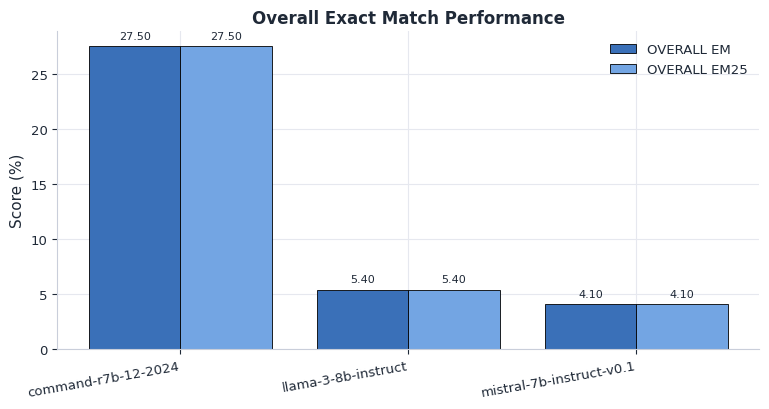

Saved: arabicaqa_rag_results/predictions/figures\plot_overall_em_em25.png
Saved: arabicaqa_rag_results/predictions/figures\plot_overall_em_em25.pdf


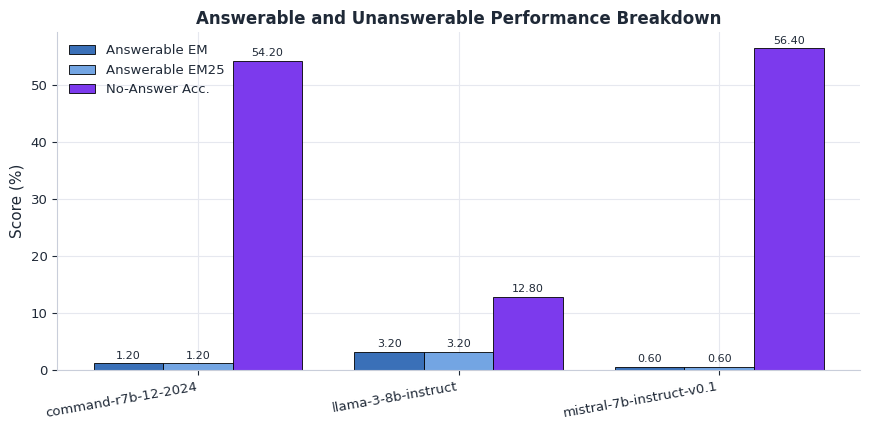

Saved: arabicaqa_rag_results/predictions/figures\plot_breakdown_answerable_noanswer.png
Saved: arabicaqa_rag_results/predictions/figures\plot_breakdown_answerable_noanswer.pdf


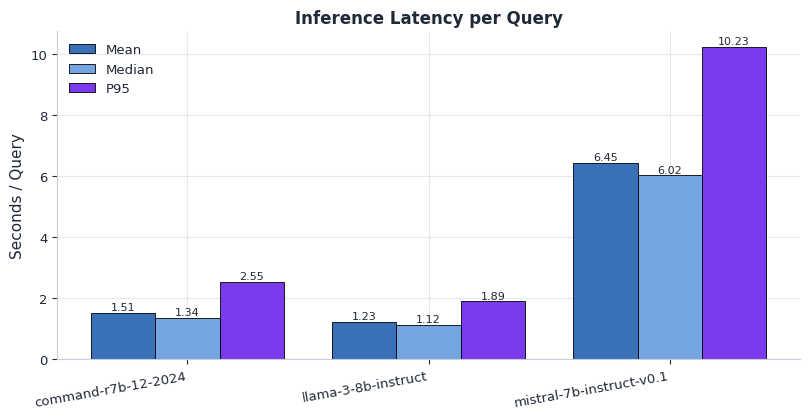

Saved: arabicaqa_rag_results/predictions/figures\plot_inference_latency.png
Saved: arabicaqa_rag_results/predictions/figures\plot_inference_latency.pdf


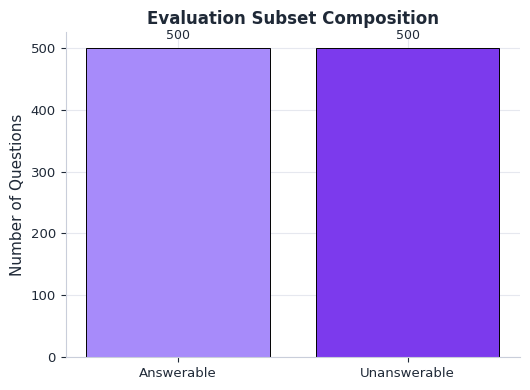

Saved: arabicaqa_rag_results/predictions/figures\plot_dataset_split.png
Saved: arabicaqa_rag_results/predictions/figures\plot_dataset_split.pdf

Done. Figures saved in: arabicaqa_rag_results/predictions/figures


In [21]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ======================================================
# Paths
# ======================================================
SCORES_PATH = "arabicaqa_rag_results/predictions/final_scores_llama_mistral_command.csv"
OUT_DIR = "arabicaqa_rag_results/predictions/figures"
os.makedirs(OUT_DIR, exist_ok=True)

if not os.path.exists(SCORES_PATH):
    raise FileNotFoundError(f"Scores file not found: {SCORES_PATH}")

df = pd.read_csv(SCORES_PATH, encoding="utf-8-sig")

# ======================================================
# Model display names
# ======================================================
MODEL_DISPLAY_NAMES = {
    "command": "command-r7b-12-2024",
    "llama": "llama-3-8b-instruct",
    "mistral": "mistral-7b-instruct-v0.1",
}

if "model" not in df.columns:
    raise KeyError("The scores file must contain a 'model' column.")

df["model"] = df["model"].astype(str).str.strip()
df["model"] = df["model"].replace(MODEL_DISPLAY_NAMES)

print("Loaded:", SCORES_PATH)
print(df.round(4).to_string(index=False))

# ======================================================
# Theme colors
# ======================================================
PRIMARY   = "#3A70B8"
SECONDARY = "#73A5E3"
ACCENT1   = "#A78BFA"
ACCENT2   = "#7C3AED"
GREEN     = "#0F9D58"
GRID      = "#E6E8EF"
SPINE     = "#C9CEDA"
TXT       = "#1F2937"

MODEL_COLORS = {
    "llama-3-8b-instruct": PRIMARY,
    "mistral-7b-instruct-v0.1": ACCENT2,
    "command-r7b-12-2024": GREEN,
}

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": SPINE,
    "axes.labelcolor": TXT,
    "xtick.color": TXT,
    "ytick.color": TXT,
    "text.color": TXT,
    "axes.titleweight": "bold",
    "axes.titlesize": 12,
    "axes.labelsize": 11,
    "xtick.labelsize": 9.5,
    "ytick.labelsize": 9.5,
    "legend.fontsize": 9.5,
    "axes.grid": True,
    "grid.color": GRID,
    "grid.linewidth": 0.8,
    "grid.alpha": 1.0,
})

def finalize(ax):
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color(SPINE)
    ax.spines["bottom"].set_color(SPINE)

def savefig(fig, name):
    png_path = os.path.join(OUT_DIR, f"{name}.png")
    pdf_path = os.path.join(OUT_DIR, f"{name}.pdf")

    fig.tight_layout()
    fig.savefig(png_path, dpi=300, bbox_inches="tight")
    fig.savefig(pdf_path, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print("Saved:", png_path)
    print("Saved:", pdf_path)

# ======================================================
# Prepare
# ======================================================
models = df["model"].tolist()
model_colors = [MODEL_COLORS.get(m, "#777777") for m in models]

# ======================================================
# 1) Overall EM / EM25
# ======================================================
metrics = ["overall_em", "overall_em25"]
available_metrics = [m for m in metrics if m in df.columns]

if available_metrics:
    x = np.arange(len(models))
    width = 0.8 / len(available_metrics)

    fig, ax = plt.subplots(figsize=(7.8, 4.2))

    metric_colors = [PRIMARY, SECONDARY]

    for i, metric in enumerate(available_metrics):
        values = df[metric].astype(float).values
        offset = (i - (len(available_metrics) - 1) / 2) * width

        ax.bar(
            x + offset,
            values,
            width=width,
            label=metric.replace("_", " ").upper(),
            color=metric_colors[i],
            edgecolor="black",
            linewidth=0.6
        )

        for j, v in enumerate(values):
            ax.text(
                x[j] + offset,
                v + 0.5,
                f"{v:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=10, ha="right")
    ax.set_ylabel("Score (%)")
    ax.set_title("Overall Exact Match Performance")
    ax.legend(frameon=False)
    finalize(ax)

    savefig(fig, "plot_overall_em_em25")

# ======================================================
# 2) Answerability-aware breakdown
# ======================================================
breakdown_metrics = [
    "answerable_em",
    "answerable_em25",
    "unanswerable_abstention_accuracy",
]
breakdown_metrics = [m for m in breakdown_metrics if m in df.columns]

if breakdown_metrics:
    x = np.arange(len(models))
    width = 0.8 / len(breakdown_metrics)

    fig, ax = plt.subplots(figsize=(8.8, 4.4))

    metric_colors = [PRIMARY, SECONDARY, ACCENT2]

    pretty_names = {
        "answerable_em": "Answerable EM",
        "answerable_em25": "Answerable EM25",
        "unanswerable_abstention_accuracy": "No-Answer Acc.",
    }

    for i, metric in enumerate(breakdown_metrics):
        values = df[metric].astype(float).values
        offset = (i - (len(breakdown_metrics) - 1) / 2) * width

        ax.bar(
            x + offset,
            values,
            width=width,
            label=pretty_names.get(metric, metric),
            color=metric_colors[i],
            edgecolor="black",
            linewidth=0.6
        )

        for j, v in enumerate(values):
            ax.text(
                x[j] + offset,
                v + 0.5,
                f"{v:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=10, ha="right")
    ax.set_ylabel("Score (%)")
    ax.set_title("Answerable and Unanswerable Performance Breakdown")
    ax.legend(loc="upper left", frameon=False)
    finalize(ax)

    savefig(fig, "plot_breakdown_answerable_noanswer")

# ======================================================
# 3) Latency plot, if available
# ======================================================
latency_metrics = [
    "latency_mean_sec",
    "latency_median_sec",
    "latency_p95_sec",
]
latency_metrics = [m for m in latency_metrics if m in df.columns]

if latency_metrics:
    x = np.arange(len(models))
    width = 0.8 / len(latency_metrics)

    fig, ax = plt.subplots(figsize=(8.2, 4.3))

    metric_colors = [PRIMARY, SECONDARY, ACCENT2]

    pretty_names = {
        "latency_mean_sec": "Mean",
        "latency_median_sec": "Median",
        "latency_p95_sec": "P95",
    }

    for i, metric in enumerate(latency_metrics):
        values = df[metric].astype(float).values
        offset = (i - (len(latency_metrics) - 1) / 2) * width

        ax.bar(
            x + offset,
            values,
            width=width,
            label=pretty_names.get(metric, metric),
            color=metric_colors[i],
            edgecolor="black",
            linewidth=0.6
        )

        for j, v in enumerate(values):
            ax.text(
                x[j] + offset,
                v + 0.03,
                f"{v:.2f}",
                ha="center",
                va="bottom",
                fontsize=8
            )

    ax.set_xticks(x)
    ax.set_xticklabels(models, rotation=10, ha="right")
    ax.set_ylabel("Seconds / Query")
    ax.set_title("Inference Latency per Query")
    ax.legend(frameon=False)
    finalize(ax)

    savefig(fig, "plot_inference_latency")

# ======================================================
# 4) Dataset split plot
# ======================================================
if "unanswerable_total" in df.columns:
    # The total unanswerable count is repeated per model, so use the first row.
    unanswerable = int(df["unanswerable_total"].iloc[0])

    if "n_questions" in df.columns:
        total = int(df["n_questions"].iloc[0])
        answerable = total - unanswerable
    else:
        # Current fixed subset fallback: 500 answerable / 500 unanswerable.
        answerable = 500

    labels = ["Answerable", "Unanswerable"]
    values = [answerable, unanswerable]

    fig, ax = plt.subplots(figsize=(5.4, 4.0))

    ax.bar(
        labels,
        values,
        color=[ACCENT1, ACCENT2],
        edgecolor="black",
        linewidth=0.7
    )

    for i, v in enumerate(values):
        ax.text(i, v + 10, str(v), ha="center", va="bottom", fontsize=9)

    ax.set_ylabel("Number of Questions")
    ax.set_title("Evaluation Subset Composition")
    finalize(ax)

    savefig(fig, "plot_dataset_split")

print("\nDone. Figures saved in:", OUT_DIR)

In [23]:
import os
import ast
import json
import math
import pandas as pd

# ============================================================
# Clean prediction file after generation
# ============================================================

PRED_DIR = "arabicaqa_rag_results/predictions"

INPUT_FILE = "comparison_llama_mistral_command_1000.csv"
OUTPUT_FILE = "comparison_llama_mistral_command_1000_clean.csv"

input_path = os.path.join(PRED_DIR, INPUT_FILE)
output_path = os.path.join(PRED_DIR, OUTPUT_FILE)

if not os.path.exists(input_path):
    raise FileNotFoundError(f"File not found: {input_path}")

df = pd.read_csv(input_path, encoding="utf-8-sig")

print("=" * 80)
print("CLEANING PREDICTION FILE")
print("=" * 80)
print("Loaded:", input_path)
print("Shape:", df.shape)
print("Columns:", list(df.columns))

# ============================================================
# Model display names
# ============================================================
# Original short keys are kept in column names for compatibility.
# Example columns:
# - predicted_answer_command
# - latency_sec_command
#
# Full names are used only for readable logging/reporting.
MODEL_DISPLAY_NAMES = {
    "command": "command-r7b-12-2024",
    "llama": "llama-3-8b-instruct",
    "mistral": "mistral-7b-instruct-v0.1",
}

# ============================================================
# Robust parsers
# ============================================================
def parse_correct_answers(x):
    """
    Converts correct_answers to list[str].
    Handles:
    - NaN / None
    - Python list
    - stringified list: "['answer']"
    - JSON list: '["answer"]'
    - plain string answer
    """
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        # Try JSON first
        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
            if str(parsed).strip():
                return [str(parsed).strip()]
        except Exception:
            pass

        # Try Python literal
        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
            if str(parsed).strip():
                return [str(parsed).strip()]
        except Exception:
            pass

        # Fallback: plain string
        return [s]

    return []

def parse_maybe_list(x):
    """
    Generic parser for columns such as retrieved_contexts or retrieved_doc_ids.
    """
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return x

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        try:
            parsed = json.loads(s)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass

        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return parsed
        except Exception:
            pass

        return [s]

    return [x]

# ============================================================
# Clean required columns
# ============================================================
if "correct_answers" not in df.columns:
    raise KeyError("Missing column: correct_answers")

df["correct_answers"] = df["correct_answers"].apply(parse_correct_answers)

if "is_impossible" in df.columns:
    df["is_impossible"] = df["is_impossible"].astype(bool)
    df["is_answerable"] = ~df["is_impossible"]

# Optional list-like columns
for col in ["retrieved_contexts", "retrieved_doc_ids", "retrieved_chunk_ids"]:
    if col in df.columns:
        df[col] = df[col].apply(parse_maybe_list)

# ============================================================
# Detect model prediction and latency columns
# ============================================================
model_keys = [
    c.replace("predicted_answer_", "")
    for c in df.columns
    if c.startswith("predicted_answer_")
]

print("\nDetected models:")
for m in model_keys:
    display_name = MODEL_DISPLAY_NAMES.get(m, m)
    print(f" - {m} -> {display_name}")

for m in model_keys:
    pred_col = f"predicted_answer_{m}"

    if pred_col not in df.columns:
        raise KeyError(f"Missing prediction column: {pred_col}")

    df[pred_col] = df[pred_col].fillna("").astype(str)

    latency_col = f"latency_sec_{m}"
    if latency_col in df.columns:
        df[latency_col] = pd.to_numeric(df[latency_col], errors="coerce")

# ============================================================
# Integrity checks
# ============================================================
def is_empty_gold(x):
    if x is None:
        return True

    if isinstance(x, float) and math.isnan(x):
        return True

    if isinstance(x, (list, tuple)):
        return len([str(t).strip() for t in x if str(t).strip()]) == 0

    return str(x).strip() == ""

empty_mask = df["correct_answers"].apply(is_empty_gold)

print("\nGold answer integrity:")
print("Empty gold count:", int(empty_mask.sum()))
print("Empty gold %:", round(empty_mask.mean() * 100, 2))

if "is_impossible" in df.columns:
    empty_gold_but_answerable = int((empty_mask & (df["is_impossible"] == False)).sum())
    nonempty_gold_but_unanswerable = int(((~empty_mask) & (df["is_impossible"] == True)).sum())

    print("Empty gold but is_impossible=False:", empty_gold_but_answerable)
    print("Non-empty gold but is_impossible=True:", nonempty_gold_but_unanswerable)

# Error counts
print("\nPrediction error counts:")
for m in model_keys:
    pred_col = f"predicted_answer_{m}"
    display_name = MODEL_DISPLAY_NAMES.get(m, m)

    n_errors = int((df[pred_col].fillna("") == "ERROR").sum())
    print(f"{display_name}: {n_errors}")

# ============================================================
# Save clean CSV + JSONL
# ============================================================
df.to_csv(output_path, index=False, encoding="utf-8-sig")

jsonl_path = output_path.replace(".csv", ".jsonl")
df.to_json(jsonl_path, orient="records", lines=True, force_ascii=False)

print("\nSaved clean files:")
print("CSV :", output_path)
print("JSONL:", jsonl_path)

# ============================================================
# Re-read check
# ============================================================
df_check = pd.read_csv(output_path, encoding="utf-8-sig")
df_check["correct_answers"] = df_check["correct_answers"].apply(parse_correct_answers)

print("\nRe-read check:")
print(df_check["correct_answers"].apply(type).value_counts())
print("Shape:", df_check.shape)

df_check.head(3)

CLEANING PREDICTION FILE
Loaded: arabicaqa_rag_results/predictions\comparison_llama_mistral_command_1000.csv
Shape: (1000, 21)
Columns: ['row_idx', 'split', 'document_id', 'question_id', 'question', 'context', 'correct_answers', 'is_impossible', 'is_answerable', 'retrieved_contexts', 'retrieved_doc_ids', 'retrieved_chunk_ids', 'predicted_answer_command', 'latency_sec_command', 'error_command', 'predicted_answer_llama', 'latency_sec_llama', 'error_llama', 'predicted_answer_mistral', 'latency_sec_mistral', 'error_mistral']

Detected models:
 - command -> command-r7b-12-2024
 - llama -> llama-3-8b-instruct
 - mistral -> mistral-7b-instruct-v0.1

Gold answer integrity:
Empty gold count: 500
Empty gold %: 50.0
Empty gold but is_impossible=False: 0
Non-empty gold but is_impossible=True: 0

Prediction error counts:
command-r7b-12-2024: 0
llama-3-8b-instruct: 0
mistral-7b-instruct-v0.1: 0

Saved clean files:
CSV : arabicaqa_rag_results/predictions\comparison_llama_mistral_command_1000_clean.cs

,row_idx,split,document_id,question_id,question,context,correct_answers,is_impossible,is_answerable,retrieved_contexts,...,retrieved_chunk_ids,predicted_answer_command,latency_sec_command,error_command,predicted_answer_llama,latency_sec_llama,error_llama,predicted_answer_mistral,latency_sec_mistral,error_mistral
0,0,train,1732461,1193607,متي تم بناء الموقع الأول لشركة توب غولف؟,توب غولف هي شركة ترفيهية رياضية عالمية مقرها ف...,[عام 2000],False,True,['في المملكة المتحدة. بعد ستة أشهر، كان لدى من...,...,"[4, 5, 1, 5, 3]",غير موجود في السياق.,3.673629,NaN,1995.,1.433770,NaN,غير موجود في السياق للسنة التي تم بناء الموقع ...,5.209762,NaN
1,1,test,1583712,1160774,كم عدد الحفريات التي تم اكتشافها لببر نغاندونغ؟,ببر نغاندونغ هو نويع منقرض من أنواع الببور الح...,[سبع حفريات],False,True,['ولما أزيح التراب من فوق هرم. اكتشفت 21 مقبرة...,...,"[1, 0, 2, 4, 5]",تم اكتشاف سبع حفريات لببر نغاندونغ.,1.807783,NaN,21,1.845930,NaN,غير موجود في السياق للعدد الخاص بالحفريات التي...,5.265048,NaN
2,2,train,1718678,1164879,ما هو مركز اللاعب ميو تساكتاش؟,ميو تساكتاش (8 مايو 1992 في سبليت في كرواتيا -...,[كصانع ألعاب],False,True,"['بورت غالب.', 'ما بعد لافوازييه.', 'البنية.',...",...,"[8, 8, 76, 4, 0]",غير موجود في السياق.,1.694605,NaN,لاعب وسط.,1.491944,NaN,غير موجود في السياق لمعرفة مركز ميو تساكتاش.,4.074893,NaN


## **RAGAS Part**

In [3]:
import os
import ast
import json
import math
import time
import numpy as np
import pandas as pd
from tqdm import tqdm
from datasets import Dataset
from ragas.run_config import RunConfig
from ragas import evaluate
import ragas.metrics as rm

from langchain_community.embeddings import HuggingFaceEmbeddings
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI

# ============================================================
# 0) PATHS
# ============================================================
PRED_PATH = "arabicaqa_rag_results/predictions/comparison_llama_mistral_command_1000.csv"
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full_llama_mistral_command"
os.makedirs(OUTPUT_DIR, exist_ok=True)

if not os.path.exists(PRED_PATH):
    raise FileNotFoundError(f"Prediction file not found: {PRED_PATH}")

# Set False for the full 1000-question run.
TEST_MODE = False

df_results = pd.read_csv(PRED_PATH, encoding="utf-8-sig")

if "is_impossible" not in df_results.columns:
    raise KeyError("Missing required column: is_impossible")

df_results["is_impossible"] = df_results["is_impossible"].astype(bool)

if TEST_MODE:
    df_ans = df_results[df_results["is_impossible"] == False].head(1)
    df_un = df_results[df_results["is_impossible"] == True].head(1)
    df_results = pd.concat([df_ans, df_un], ignore_index=True)
    print(f"TEST MODE: running {len(df_results)} rows")
    print(df_results["is_impossible"].value_counts())

print("=" * 100)
print("RAGAS FULL EVALUATION")
print("=" * 100)
print("Loaded:", PRED_PATH)
print("Shape:", df_results.shape)
print("Columns:", list(df_results.columns))

# ============================================================
# 1) MODEL DISPLAY NAMES
# ============================================================
# Keep original short keys for reading saved prediction columns.
# Use full names in all saved RAGAS outputs.
MODEL_DISPLAY_NAMES = {
    "command": "command-r7b-12-2024",
    "llama": "llama-3-8b-instruct",
    "mistral": "mistral-7b-instruct-v0.1",
}

# ============================================================
# 2) DETECT MODELS AUTOMATICALLY
# ============================================================
prediction_prefix = "predicted_answer_"

model_keys = [
    col.replace(prediction_prefix, "")
    for col in df_results.columns
    if col.startswith(prediction_prefix)
]

if not model_keys:
    raise ValueError("No predicted_answer_* columns found.")

model_key_to_display = {
    key: MODEL_DISPLAY_NAMES.get(key, key)
    for key in model_keys
}

print("\nDetected models:")
for model_key in model_keys:
    print(f" - {model_key} -> {model_key_to_display[model_key]}")

required_cols = ["question", "correct_answers", "is_impossible"]
missing = [c for c in required_cols if c not in df_results.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

# ============================================================
# 3) PARSE CORRECT ANSWERS
# ============================================================
NO_ANSWER = "غير موجود في السياق"

def parse_correct_answers(x):
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        try:
            parsed = ast.literal_eval(s)
            if isinstance(parsed, list):
                return [str(v).strip() for v in parsed if str(v).strip()]
            return [str(parsed).strip()] if str(parsed).strip() else []
        except Exception:
            return [s]

    return []

df_results["correct_answers"] = df_results["correct_answers"].apply(parse_correct_answers)
df_results["is_impossible"] = df_results["is_impossible"].astype(bool)
df_results["is_answerable"] = ~df_results["is_impossible"]

def get_ground_truth(ans_list, is_impossible):
    if is_impossible:
        return NO_ANSWER

    if isinstance(ans_list, list) and len(ans_list) > 0:
        return str(ans_list[0]).strip()

    return ""

df_results["ground_truth_for_ragas"] = df_results.apply(
    lambda r: get_ground_truth(r["correct_answers"], r["is_impossible"]),
    axis=1
)

print("\nAnswerability counts:")
print(df_results["is_answerable"].value_counts())

# ============================================================
# 4) CONTEXTS
# ============================================================
def parse_context_list(x):
    """
    Convert a saved context field into list[str].

    Handles:
    - real list
    - stringified list
    - empty list string: "[]"
    - plain string
    - NaN / None
    """
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return [str(c).strip() for c in x if str(c).strip()]

    if isinstance(x, str):
        s = x.strip()

        if not s or s in ["[]", "nan", "None"]:
            return []

        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    return [str(c).strip() for c in parsed if str(c).strip()]
            except Exception:
                return []

        return [s]

    return [str(x).strip()] if str(x).strip() else []

def build_ragas_contexts(row):
    """
    Use saved retrieved contexts when they are non-empty.
    Otherwise, fall back to the original dataset context.
    """
    retrieved = parse_context_list(row.get("retrieved_contexts", ""))

    if len(retrieved) > 0:
        return retrieved

    original_context = parse_context_list(row.get("context", ""))

    if len(original_context) > 0:
        return original_context

    return []

if "retrieved_contexts" not in df_results.columns:
    print("\nNo retrieved_contexts column found. Creating an empty retrieved_contexts column.")
    df_results["retrieved_contexts"] = ""

if "context" not in df_results.columns:
    print("\nWarning: No context column found. Empty retrieved_contexts cannot be fixed by fallback.")
    df_results["context"] = ""

df_results["ragas_contexts"] = df_results.apply(build_ragas_contexts, axis=1)

# Keep this name for compatibility with the rest of the script.
df_results["retrieved_contexts"] = df_results["ragas_contexts"]

print("\nContext check before RAGAS:")
context_preview_cols = ["retrieved_contexts"]
if "question_id" in df_results.columns:
    context_preview_cols = ["question_id", "retrieved_contexts"]
print(df_results[context_preview_cols].head())

print("\nContext lengths:")
print(df_results["retrieved_contexts"].apply(len).value_counts())

empty_context_count = df_results["retrieved_contexts"].apply(
    lambda x: len(x) == 0 or all(str(c).strip() == "" for c in x)
).sum()

print("\nEmpty context count:", empty_context_count)

if empty_context_count > 0:
    raise ValueError(
        f"Found {empty_context_count} rows with empty contexts. "
        "RAGAS should not run until every row has at least one context."
    )

contexts_augmented_path = os.path.join(OUTPUT_DIR, "predictions_with_ragas_contexts.csv")
df_results.to_csv(contexts_augmented_path, index=False, encoding="utf-8-sig")
print("Saved contexts-augmented predictions:", contexts_augmented_path)

# ============================================================
# 5) RAGAS METRICS
# ============================================================
metric_candidates = [
    getattr(rm, "answer_relevancy", None),
    getattr(rm, "faithfulness", None),
    getattr(rm, "context_recall", None),
    getattr(rm, "context_precision", None),
    getattr(rm, "context_relevancy", None) or getattr(rm, "context_relevance", None),
    getattr(rm, "answer_correctness", None),
    getattr(rm, "answer_similarity", None),
]

metrics = [m for m in metric_candidates if m is not None]

if not metrics:
    raise RuntimeError("No compatible RAGAS metrics were found in the installed ragas version.")

# Reduce repeated judge generations where supported.
# This helps avoid warnings such as:
# "LLM returned 1 generations instead of requested 3."
# It does not remove or change the selected RAGAS metrics.
for metric in metrics:
    if hasattr(metric, "strictness"):
        metric.strictness = 1

metric_names = [m.name for m in metrics]

print("\nRAGAS metrics that will run:")
for metric in metrics:
    strictness = getattr(metric, "strictness", None)
    if strictness is not None:
        print(f" - {metric.name} | strictness={strictness}")
    else:
        print(f" - {metric.name}")

# ============================================================
# 6) JUDGE LLM + EMBEDDINGS
# ============================================================
load_dotenv()

OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
OPENROUTER_BASE_URL = "https://openrouter.ai/api/v1"

OPENROUTER_RAGAS_JUDGE_MODEL = "openai/gpt-4.1-mini"

print(f"\nRAGAS JUDGE MODEL: {OPENROUTER_RAGAS_JUDGE_MODEL}")

if not OPENROUTER_API_KEY:
    raise ValueError("OPENROUTER_API_KEY environment variable is not set.")

embeddings = HuggingFaceEmbeddings(
    model_name="intfloat/multilingual-e5-large"
)

llm_ragas = ChatOpenAI(
    model=OPENROUTER_RAGAS_JUDGE_MODEL,
    temperature=0.0,
    api_key=OPENROUTER_API_KEY,
    base_url=OPENROUTER_BASE_URL,
    max_tokens=1024,
    model_kwargs={
        "response_format": {"type": "json_object"}
    },
    default_headers={
        "HTTP-Referer": "https://your-project-name.com",
        "X-Title": "ArabicaQA RAGAS",
    },
)

print(f"\nJudge LLM: {OPENROUTER_RAGAS_JUDGE_MODEL} via OpenRouter")
print("Embeddings: intfloat/multilingual-e5-large")

# ============================================================
# 7) HELPER: RUN RAGAS FOR ONE MODEL
# ============================================================
def run_ragas_for_model(df_input, model_key):
    model_name = model_key_to_display.get(model_key, model_key)
    pred_col = f"predicted_answer_{model_key}"

    if pred_col not in df_input.columns:
        raise KeyError(f"Missing prediction column: {pred_col}")

    df_eval = df_input.copy()

    print("\nContext check before RAGAS:")
    preview_cols = ["retrieved_contexts"]
    if "question_id" in df_eval.columns:
        preview_cols = ["question_id", "retrieved_contexts"]
    print(df_eval[preview_cols].head())

    print("\nContext lengths:")
    print(df_eval["retrieved_contexts"].apply(lambda x: len(x) if isinstance(x, list) else -1).value_counts())

    print("\nEmpty context count:")
    print(df_eval["retrieved_contexts"].apply(
        lambda x: (not isinstance(x, list)) or len(x) == 0 or all(str(c).strip() == "" for c in x)
    ).sum())

    ragas_dataset = Dataset.from_dict({
        "question": df_eval["question"].fillna("").astype(str).tolist(),
        "answer": df_eval[pred_col].fillna("").astype(str).tolist(),
        "contexts": df_eval["retrieved_contexts"].tolist(),
        "ground_truth": df_eval["ground_truth_for_ragas"].fillna("").astype(str).tolist(),
    })

    start_time = time.perf_counter()

    ragas_run_config = RunConfig(
        timeout=300,
        max_retries=2,
        max_wait=60,
        max_workers=1,
    )

    result = evaluate(
        ragas_dataset,
        metrics=metrics,
        llm=llm_ragas,
        embeddings=embeddings,
        run_config=ragas_run_config,
        raise_exceptions=False,
    )

    end_time = time.perf_counter()
    total_latency_sec = end_time - start_time
    avg_latency_sec = total_latency_sec / len(df_eval) if len(df_eval) else np.nan

    df_scores = result.to_pandas()

    non_metric_cols = {
        "question",
        "answer",
        "contexts",
        "ground_truth",
        "user_input",
        "response",
        "reference",
        "retrieved_contexts",
    }

    out = pd.DataFrame({
        "row_idx": df_eval["row_idx"].values if "row_idx" in df_eval.columns else df_eval.index.values,
        "question_id": df_eval["question_id"].values if "question_id" in df_eval.columns else "",
        "document_id": df_eval["document_id"].values if "document_id" in df_eval.columns else "",
        "question": df_eval["question"].values,
        "is_impossible": df_eval["is_impossible"].values,
        "is_answerable": df_eval["is_answerable"].values,
        "ground_truth": df_eval["ground_truth_for_ragas"].values,
        "model": model_name,
        "model_key": model_key,
        "answer": df_eval[pred_col].fillna("").astype(str).values,
        "retrieved_contexts": df_eval["retrieved_contexts"].values,
    })

    gen_latency_col = f"latency_sec_{model_key}"
    if gen_latency_col in df_eval.columns:
        out["generation_latency_sec"] = pd.to_numeric(df_eval[gen_latency_col], errors="coerce").values
    else:
        out["generation_latency_sec"] = np.nan

    out["ragas_total_run_latency_sec"] = total_latency_sec
    out["ragas_avg_latency_sec_per_question"] = avg_latency_sec

    for c in df_scores.columns:
        if c not in non_metric_cols:
            out[c] = pd.to_numeric(df_scores[c], errors="coerce").values

    return out, total_latency_sec, avg_latency_sec

# ============================================================
# 8) RUN RAGAS FOR ALL MODELS
# ============================================================
all_per_question = []
run_latency_rows = []

for model_key in model_keys:
    model_name = model_key_to_display.get(model_key, model_key)

    print("\n" + "=" * 100)
    print(f"Running RAGAS for model: {model_name}")
    print("=" * 100)

    df_model_scores, total_lat, avg_lat = run_ragas_for_model(df_results, model_key)

    all_per_question.append(df_model_scores)

    run_latency_rows.append({
        "model": model_name,
        "model_key": model_key,
        "n_questions": int(len(df_results)),
        "ragas_total_latency_sec": float(total_lat),
        "ragas_avg_latency_sec_per_question": float(avg_lat),
    })

    safe_model_name = model_name.replace("/", "_").replace(":", "_")
    per_model_path = os.path.join(OUTPUT_DIR, f"ragas_per_question_{safe_model_name}.csv")
    df_model_scores.to_csv(per_model_path, index=False, encoding="utf-8-sig")

    print(f"Saved per-question RAGAS for {model_name}: {per_model_path}")
    print(f"RAGAS total latency: {total_lat:.2f} sec")
    print(f"RAGAS avg latency/question: {avg_lat:.4f} sec")

df_per_question = pd.concat(all_per_question, ignore_index=True)

per_question_csv = os.path.join(OUTPUT_DIR, "ragas_per_question_all_models.csv")
per_question_json = os.path.join(OUTPUT_DIR, "ragas_per_question_all_models.json")

df_per_question.to_csv(per_question_csv, index=False, encoding="utf-8-sig")
df_per_question.to_json(per_question_json, orient="records", force_ascii=False, indent=2)

print("\nSaved combined per-question RAGAS:")
print("CSV :", per_question_csv)
print("JSON:", per_question_json)

# ============================================================
# 9) AGGREGATE MEANS: ALL / ANSWERABLE / UNANSWERABLE
# ============================================================
metadata_cols = {
    "row_idx",
    "question_id",
    "document_id",
    "question",
    "is_impossible",
    "is_answerable",
    "ground_truth",
    "model",
    "model_key",
    "answer",
    "retrieved_contexts",
    "generation_latency_sec",
    "ragas_total_run_latency_sec",
    "ragas_avg_latency_sec_per_question",
    "user_input",
    "response",
    "reference",
    "contexts",
}

candidate_metric_cols = [
    c for c in df_per_question.columns
    if c not in metadata_cols
]

metric_cols = []
for c in candidate_metric_cols:
    df_per_question[c] = pd.to_numeric(df_per_question[c], errors="coerce")
    if pd.api.types.is_numeric_dtype(df_per_question[c]):
        metric_cols.append(c)

summary_rows = []

def summarize_subset(df_sub, subset_name):
    for model_key in model_keys:
        model_name = model_key_to_display.get(model_key, model_key)
        df_m = df_sub[df_sub["model"] == model_name].copy()

        if len(df_m) == 0:
            continue

        row = {
            "model": model_name,
            "model_key": model_key,
            "subset": subset_name,
            "n_questions": int(len(df_m)),
            "generation_latency_mean_sec": float(df_m["generation_latency_sec"].mean(skipna=True)),
            "generation_latency_median_sec": float(df_m["generation_latency_sec"].median(skipna=True)),
            "generation_latency_p95_sec": float(df_m["generation_latency_sec"].quantile(0.95)),
            "ragas_avg_latency_sec_per_question": float(df_m["ragas_avg_latency_sec_per_question"].mean(skipna=True)),
        }

        for metric_col in metric_cols:
            row[metric_col] = float(df_m[metric_col].mean(skipna=True))

        summary_rows.append(row)

summarize_subset(df_per_question, "ALL")
summarize_subset(df_per_question[df_per_question["is_answerable"] == True], "ANSWERABLE")
summarize_subset(df_per_question[df_per_question["is_answerable"] == False], "UNANSWERABLE")

df_summary = pd.DataFrame(summary_rows)

summary_csv = os.path.join(OUTPUT_DIR, "ragas_summary_means.csv")
summary_json = os.path.join(OUTPUT_DIR, "ragas_summary_means.json")
summary_md = os.path.join(OUTPUT_DIR, "RAGAS_SUMMARY.md")

df_summary.to_csv(summary_csv, index=False, encoding="utf-8-sig")
df_summary.to_json(summary_json, orient="records", force_ascii=False, indent=2)

with open(summary_md, "w", encoding="utf-8") as f:
    f.write("# RAGAS Summary Means\n\n")
    f.write(f"Judge LLM: `{OPENROUTER_RAGAS_JUDGE_MODEL}` via OpenRouter  \n")
    f.write("Embeddings: `intfloat/multilingual-e5-large`  \n")
    f.write(f"Prediction file: `{PRED_PATH}`  \n\n")
    try:
        f.write(df_summary.round(4).to_markdown(index=False))
    except Exception:
        f.write(df_summary.round(4).to_string(index=False))

print("\nSaved RAGAS summaries:")
print("CSV :", summary_csv)
print("JSON:", summary_json)
print("MD  :", summary_md)

# ============================================================
# 10) NaN DIAGNOSTICS
# ============================================================
nan_rows = []

for model_key in model_keys:
    model_name = model_key_to_display.get(model_key, model_key)

    for subset_name, df_sub in [
        ("ALL", df_per_question),
        ("ANSWERABLE", df_per_question[df_per_question["is_answerable"] == True]),
        ("UNANSWERABLE", df_per_question[df_per_question["is_answerable"] == False]),
    ]:
        df_m = df_sub[df_sub["model"] == model_name]

        for metric_col in metric_cols:
            nan_count = int(df_m[metric_col].isna().sum())
            n = int(len(df_m))

            nan_rows.append({
                "model": model_name,
                "model_key": model_key,
                "subset": subset_name,
                "metric": metric_col,
                "nan_count": nan_count,
                "n_questions": n,
                "nan_ratio": float(nan_count / n) if n > 0 else np.nan,
            })

df_nan = pd.DataFrame(nan_rows)

nan_csv = os.path.join(OUTPUT_DIR, "ragas_nan_report.csv")
nan_json = os.path.join(OUTPUT_DIR, "ragas_nan_report.json")

df_nan.to_csv(nan_csv, index=False, encoding="utf-8-sig")
df_nan.to_json(nan_json, orient="records", force_ascii=False, indent=2)

print("\nSaved NaN diagnostics:")
print("CSV :", nan_csv)
print("JSON:", nan_json)

print("\n" + "=" * 100)
print("NaN DIAGNOSTICS")
print("=" * 100)

try:
    display(df_nan)
except Exception:
    print(df_nan.to_string(index=False))

# ============================================================
# 11) LATENCY SUMMARY
# ============================================================
df_ragas_latency = pd.DataFrame(run_latency_rows)

latency_rows = []

for model_key in model_keys:
    model_name = model_key_to_display.get(model_key, model_key)
    df_m = df_per_question[df_per_question["model"] == model_name].copy()

    row = {
        "model": model_name,
        "model_key": model_key,
        "n_questions": int(len(df_m)),
        "generation_latency_mean_sec": float(df_m["generation_latency_sec"].mean(skipna=True)),
        "generation_latency_median_sec": float(df_m["generation_latency_sec"].median(skipna=True)),
        "generation_latency_p95_sec": float(df_m["generation_latency_sec"].quantile(0.95)),
        "ragas_avg_latency_sec_per_question": float(df_m["ragas_avg_latency_sec_per_question"].mean(skipna=True)),
    }

    latency_rows.append(row)

df_latency_summary = pd.DataFrame(latency_rows)

latency_summary_csv = os.path.join(OUTPUT_DIR, "latency_summary.csv")
ragas_latency_csv = os.path.join(OUTPUT_DIR, "ragas_run_latency.csv")

df_latency_summary.to_csv(latency_summary_csv, index=False, encoding="utf-8-sig")
df_ragas_latency.to_csv(ragas_latency_csv, index=False, encoding="utf-8-sig")

print("\nSaved latency summaries:")
print("Generation + RAGAS latency:", latency_summary_csv)
print("RAGAS run latency:", ragas_latency_csv)

# ============================================================
# 12) FINAL PRINT
# ============================================================
print("\n" + "=" * 100)
print("FINAL RAGAS SUMMARY")
print("=" * 100)

try:
    display(df_summary.round(4))
except Exception:
    print(df_summary.round(4).to_string(index=False))

print("\n" + "=" * 100)
print("LATENCY SUMMARY")
print("=" * 100)

try:
    display(df_latency_summary.round(4))
except Exception:
    print(df_latency_summary.round(4).to_string(index=False))

print("\nDone.")

RAGAS FULL EVALUATION
Loaded: arabicaqa_rag_results/predictions/comparison_llama_mistral_command_1000.csv
Shape: (1000, 21)
Columns: ['row_idx', 'split', 'document_id', 'question_id', 'question', 'context', 'correct_answers', 'is_impossible', 'is_answerable', 'retrieved_contexts', 'retrieved_doc_ids', 'retrieved_chunk_ids', 'predicted_answer_command', 'latency_sec_command', 'error_command', 'predicted_answer_llama', 'latency_sec_llama', 'error_llama', 'predicted_answer_mistral', 'latency_sec_mistral', 'error_mistral']

Detected models:
 - command -> command-r7b-12-2024
 - llama -> llama-3-8b-instruct
 - mistral -> mistral-7b-instruct-v0.1

Answerability counts:
is_answerable
True     500
False    500
Name: count, dtype: int64

Context check before RAGAS:
   question_id                                 retrieved_contexts
0      1193607  [في المملكة المتحدة. بعد ستة أشهر، كان لدى منش...
1      1160774  [ولما أزيح التراب من فوق هرم. اكتشفت 21 مقبرة ...
2      1164879  [بورت غالب., ما بعد ل

Evaluating: 100%|██████████| 6000/6000 [17:01:38<00:00, 10.22s/it]     


Saved per-question RAGAS for command-r7b-12-2024: arabicaqa_rag_results/ragas_full_llama_mistral_command\ragas_per_question_command-r7b-12-2024.csv
RAGAS total latency: 61303.46 sec
RAGAS avg latency/question: 61.3035 sec

Running RAGAS for model: llama-3-8b-instruct

Context check before RAGAS:
   question_id                                 retrieved_contexts
0      1193607  [في المملكة المتحدة. بعد ستة أشهر، كان لدى منش...
1      1160774  [ولما أزيح التراب من فوق هرم. اكتشفت 21 مقبرة ...
2      1164879  [بورت غالب., ما بعد لافوازييه., البنية., ينطلق...
3      1068610  [المعلومات الغذائية عن مقلوبة الباذنجان.\nتحتو...
4      1175188  [بورت غالب., فترتي «استعراش كنمو» ثم «نان بوكو...

Context lengths:
retrieved_contexts
5    1000
Name: count, dtype: int64

Empty context count:
0


Evaluating: 100%|██████████| 6000/6000 [13:57:48<00:00,  8.38s/it]  


Saved per-question RAGAS for llama-3-8b-instruct: arabicaqa_rag_results/ragas_full_llama_mistral_command\ragas_per_question_llama-3-8b-instruct.csv
RAGAS total latency: 50272.74 sec
RAGAS avg latency/question: 50.2727 sec

Running RAGAS for model: mistral-7b-instruct-v0.1

Context check before RAGAS:
   question_id                                 retrieved_contexts
0      1193607  [في المملكة المتحدة. بعد ستة أشهر، كان لدى منش...
1      1160774  [ولما أزيح التراب من فوق هرم. اكتشفت 21 مقبرة ...
2      1164879  [بورت غالب., ما بعد لافوازييه., البنية., ينطلق...
3      1068610  [المعلومات الغذائية عن مقلوبة الباذنجان.\nتحتو...
4      1175188  [بورت غالب., فترتي «استعراش كنمو» ثم «نان بوكو...

Context lengths:
retrieved_contexts
5    1000
Name: count, dtype: int64

Empty context count:
0


...


Saved latency summaries:
Generation + RAGAS latency: arabicaqa_rag_results/ragas_full_llama_mistral_command\latency_summary.csv
RAGAS run latency: arabicaqa_rag_results/ragas_full_llama_mistral_command\ragas_run_latency.csv

FINAL RAGAS SUMMARY


,model,model_key,subset,n_questions,generation_latency_mean_sec,generation_latency_median_sec,generation_latency_p95_sec,ragas_avg_latency_sec_per_question,answer_relevancy,faithfulness,context_recall,context_precision,answer_correctness,answer_similarity
0,command-r7b-12-2024,command,ALL,1000,1.5116,1.3402,2.5462,61.3035,0.4023,0.4785,0.6540,0.3027,0.4896,0.8518
1,llama-3-8b-instruct,llama,ALL,1000,1.2330,1.1216,1.8918,50.2727,0.6376,0.4761,0.6675,0.2894,0.3497,0.8270
2,mistral-7b-instruct-v0.1,mistral,ALL,1000,6.4450,6.0193,10.2307,45.6682,0.3105,0.4785,0.6595,0.2854,0.4021,0.8185
3,command-r7b-12-2024,command,ANSWERABLE,500,1.4724,1.3338,2.3508,61.3035,0.3822,0.5196,0.4880,0.3805,0.3547,0.8228
4,llama-3-8b-instruct,llama,ANSWERABLE,500,1.2259,1.1180,1.9167,50.2727,0.6208,0.5058,0.4850,0.3743,0.3846,0.8364
5,mistral-7b-instruct-v0.1,mistral,ANSWERABLE,500,5.9060,5.1994,9.9207,45.6682,0.2809,0.4843,0.4870,0.3737,0.2555,0.8110
6,command-r7b-12-2024,command,UNANSWERABLE,500,1.5509,1.3506,2.6777,61.3035,0.4225,0.4373,0.8200,0.2247,0.6242,0.8808
7,llama-3-8b-instruct,llama,UNANSWERABLE,500,1.2402,1.1264,1.8286,50.2727,0.6543,0.4464,0.8500,0.2044,0.3149,0.8176
8,mistral-7b-instruct-v0.1,mistral,UNANSWERABLE,500,6.9839,7.1271,10.4672,45.6682,0.3401,0.4726,0.8320,0.1970,0.5486,0.8261



LATENCY SUMMARY


,model,model_key,n_questions,generation_latency_mean_sec,generation_latency_median_sec,generation_latency_p95_sec,ragas_avg_latency_sec_per_question
0,command-r7b-12-2024,command,1000,1.5116,1.3402,2.5462,61.3035
1,llama-3-8b-instruct,llama,1000,1.2330,1.1216,1.8918,50.2727
2,mistral-7b-instruct-v0.1,mistral,1000,6.4450,6.0193,10.2307,45.6682



Done.


## **RAGAS per-question and 95% CI**

In [8]:
import os
import numpy as np
import pandas as pd

# ============================================================
# CONFIG
# ============================================================ 

RAGAS_DIR = "arabicaqa_rag_results/ragas_full_llama_mistral_command"

MODEL_FILES = {
    "command": os.path.join(RAGAS_DIR, "ragas_per_question_command-r7b-12-2024.csv"),
    "llama": os.path.join(RAGAS_DIR, "ragas_per_question_llama-3-8b-instruct.csv"),
    "mistral": os.path.join(RAGAS_DIR, "ragas_per_question_mistral-7b-instruct-v0.1.csv"),
}

OUTPUT_DIR = os.path.join(RAGAS_DIR, "ci_analysis")
os.makedirs(OUTPUT_DIR, exist_ok=True)

RAGAS_METRICS = [
    "answer_relevancy",
    "faithfulness",
    "context_recall",
    "context_precision",
    "answer_correctness",
    "answer_similarity",
]

LATENCY_COLS = [
    "generation_latency_sec",
    "ragas_avg_latency_sec_per_question",
]

N_BOOTSTRAP = 10000
CI_LEVEL = 95
RANDOM_SEED = 42


# ============================================================
# HELPERS
# ============================================================
def bootstrap_ci(values, n_bootstrap=10000, ci_level=95, seed=42):
    """
    Bootstrap confidence interval for the mean.
    Ignores NaN values.
    """
    values = pd.to_numeric(pd.Series(values), errors="coerce").dropna().to_numpy()

    n = len(values)
    if n == 0:
        return np.nan, np.nan, np.nan, 0

    mean_value = float(np.mean(values))

    if n == 1:
        return mean_value, mean_value, mean_value, n

    rng = np.random.default_rng(seed)
    boot_means = np.empty(n_bootstrap)

    for i in range(n_bootstrap):
        sample = rng.choice(values, size=n, replace=True)
        boot_means[i] = np.mean(sample)

    alpha = (100 - ci_level) / 2
    lower = float(np.percentile(boot_means, alpha))
    upper = float(np.percentile(boot_means, 100 - alpha))

    return mean_value, lower, upper, n


def subset_name(df):
    """
    Creates subset labels: ALL / ANSWERABLE / UNANSWERABLE.
    """
    subsets = {
        "ALL": df,
        "ANSWERABLE": df[df["is_answerable"] == True],
        "UNANSWERABLE": df[df["is_answerable"] == False],
    }
    return subsets


# ============================================================
# LOAD FILES
# ============================================================
dfs = []

for model_name, path in MODEL_FILES.items():
    if not os.path.exists(path):
        raise FileNotFoundError(f"Missing file for {model_name}: {path}")

    df = pd.read_csv(path, encoding="utf-8-sig")

    # Ensure model column exists and is consistent
    df["model"] = model_name

    # Ensure boolean column
    if "is_answerable" in df.columns:
        df["is_answerable"] = df["is_answerable"].astype(bool)
    elif "is_impossible" in df.columns:
        df["is_answerable"] = ~df["is_impossible"].astype(bool)
    else:
        raise KeyError("Missing both is_answerable and is_impossible columns.")

    dfs.append(df)

df_all = pd.concat(dfs, ignore_index=True)

combined_path = os.path.join(OUTPUT_DIR, "ragas_per_question_all_models_loaded.csv")
df_all.to_csv(combined_path, index=False, encoding="utf-8-sig")

print("Loaded combined shape:", df_all.shape)
print("Saved combined file:", combined_path)
print(df_all["model"].value_counts())
print(df_all["is_answerable"].value_counts())


# ============================================================
# MEAN + 95% CI FOR RAGAS METRICS
# ============================================================
ci_rows = []

for model_name in MODEL_FILES.keys():
    df_model = df_all[df_all["model"] == model_name].copy()

    for subset, df_subset in subset_name(df_model).items():
        for metric in RAGAS_METRICS:
            if metric not in df_subset.columns:
                continue

            mean_value, lower, upper, n_valid = bootstrap_ci(
                df_subset[metric],
                n_bootstrap=N_BOOTSTRAP,
                ci_level=CI_LEVEL,
                seed=RANDOM_SEED,
            )

            ci_rows.append({
                "model": model_name,
                "subset": subset,
                "metric": metric,
                "n_total": int(len(df_subset)),
                "n_valid": int(n_valid),
                "mean": mean_value,
                "ci_lower": lower,
                "ci_upper": upper,
                "ci_width": upper - lower if pd.notna(lower) and pd.notna(upper) else np.nan,
                "nan_count": int(pd.to_numeric(df_subset[metric], errors="coerce").isna().sum()),
                "nan_ratio": float(pd.to_numeric(df_subset[metric], errors="coerce").isna().mean()),
            })

df_ci = pd.DataFrame(ci_rows)

ci_csv = os.path.join(OUTPUT_DIR, "ragas_metric_bootstrap_ci.csv")
ci_json = os.path.join(OUTPUT_DIR, "ragas_metric_bootstrap_ci.json")

df_ci.to_csv(ci_csv, index=False, encoding="utf-8-sig")
df_ci.to_json(ci_json, orient="records", force_ascii=False, indent=2)

print("\nSaved RAGAS metric CI:")
print("CSV :", ci_csv)
print("JSON:", ci_json)

try:
    display(df_ci.round(4))
except Exception:
    print(df_ci.round(4).to_string(index=False))

Loaded combined shape: (3000, 20)
Saved combined file: arabicaqa_rag_results/ragas_full_llama_mistral_command\ci_analysis\ragas_per_question_all_models_loaded.csv
model
command    1000
llama      1000
mistral    1000
Name: count, dtype: int64
is_answerable
True     1500
False    1500
Name: count, dtype: int64

Saved RAGAS metric CI:
CSV : arabicaqa_rag_results/ragas_full_llama_mistral_command\ci_analysis\ragas_metric_bootstrap_ci.csv
JSON: arabicaqa_rag_results/ragas_full_llama_mistral_command\ci_analysis\ragas_metric_bootstrap_ci.json


,model,subset,metric,n_total,n_valid,mean,ci_lower,ci_upper,ci_width,nan_count,nan_ratio
0,command,ALL,answer_relevancy,1000,1000,0.4023,0.3731,0.4309,0.0579,0,0.000
1,command,ALL,faithfulness,1000,997,0.4785,0.4486,0.5082,0.0596,3,0.003
2,command,ALL,context_recall,1000,1000,0.6540,0.6250,0.6830,0.0580,0,0.000
3,command,ALL,context_precision,1000,999,0.3027,0.2776,0.3287,0.0511,1,0.001
4,command,ALL,answer_correctness,1000,999,0.4896,0.4673,0.5121,0.0448,1,0.001
5,command,ALL,answer_similarity,1000,1000,0.8518,0.8458,0.8577,0.0119,0,0.000
6,command,ANSWERABLE,answer_relevancy,500,500,0.3822,0.3420,0.4230,0.0810,0,0.000
7,command,ANSWERABLE,faithfulness,500,499,0.5196,0.4772,0.5625,0.0853,1,0.002
8,command,ANSWERABLE,context_recall,500,500,0.4880,0.4460,0.5320,0.0860,0,0.000
9,command,ANSWERABLE,context_precision,500,500,0.3805,0.3440,0.4193,0.0752,0,0.000


## **LATENCY CI**

In [9]:
# ============================================================
# LATENCY CI
# ============================================================
latency_rows = []

for model_name in MODEL_FILES.keys():
    df_model = df_all[df_all["model"] == model_name].copy()

    for subset, df_subset in subset_name(df_model).items():
        for col in LATENCY_COLS:
            if col not in df_subset.columns:
                continue

            mean_value, lower, upper, n_valid = bootstrap_ci(
                df_subset[col],
                n_bootstrap=N_BOOTSTRAP,
                ci_level=CI_LEVEL,
                seed=RANDOM_SEED,
            )

            latency_rows.append({
                "model": model_name,
                "subset": subset,
                "metric": col,
                "n_total": int(len(df_subset)),
                "n_valid": int(n_valid),
                "mean": mean_value,
                "ci_lower": lower,
                "ci_upper": upper,
                "ci_width": upper - lower if pd.notna(lower) and pd.notna(upper) else np.nan,
                "nan_count": int(pd.to_numeric(df_subset[col], errors="coerce").isna().sum()),
                "nan_ratio": float(pd.to_numeric(df_subset[col], errors="coerce").isna().mean()),
            })

df_latency_ci = pd.DataFrame(latency_rows)

latency_ci_csv = os.path.join(OUTPUT_DIR, "latency_bootstrap_ci.csv")
df_latency_ci.to_csv(latency_ci_csv, index=False, encoding="utf-8-sig")

print("\nSaved latency CI:")
print("CSV:", latency_ci_csv)

try:
    display(df_latency_ci.round(4))
except Exception:
    print(df_latency_ci.round(4).to_string(index=False))


Saved latency CI:
CSV: arabicaqa_rag_results/ragas_full_llama_mistral_command\ci_analysis\latency_bootstrap_ci.csv


,model,subset,metric,n_total,n_valid,mean,ci_lower,ci_upper,ci_width,nan_count,nan_ratio
0,command,ALL,generation_latency_sec,1000,1000,1.5116,1.4836,1.5396,0.0560,0,0.0
1,command,ALL,ragas_avg_latency_sec_per_question,1000,1000,61.3035,61.3035,61.3035,0.0000,0,0.0
2,command,ANSWERABLE,generation_latency_sec,500,500,1.4724,1.4394,1.5073,0.0679,0,0.0
3,command,ANSWERABLE,ragas_avg_latency_sec_per_question,500,500,61.3035,61.3035,61.3035,0.0000,0,0.0
4,command,UNANSWERABLE,generation_latency_sec,500,500,1.5509,1.5085,1.5960,0.0874,0,0.0
5,command,UNANSWERABLE,ragas_avg_latency_sec_per_question,500,500,61.3035,61.3035,61.3035,0.0000,0,0.0
6,llama,ALL,generation_latency_sec,1000,1000,1.2330,1.2053,1.2630,0.0577,0,0.0
7,llama,ALL,ragas_avg_latency_sec_per_question,1000,1000,50.2727,50.2727,50.2727,0.0000,0,0.0
8,llama,ANSWERABLE,generation_latency_sec,500,500,1.2259,1.1884,1.2680,0.0796,0,0.0
9,llama,ANSWERABLE,ragas_avg_latency_sec_per_question,500,500,50.2727,50.2727,50.2727,0.0000,0,0.0


## **Paired bootstrap difference**

In [10]:
# ============================================================
# PAIRED BOOTSTRAP DIFFERENCE BETWEEN MODELS
# ============================================================
MODEL_PAIRS = [
    ("command", "llama"),
    ("command", "mistral"),
    ("llama", "mistral"),
]

ID_COL = "question_id"


def paired_bootstrap_diff(
    df,
    model_a,
    model_b,
    metric,
    subset="ALL",
    id_col="question_id",
    n_bootstrap=10000,
    ci_level=95,
    seed=42,
):
    """
    Computes paired bootstrap CI for mean difference:
    model_a - model_b
    using matched question IDs.
    """

    df_work = df.copy()

    if subset == "ANSWERABLE":
        df_work = df_work[df_work["is_answerable"] == True]
    elif subset == "UNANSWERABLE":
        df_work = df_work[df_work["is_answerable"] == False]
    elif subset == "ALL":
        pass
    else:
        raise ValueError(f"Unknown subset: {subset}")

    if id_col not in df_work.columns:
        raise KeyError(f"Missing id_col: {id_col}")

    cols_needed = [id_col, "model", metric]
    missing = [c for c in cols_needed if c not in df_work.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    pivot = df_work[cols_needed].pivot_table(
        index=id_col,
        columns="model",
        values=metric,
        aggfunc="mean"
    )

    if model_a not in pivot.columns or model_b not in pivot.columns:
        return {
            "model_a": model_a,
            "model_b": model_b,
            "subset": subset,
            "metric": metric,
            "n_paired": 0,
            "mean_diff": np.nan,
            "ci_lower": np.nan,
            "ci_upper": np.nan,
            "ci_contains_zero": np.nan,
        }

    paired = pivot[[model_a, model_b]].dropna()
    diffs = paired[model_a].to_numpy() - paired[model_b].to_numpy()

    n = len(diffs)
    if n == 0:
        mean_diff = np.nan
        lower = np.nan
        upper = np.nan
    elif n == 1:
        mean_diff = float(np.mean(diffs))
        lower = mean_diff
        upper = mean_diff
    else:
        rng = np.random.default_rng(seed)
        boot_means = np.empty(n_bootstrap)

        for i in range(n_bootstrap):
            sample = rng.choice(diffs, size=n, replace=True)
            boot_means[i] = np.mean(sample)

        alpha = (100 - ci_level) / 2
        mean_diff = float(np.mean(diffs))
        lower = float(np.percentile(boot_means, alpha))
        upper = float(np.percentile(boot_means, 100 - alpha))

    return {
        "model_a": model_a,
        "model_b": model_b,
        "comparison": f"{model_a} - {model_b}",
        "subset": subset,
        "metric": metric,
        "n_paired": int(n),
        "mean_diff": mean_diff,
        "ci_lower": lower,
        "ci_upper": upper,
        "ci_contains_zero": bool(lower <= 0 <= upper) if pd.notna(lower) and pd.notna(upper) else np.nan,
    }


diff_rows = []

for subset in ["ALL", "ANSWERABLE", "UNANSWERABLE"]:
    for metric in RAGAS_METRICS:
        for model_a, model_b in MODEL_PAIRS:
            diff_rows.append(
                paired_bootstrap_diff(
                    df=df_all,
                    model_a=model_a,
                    model_b=model_b,
                    metric=metric,
                    subset=subset,
                    id_col=ID_COL,
                    n_bootstrap=N_BOOTSTRAP,
                    ci_level=CI_LEVEL,
                    seed=RANDOM_SEED,
                )
            )

df_diff_ci = pd.DataFrame(diff_rows)

diff_ci_csv = os.path.join(OUTPUT_DIR, "paired_model_difference_bootstrap_ci.csv")
df_diff_ci.to_csv(diff_ci_csv, index=False, encoding="utf-8-sig")

print("\nSaved paired model difference CI:")
print("CSV:", diff_ci_csv)

try:
    display(df_diff_ci.round(4))
except Exception:
    print(df_diff_ci.round(4).to_string(index=False))


Saved paired model difference CI:
CSV: arabicaqa_rag_results/ragas_full_llama_mistral_command\ci_analysis\paired_model_difference_bootstrap_ci.csv


,model_a,model_b,comparison,subset,metric,n_paired,mean_diff,ci_lower,ci_upper,ci_contains_zero
0,command,llama,command - llama,ALL,answer_relevancy,1000,-0.2352,-0.2667,-0.2028,False
1,command,mistral,command - mistral,ALL,answer_relevancy,1000,0.0918,0.0574,0.1272,False
2,llama,mistral,llama - mistral,ALL,answer_relevancy,1000,0.3270,0.2933,0.3615,False
3,command,llama,command - llama,ALL,faithfulness,993,0.0021,-0.0338,0.0378,True
4,command,mistral,command - mistral,ALL,faithfulness,997,0.0000,-0.0378,0.0371,True
5,llama,mistral,llama - mistral,ALL,faithfulness,996,-0.0030,-0.0439,0.0370,True
6,command,llama,command - llama,ALL,context_recall,1000,-0.0135,-0.0300,0.0030,True
7,command,mistral,command - mistral,ALL,context_recall,1000,-0.0055,-0.0225,0.0115,True
8,llama,mistral,llama - mistral,ALL,context_recall,1000,0.0080,-0.0070,0.0230,True
9,command,llama,command - llama,ALL,context_precision,999,0.0130,-0.0030,0.0290,True


## **No-answer / Abstention Accuracy**

In [12]:
# ============================================================
# NO-ANSWER / ABSTENTION ACCURACY FOR UNANSWERABLE QUESTIONS
# ============================================================

NO_ANSWER_PATTERNS = [
    "غير موجود في السياق",
    ".غير موجود في السياق",
    "غير موجودة في السياق",
    "لا توجد إجابة",
    "لا يوجد جواب",
    "لا يمكن الإجابة",
    "لا يمكن تحديد",
    "غير مذكور",
    "غير مذكورة",
    "not found in the context",
    "not available in the context",
    "not mentioned in the context",
    "cannot be answered from the context",
    "not enough information",
]


def is_no_answer_response(text):
    if pd.isna(text):
        return False

    s = str(text).strip().lower()

    if not s:
        return False

    return any(pattern.lower() in s for pattern in NO_ANSWER_PATTERNS)


df_all["is_no_answer_response"] = df_all["answer"].apply(is_no_answer_response)

# Correct abstention only matters for unanswerable questions
df_all["correct_abstention"] = (
    (df_all["is_answerable"] == False) &
    (df_all["is_no_answer_response"] == True)
)

abstention_rows = []

for model_name in MODEL_FILES.keys():
    df_m_un = df_all[
        (df_all["model"] == model_name) &
        (df_all["is_answerable"] == False)
    ].copy()

    values = df_m_un["correct_abstention"].astype(float)

    mean_value, lower, upper, n_valid = bootstrap_ci(
        values,
        n_bootstrap=N_BOOTSTRAP,
        ci_level=CI_LEVEL,
        seed=RANDOM_SEED,
    )

    abstention_rows.append({
        "model": model_name,
        "subset": "UNANSWERABLE",
        "metric": "abstention_accuracy",
        "n_total": int(len(df_m_un)),
        "n_valid": int(n_valid),
        "mean": mean_value,
        "ci_lower": lower,
        "ci_upper": upper,
        "ci_width": upper - lower if pd.notna(lower) and pd.notna(upper) else np.nan,
        "n_correct_abstentions": int(df_m_un["correct_abstention"].sum()),
    })

df_abstention_ci = pd.DataFrame(abstention_rows)

abstention_ci_csv = os.path.join(OUTPUT_DIR, "abstention_accuracy_bootstrap_ci.csv")
df_abstention_ci.to_csv(abstention_ci_csv, index=False, encoding="utf-8-sig")

print("\nSaved abstention accuracy CI:")
print("CSV:", abstention_ci_csv)

try:
    display(df_abstention_ci.round(4))
except Exception:
    print(df_abstention_ci.round(4).to_string(index=False))


Saved abstention accuracy CI:
CSV: arabicaqa_rag_results/ragas_full_llama_mistral_command\ci_analysis\abstention_accuracy_bootstrap_ci.csv


,model,subset,metric,n_total,n_valid,mean,ci_lower,ci_upper,ci_width,n_correct_abstentions
0,command,UNANSWERABLE,abstention_accuracy,500,500,0.538,0.494,0.580,0.086,269
1,llama,UNANSWERABLE,abstention_accuracy,500,500,0.120,0.092,0.150,0.058,60
2,mistral,UNANSWERABLE,abstention_accuracy,500,500,0.528,0.484,0.572,0.088,264


## **Answerable refusal rate**

In [13]:
# ============================================================
# ANSWERABLE REFUSAL RATE
# ============================================================

df_all["wrong_refusal_on_answerable"] = (
    (df_all["is_answerable"] == True) &
    (df_all["is_no_answer_response"] == True)
)

refusal_rows = []

for model_name in MODEL_FILES.keys():
    df_m_ans = df_all[
        (df_all["model"] == model_name) &
        (df_all["is_answerable"] == True)
    ].copy()

    values = df_m_ans["wrong_refusal_on_answerable"].astype(float)

    mean_value, lower, upper, n_valid = bootstrap_ci(
        values,
        n_bootstrap=N_BOOTSTRAP,
        ci_level=CI_LEVEL,
        seed=RANDOM_SEED,
    )

    refusal_rows.append({
        "model": model_name,
        "subset": "ANSWERABLE",
        "metric": "answerable_refusal_rate",
        "n_total": int(len(df_m_ans)),
        "n_valid": int(n_valid),
        "mean": mean_value,
        "ci_lower": lower,
        "ci_upper": upper,
        "ci_width": upper - lower if pd.notna(lower) and pd.notna(upper) else np.nan,
        "n_wrong_refusals": int(df_m_ans["wrong_refusal_on_answerable"].sum()),
    })

df_refusal_ci = pd.DataFrame(refusal_rows)

refusal_ci_csv = os.path.join(OUTPUT_DIR, "answerable_refusal_rate_bootstrap_ci.csv")
df_refusal_ci.to_csv(refusal_ci_csv, index=False, encoding="utf-8-sig")

print("\nSaved answerable refusal rate CI:")
print("CSV:", refusal_ci_csv)

try:
    display(df_refusal_ci.round(4))
except Exception:
    print(df_refusal_ci.round(4).to_string(index=False))


Saved answerable refusal rate CI:
CSV: arabicaqa_rag_results/ragas_full_llama_mistral_command\ci_analysis\answerable_refusal_rate_bootstrap_ci.csv


,model,subset,metric,n_total,n_valid,mean,ci_lower,ci_upper,ci_width,n_wrong_refusals
0,command,ANSWERABLE,answerable_refusal_rate,500,500,0.596,0.554,0.638,0.084,298
1,llama,ANSWERABLE,answerable_refusal_rate,500,500,0.184,0.150,0.220,0.070,92
2,mistral,ANSWERABLE,answerable_refusal_rate,500,500,0.600,0.556,0.642,0.086,300


## **COMBINE EXTRA CI TABLES**

In [14]:
# ============================================================
# COMBINE EXTRA CI TABLES
# ============================================================

df_all_ci_tables = pd.concat(
    [
        df_ci.assign(table_type="ragas_metric_ci"),
        df_latency_ci.assign(table_type="latency_ci"),
        df_abstention_ci.assign(table_type="abstention_accuracy_ci"),
        df_refusal_ci.assign(table_type="answerable_refusal_rate_ci"),
    ],
    ignore_index=True,
    sort=False,
)

all_ci_csv = os.path.join(OUTPUT_DIR, "all_ci_results_combined.csv")
df_all_ci_tables.to_csv(all_ci_csv, index=False, encoding="utf-8-sig")

print("\nSaved all CI results combined:")
print("CSV:", all_ci_csv)

try:
    display(df_all_ci_tables.round(4))
except Exception:
    print(df_all_ci_tables.round(4).to_string(index=False))


Saved all CI results combined:
CSV: arabicaqa_rag_results/ragas_full_llama_mistral_command\ci_analysis\all_ci_results_combined.csv


,model,subset,metric,n_total,n_valid,mean,ci_lower,ci_upper,ci_width,nan_count,nan_ratio,table_type,n_correct_abstentions,n_wrong_refusals
0,command,ALL,answer_relevancy,1000,1000,0.4023,0.3731,0.4309,0.0579,0.0,0.000,ragas_metric_ci,NaN,NaN
1,command,ALL,faithfulness,1000,997,0.4785,0.4486,0.5082,0.0596,3.0,0.003,ragas_metric_ci,NaN,NaN
2,command,ALL,context_recall,1000,1000,0.6540,0.6250,0.6830,0.0580,0.0,0.000,ragas_metric_ci,NaN,NaN
3,command,ALL,context_precision,1000,999,0.3027,0.2776,0.3287,0.0511,1.0,0.001,ragas_metric_ci,NaN,NaN
4,command,ALL,answer_correctness,1000,999,0.4896,0.4673,0.5121,0.0448,1.0,0.001,ragas_metric_ci,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
73,llama,UNANSWERABLE,abstention_accuracy,500,500,0.1200,0.0920,0.1500,0.0580,NaN,NaN,abstention_accuracy_ci,60.0,NaN
74,mistral,UNANSWERABLE,abstention_accuracy,500,500,0.5280,0.4840,0.5720,0.0880,NaN,NaN,abstention_accuracy_ci,264.0,NaN
75,command,ANSWERABLE,answerable_refusal_rate,500,500,0.5960,0.5540,0.6380,0.0840,NaN,NaN,answerable_refusal_rate_ci,NaN,298.0
76,llama,ANSWERABLE,answerable_refusal_rate,500,500,0.1840,0.1500,0.2200,0.0700,NaN,NaN,answerable_refusal_rate_ci,NaN,92.0


## **Pairwise Statistical Significance: p-values Between Models for Each RAGAS Metric**

In [15]:
import os
import numpy as np
import pandas as pd

# ============================================================
# CONFIG
# ============================================================
MODEL_PAIRS = [
    ("command", "llama"),
    ("command", "mistral"),
    ("llama", "mistral"),
]

SUBSETS = ["ALL", "ANSWERABLE", "UNANSWERABLE"]

N_PERMUTATIONS = 10000
RANDOM_SEED = 42
ID_COL = "question_id"

RAGAS_METRICS = [
    "answer_relevancy",
    "faithfulness",
    "context_recall",
    "context_precision",
    "answer_correctness",
    "answer_similarity",
]

OUTPUT_DIR = os.path.join("arabicaqa_rag_results", "ragas_full_llama_mistral_command", "ci_analysis")
os.makedirs(OUTPUT_DIR, exist_ok=True)


# ============================================================
# HELPERS
# ============================================================
def filter_subset(df, subset):
    if subset == "ALL":
        return df.copy()
    elif subset == "ANSWERABLE":
        return df[df["is_answerable"] == True].copy()
    elif subset == "UNANSWERABLE":
        return df[df["is_answerable"] == False].copy()
    else:
        raise ValueError(f"Unknown subset: {subset}")


def paired_permutation_test(
    df,
    model_a,
    model_b,
    metric,
    subset="ALL",
    id_col="question_id",
    n_permutations=10000,
    seed=42,
):
    """
    Paired permutation test for mean difference:
        mean(model_a - model_b)

    Null hypothesis:
        There is no systematic difference between model_a and model_b.

    Returns two-sided p-value.
    """

    df_work = filter_subset(df, subset)

    required_cols = [id_col, "model", metric]
    missing = [c for c in required_cols if c not in df_work.columns]
    if missing:
        raise KeyError(f"Missing columns: {missing}")

    pivot = df_work[required_cols].pivot_table(
        index=id_col,
        columns="model",
        values=metric,
        aggfunc="mean"
    )

    if model_a not in pivot.columns or model_b not in pivot.columns:
        return {
            "model_a": model_a,
            "model_b": model_b,
            "comparison": f"{model_a} - {model_b}",
            "subset": subset,
            "metric": metric,
            "n_paired": 0,
            "mean_a": np.nan,
            "mean_b": np.nan,
            "mean_diff": np.nan,
            "p_value": np.nan,
        }

    paired = pivot[[model_a, model_b]].apply(pd.to_numeric, errors="coerce").dropna()

    n = len(paired)
    if n == 0:
        return {
            "model_a": model_a,
            "model_b": model_b,
            "comparison": f"{model_a} - {model_b}",
            "subset": subset,
            "metric": metric,
            "n_paired": 0,
            "mean_a": np.nan,
            "mean_b": np.nan,
            "mean_diff": np.nan,
            "p_value": np.nan,
        }

    a = paired[model_a].to_numpy()
    b = paired[model_b].to_numpy()
    diffs = a - b

    observed_diff = float(np.mean(diffs))
    mean_a = float(np.mean(a))
    mean_b = float(np.mean(b))

    # If only one paired sample, p-value is not reliable
    if n < 2:
        return {
            "model_a": model_a,
            "model_b": model_b,
            "comparison": f"{model_a} - {model_b}",
            "subset": subset,
            "metric": metric,
            "n_paired": int(n),
            "mean_a": mean_a,
            "mean_b": mean_b,
            "mean_diff": observed_diff,
            "p_value": np.nan,
        }

    rng = np.random.default_rng(seed)

    # Under the null, signs of paired differences are exchangeable.
    permuted_diffs = np.empty(n_permutations)

    for i in range(n_permutations):
        signs = rng.choice([-1, 1], size=n)
        permuted_diffs[i] = np.mean(diffs * signs)

    # Two-sided p-value
    p_value = float((np.sum(np.abs(permuted_diffs) >= abs(observed_diff)) + 1) / (n_permutations + 1))

    return {
        "model_a": model_a,
        "model_b": model_b,
        "comparison": f"{model_a} - {model_b}",
        "subset": subset,
        "metric": metric,
        "n_paired": int(n),
        "mean_a": mean_a,
        "mean_b": mean_b,
        "mean_diff": observed_diff,
        "p_value": p_value,
    }


# ============================================================
# RUN PAIRED PERMUTATION TESTS
# ============================================================
pvalue_rows = []

for subset in SUBSETS:
    for metric in RAGAS_METRICS:
        if metric not in df_all.columns:
            continue

        for model_a, model_b in MODEL_PAIRS:
            row = paired_permutation_test(
                df=df_all,
                model_a=model_a,
                model_b=model_b,
                metric=metric,
                subset=subset,
                id_col=ID_COL,
                n_permutations=N_PERMUTATIONS,
                seed=RANDOM_SEED,
            )
            pvalue_rows.append(row)

df_pvalues = pd.DataFrame(pvalue_rows)

pvalue_csv = os.path.join(OUTPUT_DIR, "paired_permutation_pvalues.csv")
df_pvalues.to_csv(pvalue_csv, index=False, encoding="utf-8-sig")

print("Saved p-values:")
print("CSV:", pvalue_csv)

try:
    display(df_pvalues.round(6))
except Exception:
    print(df_pvalues.round(6).to_string(index=False))

Saved p-values:
CSV: arabicaqa_rag_results\ragas_full_llama_mistral_command\ci_analysis\paired_permutation_pvalues.csv


,model_a,model_b,comparison,subset,metric,n_paired,mean_a,mean_b,mean_diff,p_value
0,command,llama,command - llama,ALL,answer_relevancy,1000,0.402346,0.637559,-0.235212,0.000100
1,command,mistral,command - mistral,ALL,answer_relevancy,1000,0.402346,0.310509,0.091837,0.000100
2,llama,mistral,llama - mistral,ALL,answer_relevancy,1000,0.637559,0.310509,0.327049,0.000100
3,command,llama,command - llama,ALL,faithfulness,993,0.477603,0.475538,0.002065,0.906809
4,command,mistral,command - mistral,ALL,faithfulness,997,0.478481,0.478479,0.000002,0.999800
5,llama,mistral,llama - mistral,ALL,faithfulness,996,0.476114,0.479127,-0.003013,0.885011
6,command,llama,command - llama,ALL,context_recall,1000,0.654000,0.667500,-0.013500,0.129987
7,command,mistral,command - mistral,ALL,context_recall,1000,0.654000,0.659500,-0.005500,0.564544
8,llama,mistral,llama - mistral,ALL,context_recall,1000,0.667500,0.659500,0.008000,0.374463
9,command,llama,command - llama,ALL,context_precision,999,0.302665,0.289662,0.013003,0.113589


## **MULTIPLE COMPARISONS CORRECTION: BENJAMINI-HOCHBERG FDR**

In [16]:
# ============================================================
# MULTIPLE COMPARISONS CORRECTION: BENJAMINI-HOCHBERG FDR
# ============================================================

def benjamini_hochberg(pvalues):
    """
    Returns FDR-adjusted p-values using Benjamini-Hochberg procedure.
    """
    pvalues = np.asarray(pvalues, dtype=float)
    n = len(pvalues)

    adjusted = np.full(n, np.nan)

    valid_mask = ~np.isnan(pvalues)
    valid_p = pvalues[valid_mask]

    m = len(valid_p)
    if m == 0:
        return adjusted

    order = np.argsort(valid_p)
    ranked_p = valid_p[order]

    adjusted_ranked = np.empty(m)

    for i in range(m - 1, -1, -1):
        rank = i + 1
        adjusted_ranked[i] = ranked_p[i] * m / rank
        if i < m - 1:
            adjusted_ranked[i] = min(adjusted_ranked[i], adjusted_ranked[i + 1])

    adjusted_ranked = np.minimum(adjusted_ranked, 1.0)

    adjusted_valid = np.empty(m)
    adjusted_valid[order] = adjusted_ranked

    adjusted[valid_mask] = adjusted_valid

    return adjusted


df_pvalues["p_value_fdr_bh"] = benjamini_hochberg(df_pvalues["p_value"].to_numpy())
df_pvalues["significant_raw_0.05"] = df_pvalues["p_value"] < 0.05
df_pvalues["significant_fdr_0.05"] = df_pvalues["p_value_fdr_bh"] < 0.05

pvalue_fdr_csv = os.path.join(OUTPUT_DIR, "paired_permutation_pvalues_fdr_corrected.csv")
df_pvalues.to_csv(pvalue_fdr_csv, index=False, encoding="utf-8-sig")

print("Saved FDR-corrected p-values:")
print("CSV:", pvalue_fdr_csv)

try:
    display(df_pvalues.round(6))
except Exception:
    print(df_pvalues.round(6).to_string(index=False))

Saved FDR-corrected p-values:
CSV: arabicaqa_rag_results\ragas_full_llama_mistral_command\ci_analysis\paired_permutation_pvalues_fdr_corrected.csv


,model_a,model_b,comparison,subset,metric,n_paired,mean_a,mean_b,mean_diff,p_value,p_value_fdr_bh,significant_raw_0.05,significant_fdr_0.05
0,command,llama,command - llama,ALL,answer_relevancy,1000,0.402346,0.637559,-0.235212,0.000100,0.000257,True,True
1,command,mistral,command - mistral,ALL,answer_relevancy,1000,0.402346,0.310509,0.091837,0.000100,0.000257,True,True
2,llama,mistral,llama - mistral,ALL,answer_relevancy,1000,0.637559,0.310509,0.327049,0.000100,0.000257,True,True
3,command,llama,command - llama,ALL,faithfulness,993,0.477603,0.475538,0.002065,0.906809,0.960151,False,False
4,command,mistral,command - mistral,ALL,faithfulness,997,0.478481,0.478479,0.000002,0.999800,1.000000,False,False
5,llama,mistral,llama - mistral,ALL,faithfulness,996,0.476114,0.479127,-0.003013,0.885011,0.957216,False,False
6,command,llama,command - llama,ALL,context_recall,1000,0.654000,0.667500,-0.013500,0.129987,0.219353,False,False
7,command,mistral,command - mistral,ALL,context_recall,1000,0.654000,0.659500,-0.005500,0.564544,0.708962,False,False
8,llama,mistral,llama - mistral,ALL,context_recall,1000,0.667500,0.659500,0.008000,0.374463,0.505524,False,False
9,command,llama,command - llama,ALL,context_precision,999,0.302665,0.289662,0.013003,0.113589,0.197864,False,False


## **MULTIPLE COMPARISONS CORRECTION: HOLM**

In [17]:
# ============================================================
# MULTIPLE COMPARISONS CORRECTION: HOLM
# ============================================================

def holm_correction(pvalues):
    """
    Returns Holm-adjusted p-values.
    """
    pvalues = np.asarray(pvalues, dtype=float)
    n = len(pvalues)

    adjusted = np.full(n, np.nan)

    valid_mask = ~np.isnan(pvalues)
    valid_p = pvalues[valid_mask]

    m = len(valid_p)
    if m == 0:
        return adjusted

    order = np.argsort(valid_p)
    sorted_p = valid_p[order]

    adjusted_sorted = np.empty(m)

    for i in range(m):
        adjusted_sorted[i] = (m - i) * sorted_p[i]

    # enforce monotonicity
    adjusted_sorted = np.maximum.accumulate(adjusted_sorted)
    adjusted_sorted = np.minimum(adjusted_sorted, 1.0)

    adjusted_valid = np.empty(m)
    adjusted_valid[order] = adjusted_sorted

    adjusted[valid_mask] = adjusted_valid

    return adjusted


df_pvalues["p_value_holm"] = holm_correction(df_pvalues["p_value"].to_numpy())
df_pvalues["significant_holm_0.05"] = df_pvalues["p_value_holm"] < 0.05

pvalue_all_corrected_csv = os.path.join(OUTPUT_DIR, "paired_permutation_pvalues_all_corrections.csv")
df_pvalues.to_csv(pvalue_all_corrected_csv, index=False, encoding="utf-8-sig")

print("Saved all corrected p-values:")
print("CSV:", pvalue_all_corrected_csv)

try:
    display(df_pvalues.round(6))
except Exception:
    print(df_pvalues.round(6).to_string(index=False))

Saved all corrected p-values:
CSV: arabicaqa_rag_results\ragas_full_llama_mistral_command\ci_analysis\paired_permutation_pvalues_all_corrections.csv


,model_a,model_b,comparison,subset,metric,n_paired,mean_a,mean_b,mean_diff,p_value,p_value_fdr_bh,significant_raw_0.05,significant_fdr_0.05,p_value_holm,significant_holm_0.05
0,command,llama,command - llama,ALL,answer_relevancy,1000,0.402346,0.637559,-0.235212,0.000100,0.000257,True,True,0.005399,True
1,command,mistral,command - mistral,ALL,answer_relevancy,1000,0.402346,0.310509,0.091837,0.000100,0.000257,True,True,0.005399,True
2,llama,mistral,llama - mistral,ALL,answer_relevancy,1000,0.637559,0.310509,0.327049,0.000100,0.000257,True,True,0.005399,True
3,command,llama,command - llama,ALL,faithfulness,993,0.477603,0.475538,0.002065,0.906809,0.960151,False,False,1.000000,False
4,command,mistral,command - mistral,ALL,faithfulness,997,0.478481,0.478479,0.000002,0.999800,1.000000,False,False,1.000000,False
5,llama,mistral,llama - mistral,ALL,faithfulness,996,0.476114,0.479127,-0.003013,0.885011,0.957216,False,False,1.000000,False
6,command,llama,command - llama,ALL,context_recall,1000,0.654000,0.667500,-0.013500,0.129987,0.219353,False,False,1.000000,False
7,command,mistral,command - mistral,ALL,context_recall,1000,0.654000,0.659500,-0.005500,0.564544,0.708962,False,False,1.000000,False
8,llama,mistral,llama - mistral,ALL,context_recall,1000,0.667500,0.659500,0.008000,0.374463,0.505524,False,False,1.000000,False
9,command,llama,command - llama,ALL,context_precision,999,0.302665,0.289662,0.013003,0.113589,0.197864,False,False,1.000000,False


Loaded RAGAS summary: (9, 14)
                   model model_key       subset  n_questions  generation_latency_mean_sec  generation_latency_median_sec  generation_latency_p95_sec  ragas_avg_latency_sec_per_question  answer_relevancy  faithfulness  context_recall  context_precision  answer_correctness  answer_similarity
     command-r7b-12-2024   command          ALL         1000                       1.5116                         1.3402                      2.5462                             61.3035            0.4023        0.4785          0.6540             0.3027              0.4896             0.8518
     llama-3-8b-instruct     llama          ALL         1000                       1.2330                         1.1216                      1.8918                             50.2727            0.6376        0.4761          0.6675             0.2894              0.3497             0.8270
mistral-7b-instruct-v0.1   mistral          ALL         1000                       6.4450        

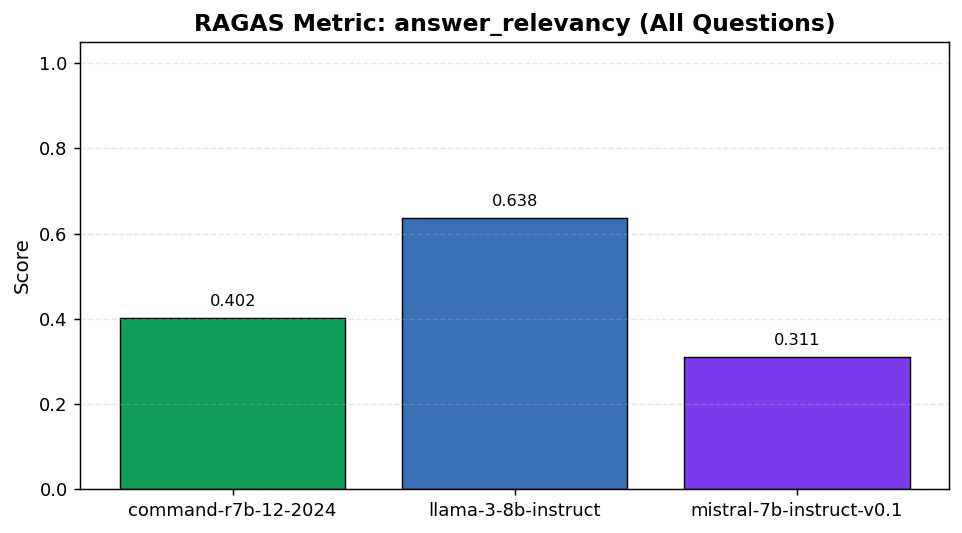

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_all_answer_relevancy.png


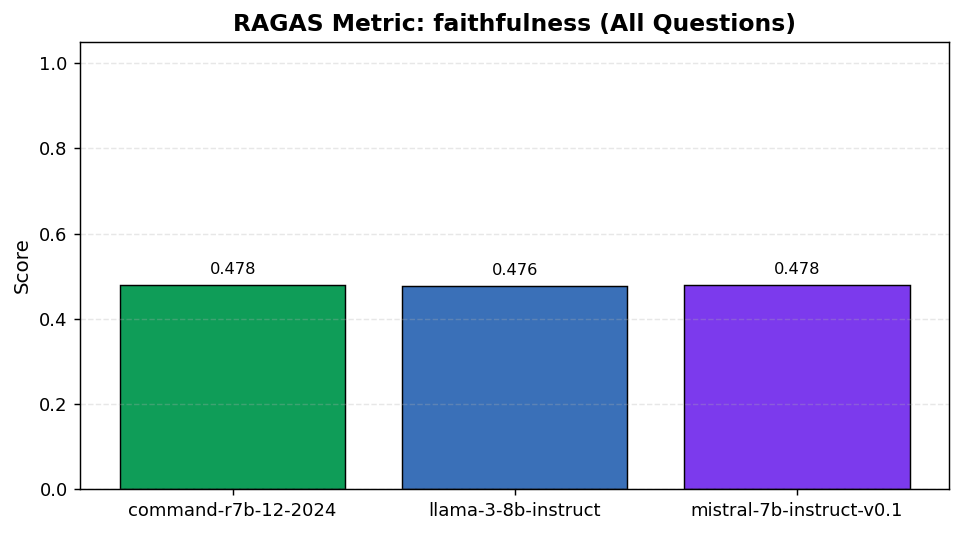

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_all_faithfulness.png


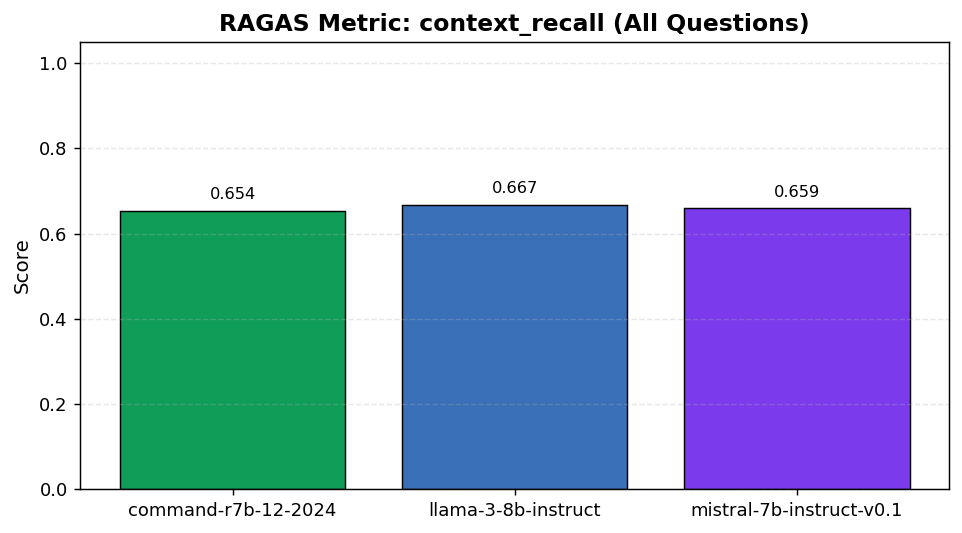

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_all_context_recall.png


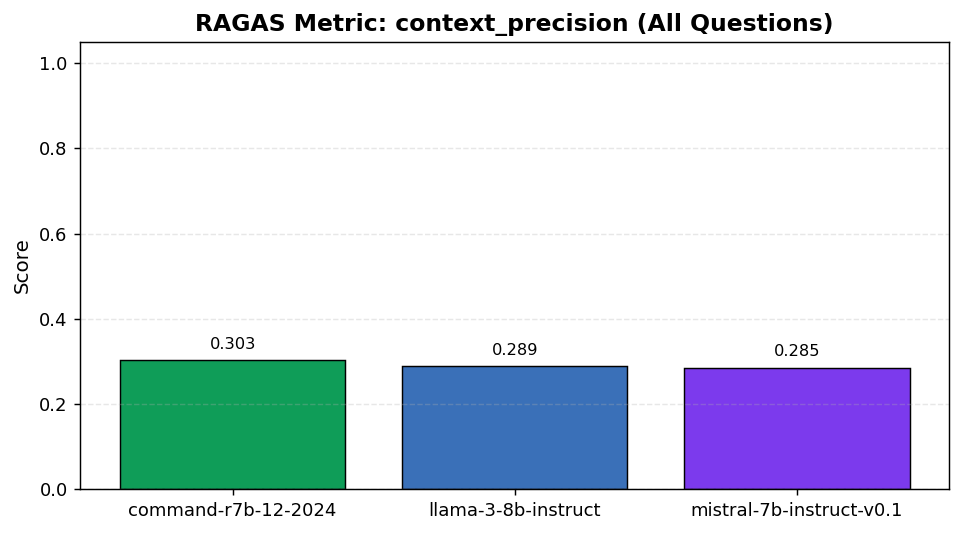

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_all_context_precision.png


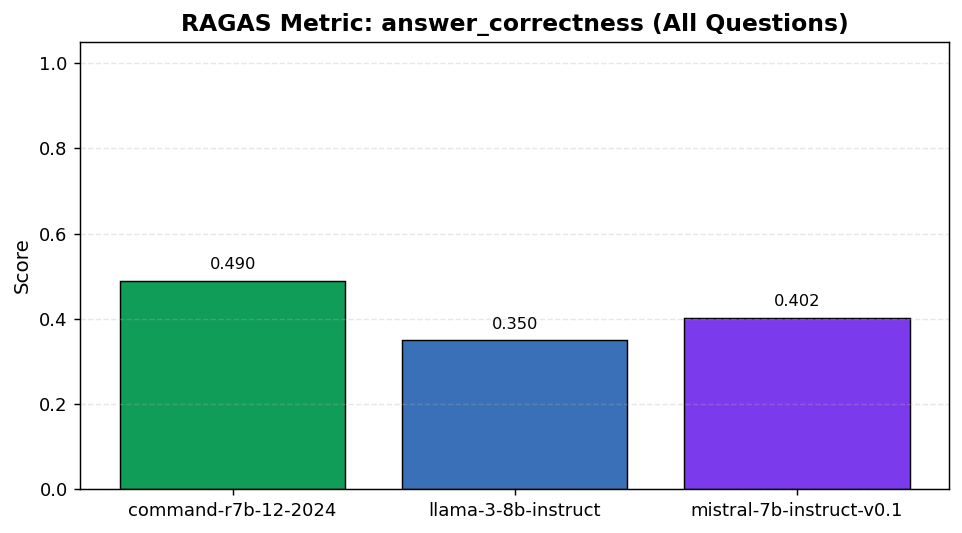

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_all_answer_correctness.png


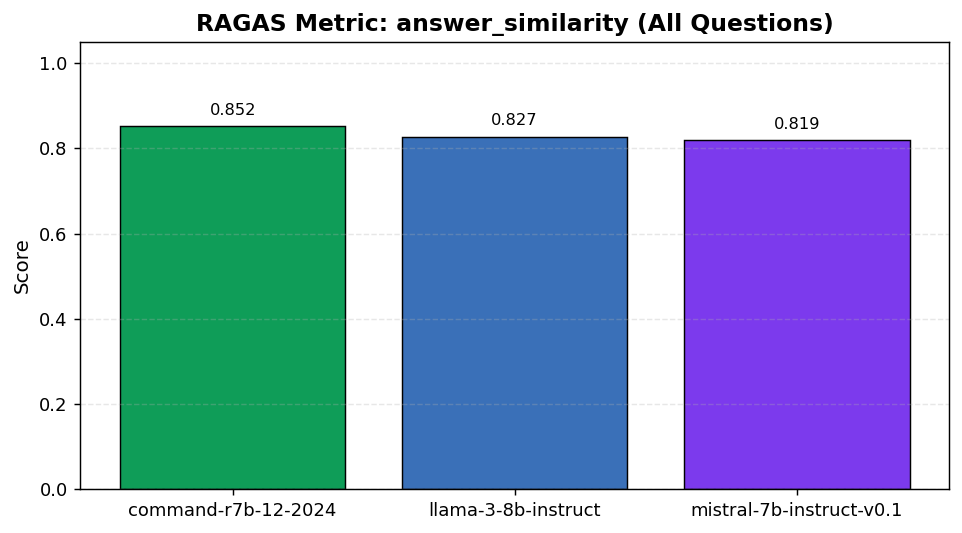

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_all_answer_similarity.png


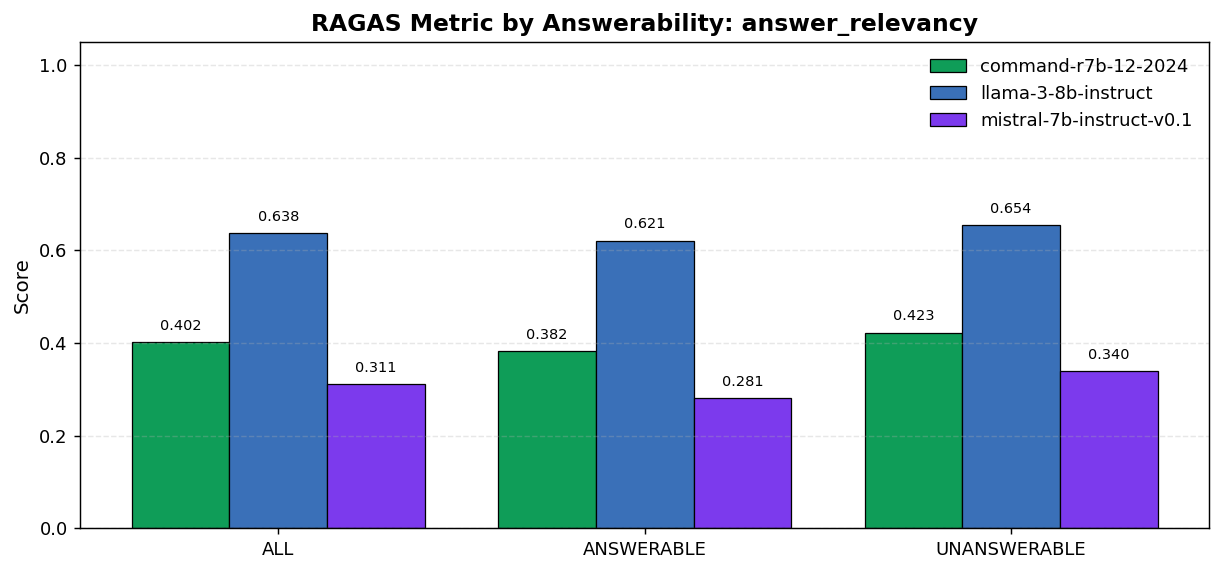

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_by_subset_answer_relevancy.png


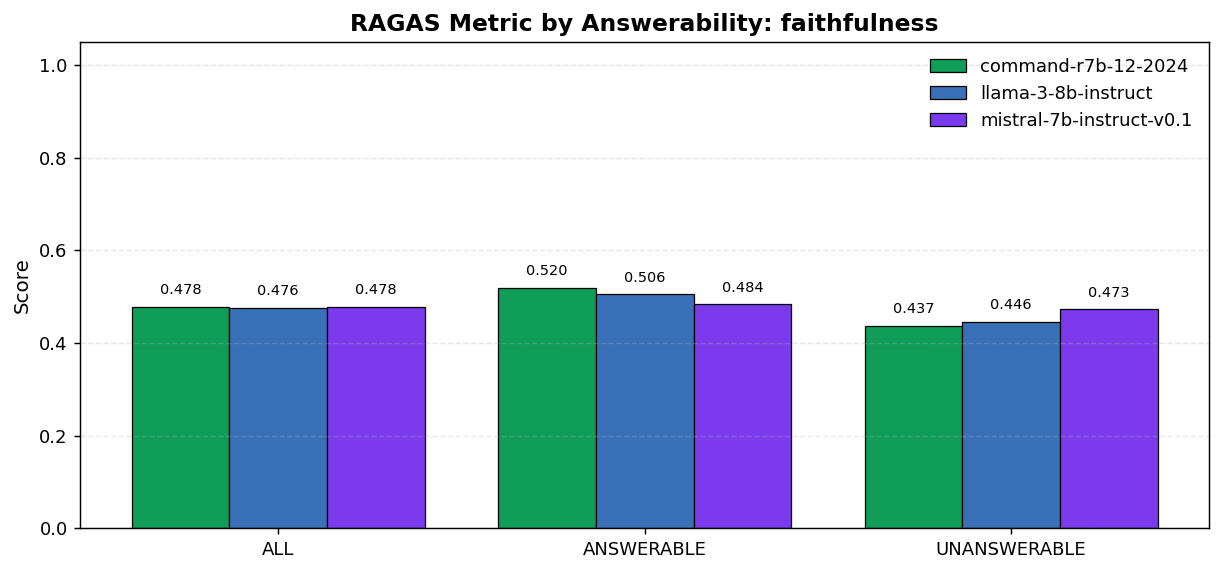

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_by_subset_faithfulness.png


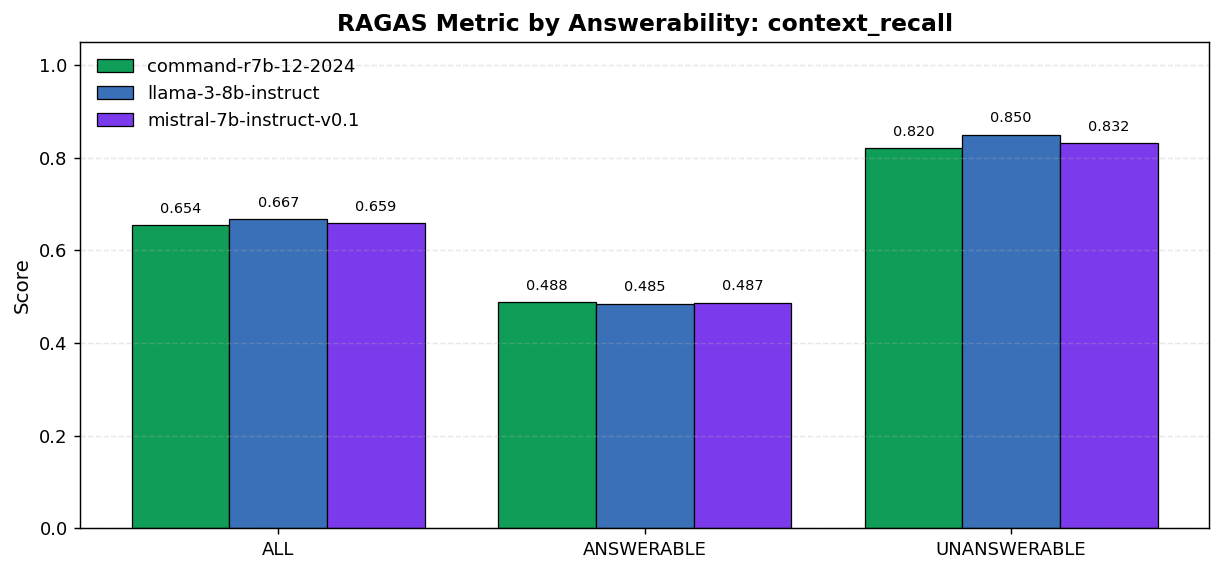

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_by_subset_context_recall.png


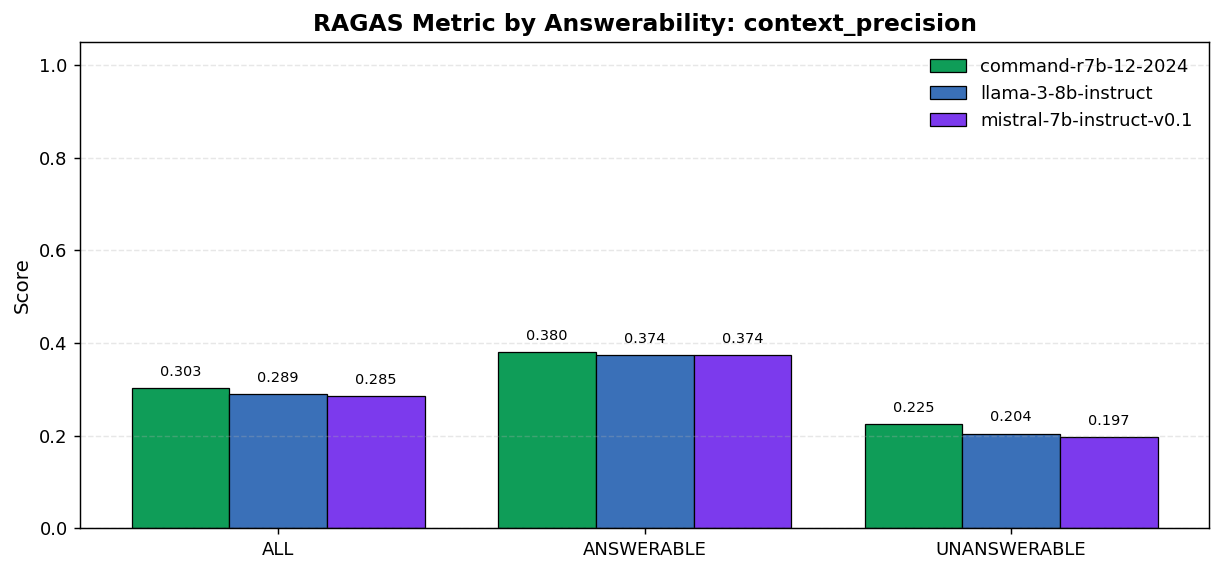

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_by_subset_context_precision.png


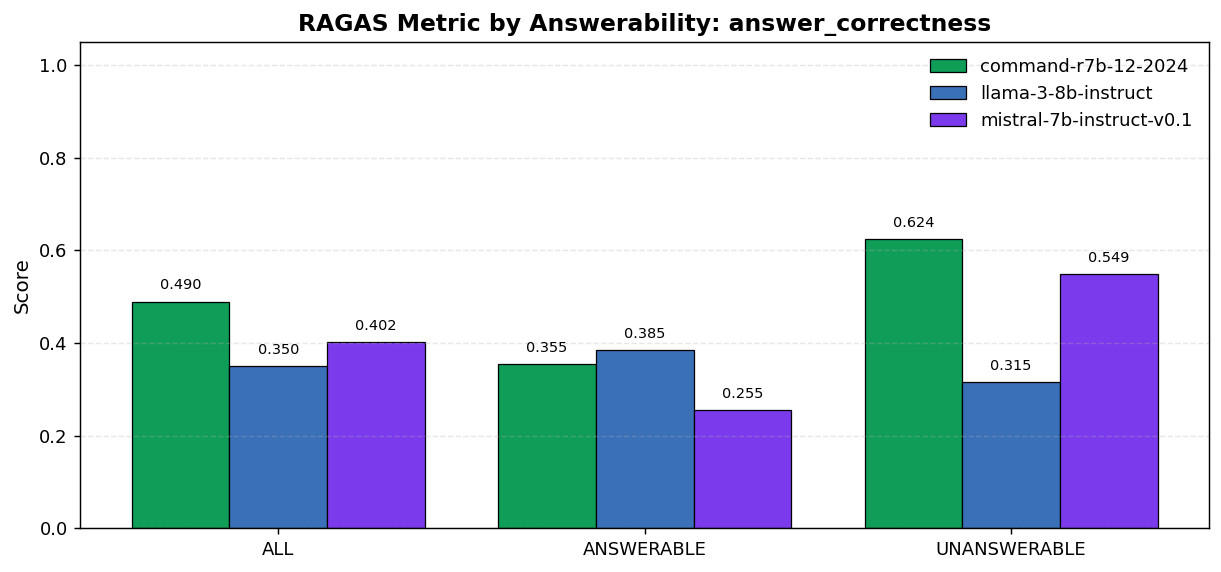

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_by_subset_answer_correctness.png


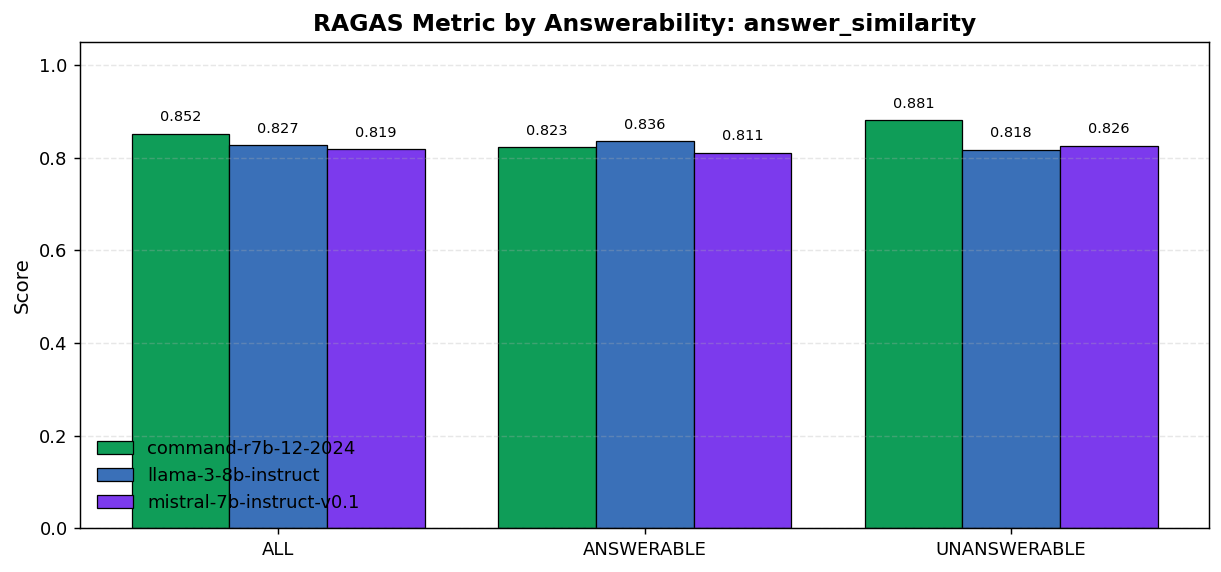

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_by_subset_answer_similarity.png


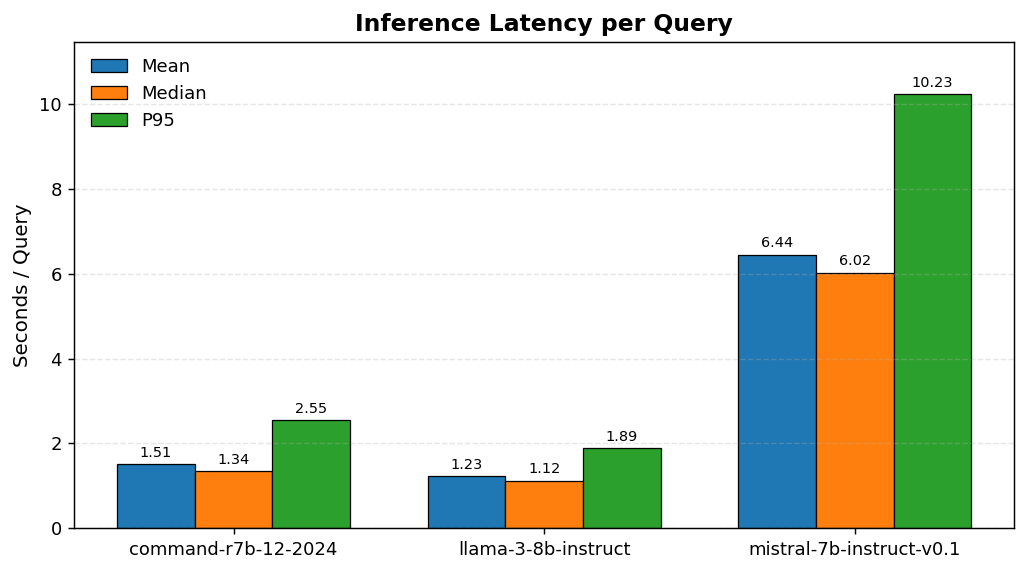

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\inference_latency_summary.png


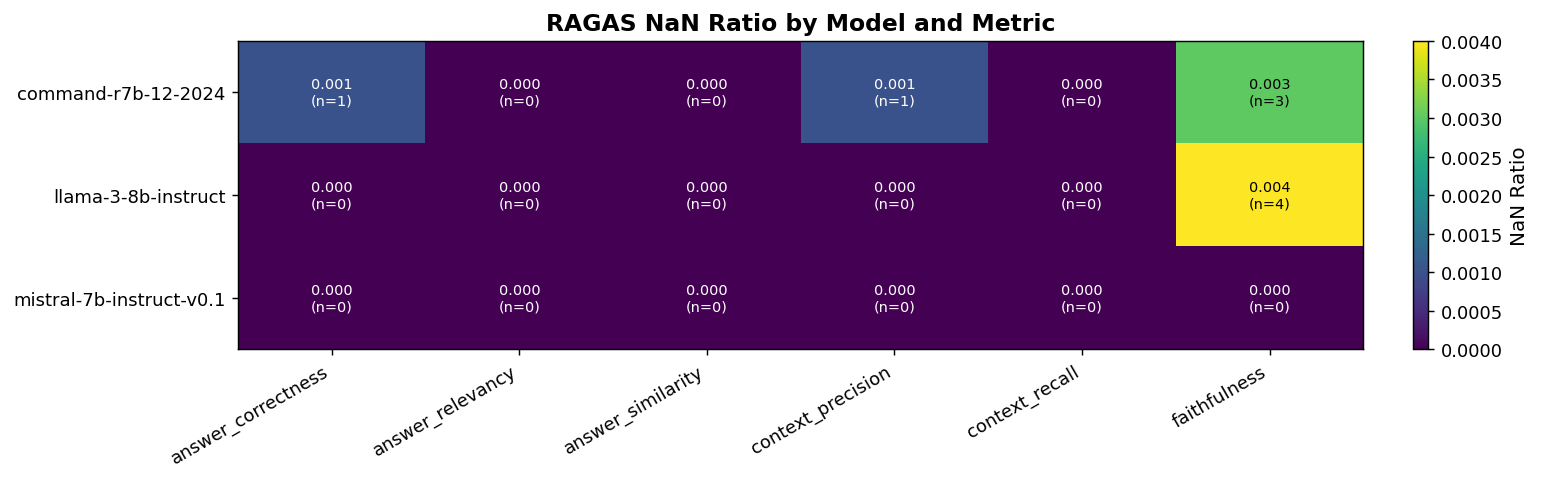

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_nan_heatmap.png


C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_12152\2089828748.py:441: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


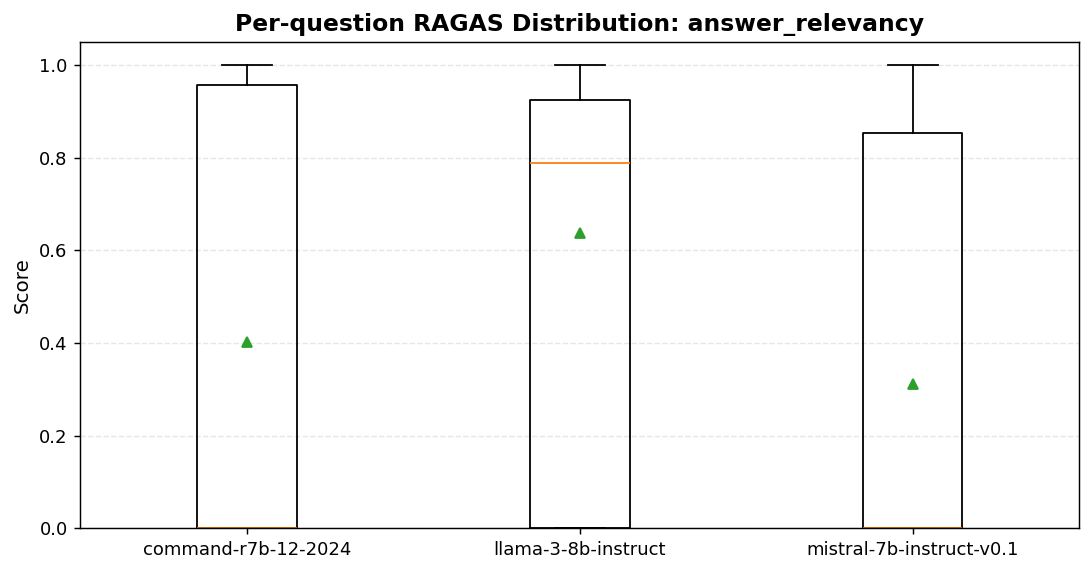

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_distribution_answer_relevancy.png


C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_12152\2089828748.py:441: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


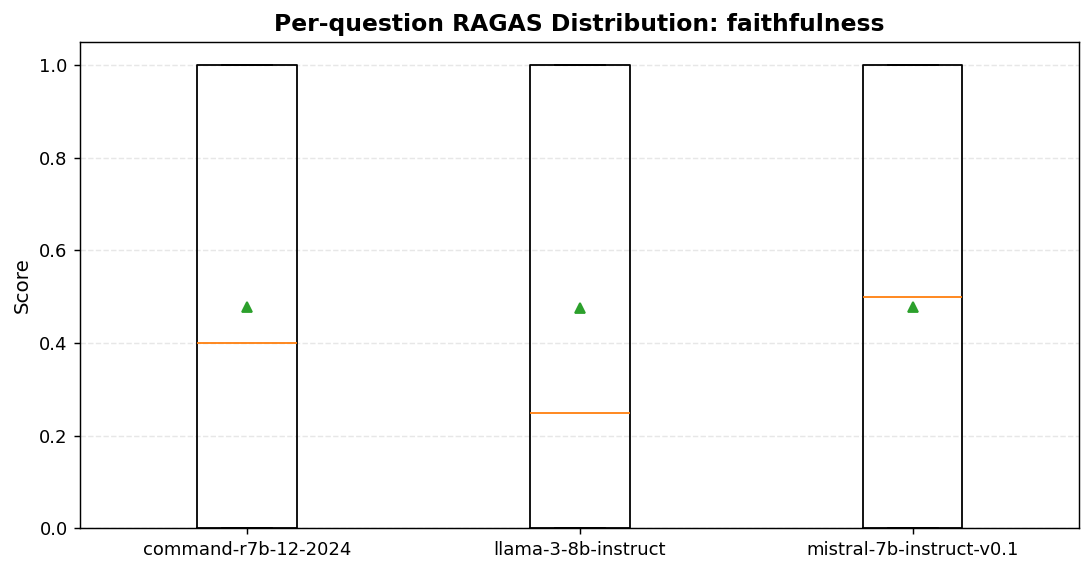

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_distribution_faithfulness.png


C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_12152\2089828748.py:441: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


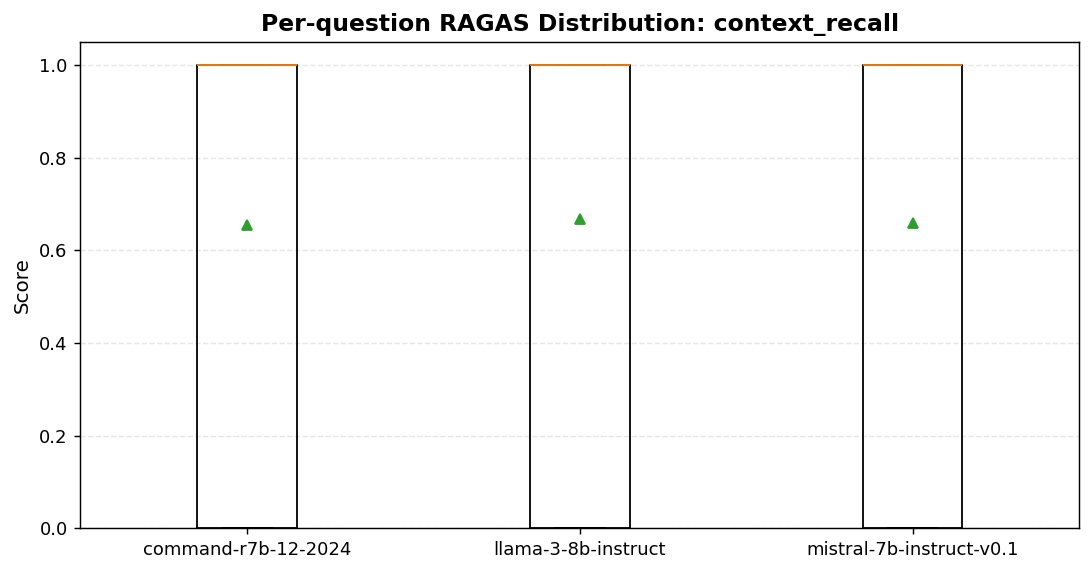

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_distribution_context_recall.png


C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_12152\2089828748.py:441: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


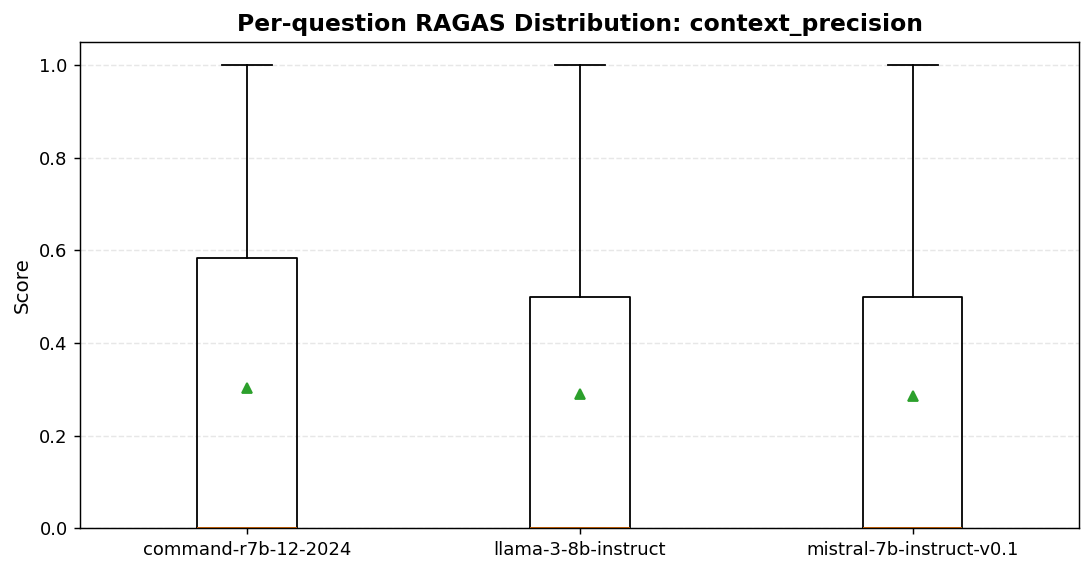

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_distribution_context_precision.png


C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_12152\2089828748.py:441: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


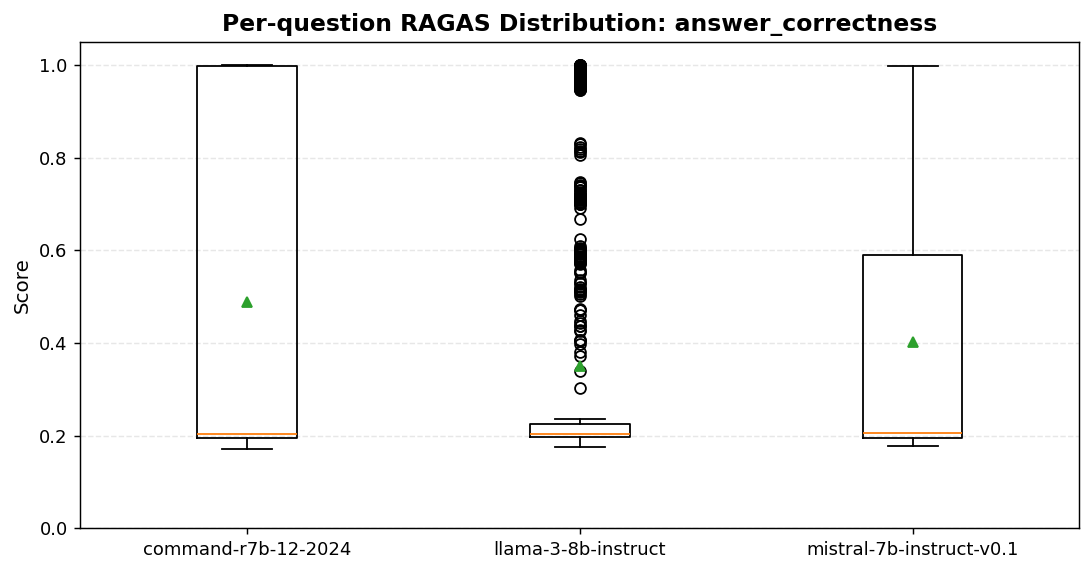

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_distribution_answer_correctness.png


C:\Users\Zohoor Almalki\AppData\Local\Temp\ipykernel_12152\2089828748.py:441: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(


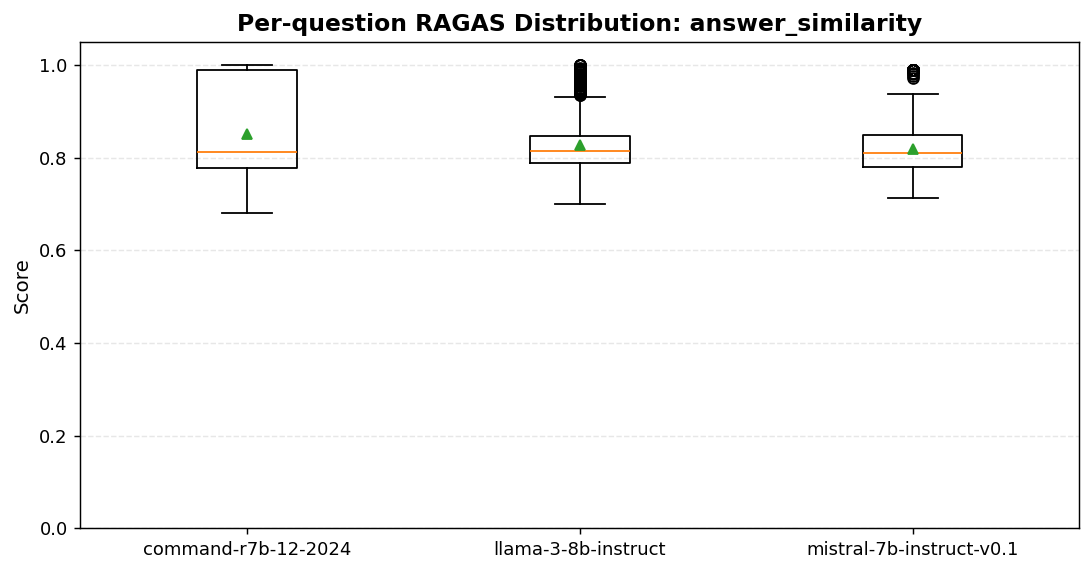

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_distribution_answer_similarity.png

Done. Figures saved in: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures


In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

# ============================================================
# 0) Paths
# ============================================================
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full_llama_mistral_command"

summary_path = os.path.join(OUTPUT_DIR, "ragas_summary_means.csv")
per_question_path = os.path.join(OUTPUT_DIR, "ragas_per_question_all_models.csv")
nan_path = os.path.join(OUTPUT_DIR, "ragas_nan_report.csv")
latency_path = os.path.join(OUTPUT_DIR, "latency_summary.csv")

FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

if not os.path.exists(summary_path):
    raise FileNotFoundError(f"Missing summary file: {summary_path}")

df_summary = pd.read_csv(summary_path, encoding="utf-8-sig")
df_per_question = pd.read_csv(per_question_path, encoding="utf-8-sig") if os.path.exists(per_question_path) else None
df_nan = pd.read_csv(nan_path, encoding="utf-8-sig") if os.path.exists(nan_path) else None
df_latency = pd.read_csv(latency_path, encoding="utf-8-sig") if os.path.exists(latency_path) else None

print("Loaded RAGAS summary:", df_summary.shape)
# ============================================================
# DISPLAY NAMES FOR FIGURES
# ============================================================
df_summary_plot = df_summary.copy()

df_summary_plot["model"] = df_summary_plot["model"].map(
    lambda x: MODEL_DISPLAY_NAMES.get(str(x), str(x))
)

if df_nan is not None:
    print("\nLoaded NaN report:", df_nan.shape)

if df_latency is not None:
    print("\nLoaded latency summary:", df_latency.shape)
    print(df_latency.round(4).to_string(index=False))

# ============================================================
# 1) Plot configuration
# ============================================================
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 13

# Use clear, publication-friendly colors
MODEL_COLORS = {
    "llama-3-8b-instruct": "#3A70B8",
    "mistral-7b-instruct-v0.1": "#7C3AED",
    "command-r7b-12-2024": "#0F9D58",
}

SUBSET_ORDER = ["ALL", "ANSWERABLE", "UNANSWERABLE"]

# ============================================================
# Helper functions
# ============================================================
def add_bar_labels(ax, bars, fmt="{:.3f}", offset=0.02, fontsize=8):
    """Add numeric labels above bar charts."""
    for bar in bars:
        height = bar.get_height()

        if pd.notna(height):
            ax.text(
                bar.get_x() + bar.get_width() / 2,
                height + offset,
                fmt.format(height),
                ha="center",
                va="bottom",
                fontsize=fontsize
            )


def get_contrast_text_color(im, value):
    """Return white text for dark heatmap cells and black text for light cells."""
    rgba = im.cmap(im.norm(value))
    r, g, b = rgba[:3]

    # Perceived brightness formula
    luminance = 0.299 * r + 0.587 * g + 0.114 * b

    return "white" if luminance < 0.5 else "black"


# ============================================================
# 2) Detect RAGAS metric columns
# ============================================================
metadata_cols = {
    "model",
    "subset",
    "n_questions",
    "generation_latency_mean_sec",
    "generation_latency_median_sec",
    "generation_latency_p95_sec",
    "ragas_avg_latency_sec_per_question",
}

metric_cols = [
    c for c in df_summary.columns
    if c not in metadata_cols
]

for c in metric_cols:
    df_summary[c] = pd.to_numeric(df_summary[c], errors="coerce")

metric_cols = [
    c for c in metric_cols
    if df_summary[c].notna().any()
]

print("\nDetected RAGAS metrics:", metric_cols)

# ============================================================
# 3) Figure A: RAGAS metrics for ALL subset only
# Best for main paper
# ============================================================
df_all = df_summary[df_summary["subset"] == "ALL"].copy()

if not df_all.empty:
    for metric in metric_cols:
        fig, ax = plt.subplots(figsize=(7.5, 4.2))

        df_plot = df_all.copy()
        df_plot["model"] = df_plot["model"].astype(str)

        colors = [
            MODEL_COLORS.get(m.lower(), "#777777")
            for m in df_plot["model"]
        ]

        bars = ax.bar(
            df_plot["model"],
            df_plot[metric],
            color=colors,
            edgecolor="black",
            linewidth=0.8
        )

        ax.set_title(f"RAGAS Metric: {metric} (All Questions)")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        add_bar_labels(
            ax=ax,
            bars=bars,
            fmt="{:.3f}",
            offset=0.02,
            fontsize=9
        )

        plt.tight_layout()

        safe_name = metric.replace("/", "_").replace(" ", "_")
        png_path = os.path.join(FIG_DIR, f"ragas_all_{safe_name}.png")
        pdf_path = os.path.join(FIG_DIR, f"ragas_all_{safe_name}.pdf")

        plt.savefig(png_path, bbox_inches="tight")
        plt.savefig(pdf_path, bbox_inches="tight")
        plt.show()

        print(f"Saved: {png_path}")

# ============================================================
# 4) Figure B: Grouped bar chart per metric across subsets
# Good for appendix or detailed results
# ============================================================
for metric in metric_cols:
    df_plot = df_summary.copy()
    df_plot = df_plot[df_plot["subset"].isin(SUBSET_ORDER)].copy()

    models = sorted(df_plot["model"].astype(str).unique().tolist())
    subsets = [s for s in SUBSET_ORDER if s in df_plot["subset"].unique()]

    x = np.arange(len(subsets))
    width = 0.8 / max(len(models), 1)

    fig, ax = plt.subplots(figsize=(9.5, 4.5))

    for i, model in enumerate(models):
        values = []
        for subset in subsets:
            val = df_plot[
                (df_plot["model"].astype(str) == model) &
                (df_plot["subset"] == subset)
            ][metric]

            values.append(float(val.iloc[0]) if len(val) else np.nan)

        offset = (i - (len(models) - 1) / 2) * width

        bars = ax.bar(
            x + offset,
            values,
            width,
            label=model,
            color=MODEL_COLORS.get(model.lower(), "#777777"),
            edgecolor="black",
            linewidth=0.7
        )

        add_bar_labels(
            ax=ax,
            bars=bars,
            fmt="{:.3f}",
            offset=0.02,
            fontsize=8
        )

    ax.set_title(f"RAGAS Metric by Answerability: {metric}")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.set_xticks(x)
    ax.set_xticklabels(subsets)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(frameon=False)

    plt.tight_layout()

    safe_name = metric.replace("/", "_").replace(" ", "_")
    png_path = os.path.join(FIG_DIR, f"ragas_by_subset_{safe_name}.png")
    pdf_path = os.path.join(FIG_DIR, f"ragas_by_subset_{safe_name}.pdf")

    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    print(f"Saved: {png_path}")

# ============================================================
# 5) Figure C: Latency comparison
# Main paper candidate
# ============================================================
if df_latency is not None and not df_latency.empty:
    latency_cols = [
        "generation_latency_mean_sec",
        "generation_latency_median_sec",
        "generation_latency_p95_sec",
    ]

    for c in latency_cols:
        if c in df_latency.columns:
            df_latency[c] = pd.to_numeric(df_latency[c], errors="coerce")

    fig, ax = plt.subplots(figsize=(8, 4.5))

    df_lat = df_latency.copy()
    df_lat["model"] = df_lat["model"].astype(str)

    x = np.arange(len(df_lat))
    width = 0.25

    bars_mean = ax.bar(
        x - width,
        df_lat["generation_latency_mean_sec"],
        width,
        label="Mean",
        edgecolor="black",
        linewidth=0.7
    )

    bars_median = ax.bar(
        x,
        df_lat["generation_latency_median_sec"],
        width,
        label="Median",
        edgecolor="black",
        linewidth=0.7
    )

    bars_p95 = ax.bar(
        x + width,
        df_lat["generation_latency_p95_sec"],
        width,
        label="P95",
        edgecolor="black",
        linewidth=0.7
    )

    max_latency = df_lat[latency_cols].max().max()
    latency_label_offset = max_latency * 0.01 if pd.notna(max_latency) and max_latency > 0 else 0.02

    add_bar_labels(
        ax=ax,
        bars=bars_mean,
        fmt="{:.2f}",
        offset=latency_label_offset,
        fontsize=8
    )

    add_bar_labels(
        ax=ax,
        bars=bars_median,
        fmt="{:.2f}",
        offset=latency_label_offset,
        fontsize=8
    )

    add_bar_labels(
        ax=ax,
        bars=bars_p95,
        fmt="{:.2f}",
        offset=latency_label_offset,
        fontsize=8
    )

    if pd.notna(max_latency) and max_latency > 0:
        ax.set_ylim(0, max_latency * 1.12)

    ax.set_title("Inference Latency per Query")
    ax.set_ylabel("Seconds / Query")
    ax.set_xticks(x)
    ax.set_xticklabels(df_lat["model"].tolist())
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(frameon=False)

    plt.tight_layout()

    png_path = os.path.join(FIG_DIR, "inference_latency_summary.png")
    pdf_path = os.path.join(FIG_DIR, "inference_latency_summary.pdf")

    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    print(f"Saved: {png_path}")

# ============================================================
# 6) Figure D: NaN ratio heatmap
# Diagnostic; better for appendix/supplementary
# ============================================================
if df_nan is not None and not df_nan.empty:
    df_nan2 = df_nan.copy()
    df_nan2["model"] = df_nan2["model"].astype(str)
    df_nan2["subset"] = df_nan2["subset"].astype(str)
    df_nan2["metric"] = df_nan2["metric"].astype(str)
    df_nan2["nan_ratio"] = pd.to_numeric(df_nan2["nan_ratio"], errors="coerce")
    df_nan2["nan_count"] = pd.to_numeric(df_nan2["nan_count"], errors="coerce")

    # Prefer ALL subset for cleaner diagnostics
    df_nan_all = df_nan2[df_nan2["subset"] == "ALL"].copy()
    if df_nan_all.empty:
        df_nan_all = df_nan2.copy()

    pivot_ratio = (
        df_nan_all.pivot_table(
            index="model",
            columns="metric",
            values="nan_ratio",
            aggfunc="mean"
        )
        .fillna(0.0)
    )

    pivot_count = (
        df_nan_all.pivot_table(
            index="model",
            columns="metric",
            values="nan_count",
            aggfunc="sum"
        )
        .fillna(0)
    )

    fig, ax = plt.subplots(figsize=(12, 3.8))

    # Important: scale color to the actual maximum, not 1.0
    vmax = max(pivot_ratio.values.max(), 0.001)

    im = ax.imshow(
        pivot_ratio.values,
        aspect="auto",
        vmin=0,
        vmax=vmax
    )

    ax.set_title("RAGAS NaN Ratio by Model and Metric")
    ax.set_yticks(np.arange(len(pivot_ratio.index)))
    ax.set_yticklabels(pivot_ratio.index.tolist())

    ax.set_xticks(np.arange(len(pivot_ratio.columns)))
    ax.set_xticklabels(pivot_ratio.columns.tolist(), rotation=30, ha="right")

    for i in range(len(pivot_ratio.index)):
        for j in range(len(pivot_ratio.columns)):
            ratio_value = pivot_ratio.values[i, j]
            count_value = int(pivot_count.values[i, j])

            text_color = get_contrast_text_color(im, ratio_value)

            ax.text(
                j,
                i,
                f"{ratio_value:.3f}\n(n={count_value})",
                ha="center",
                va="center",
                fontsize=8,
                color=text_color
            )

    cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("NaN Ratio")

    plt.tight_layout()

    png_path = os.path.join(FIG_DIR, "ragas_nan_heatmap.png")
    pdf_path = os.path.join(FIG_DIR, "ragas_nan_heatmap.pdf")

    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    plt.show()

    print(f"Saved: {png_path}")

# ============================================================
# 7) Optional: Per-question score distributions
# Useful if reviewer asks for uncertainty/variation
# ============================================================
if df_per_question is not None and not df_per_question.empty:
    for metric in metric_cols:
        if metric not in df_per_question.columns:
            continue

        df_pq = df_per_question.copy()
        df_pq[metric] = pd.to_numeric(df_pq[metric], errors="coerce")
        df_pq = df_pq.dropna(subset=[metric])

        if df_pq.empty:
            continue

        models = sorted(df_pq["model"].astype(str).unique().tolist())

        fig, ax = plt.subplots(figsize=(8.5, 4.5))

        data = [
            df_pq[df_pq["model"].astype(str) == m][metric].values
            for m in models
        ]

        ax.boxplot(
            data,
            labels=models,
            showmeans=True
        )

        ax.set_title(f"Per-question RAGAS Distribution: {metric}")
        ax.set_ylabel("Score")
        ax.set_ylim(0, 1.05)
        ax.grid(axis="y", linestyle="--", alpha=0.3)

        plt.tight_layout()

        safe_name = metric.replace("/", "_").replace(" ", "_")
        png_path = os.path.join(FIG_DIR, f"ragas_distribution_{safe_name}.png")
        pdf_path = os.path.join(FIG_DIR, f"ragas_distribution_{safe_name}.pdf")

        plt.savefig(png_path, bbox_inches="tight")
        plt.savefig(pdf_path, bbox_inches="tight")
        plt.show()

        print(f"Saved: {png_path}")

print("\nDone. Figures saved in:", FIG_DIR)

In [6]:
print(df_nan.head(20).to_string(index=False))

print("\nUnique subsets:")
print(df_nan["subset"].unique())

print("\nNaN ratio summary:")
print(df_nan["nan_ratio"].describe())

print("\nRows with NaN ratio > 0:")
print(df_nan[df_nan["nan_ratio"] > 0].to_string(index=False))

              model model_key       subset             metric  nan_count  n_questions  nan_ratio
command-r7b-12-2024   command          ALL   answer_relevancy          0         1000      0.000
command-r7b-12-2024   command          ALL       faithfulness          3         1000      0.003
command-r7b-12-2024   command          ALL     context_recall          0         1000      0.000
command-r7b-12-2024   command          ALL  context_precision          1         1000      0.001
command-r7b-12-2024   command          ALL answer_correctness          1         1000      0.001
command-r7b-12-2024   command          ALL  answer_similarity          0         1000      0.000
command-r7b-12-2024   command   ANSWERABLE   answer_relevancy          0          500      0.000
command-r7b-12-2024   command   ANSWERABLE       faithfulness          1          500      0.002
command-r7b-12-2024   command   ANSWERABLE     context_recall          0          500      0.000
command-r7b-12-2024   command 

Loaded: arabicaqa_rag_results/ragas_full_llama_mistral_command\ragas_summary_means.csv
                   model model_key       subset  n_questions  generation_latency_mean_sec  generation_latency_median_sec  generation_latency_p95_sec  ragas_avg_latency_sec_per_question  answer_relevancy  faithfulness  context_recall  context_precision  answer_correctness  answer_similarity
     command-r7b-12-2024   command          ALL         1000                       1.5116                         1.3402                      2.5462                             61.3035            0.4023        0.4785          0.6540             0.3027              0.4896             0.8518
     llama-3-8b-instruct     llama          ALL         1000                       1.2330                         1.1216                      1.8918                             50.2727            0.6376        0.4761          0.6675             0.2894              0.3497             0.8270
mistral-7b-instruct-v0.1   mistral      

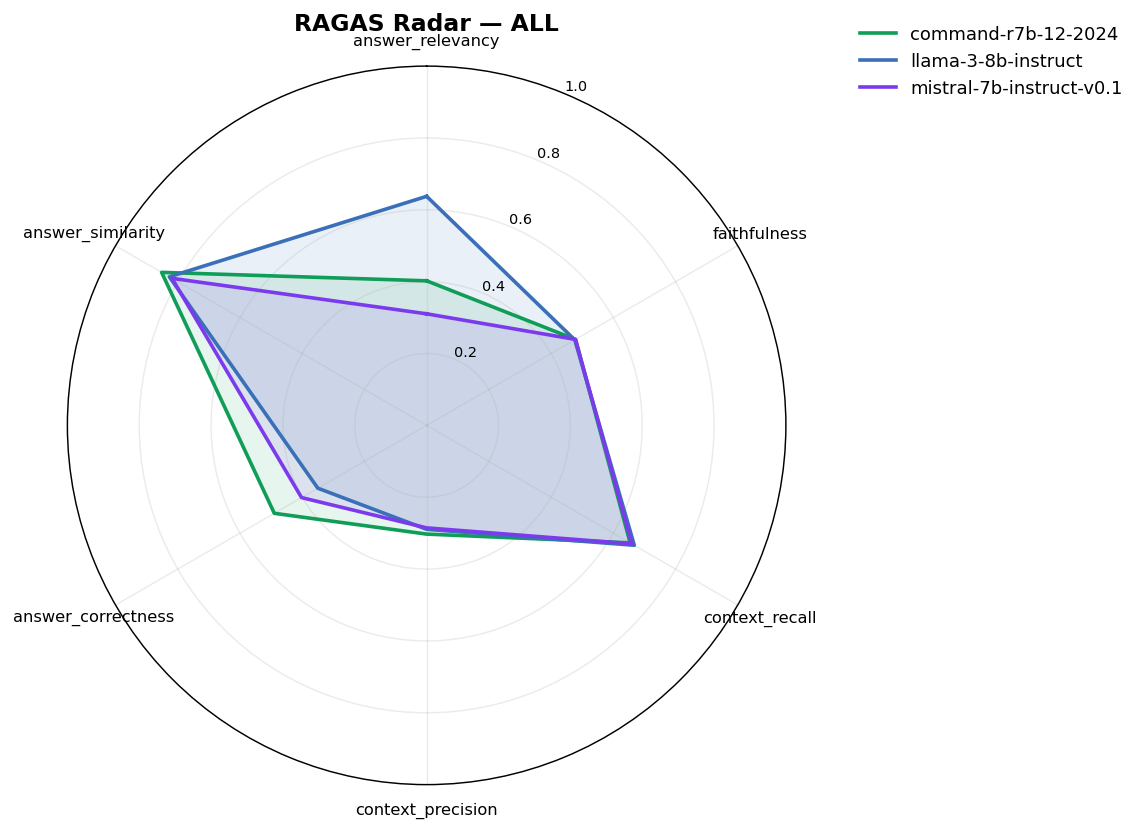

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_radar_all.png


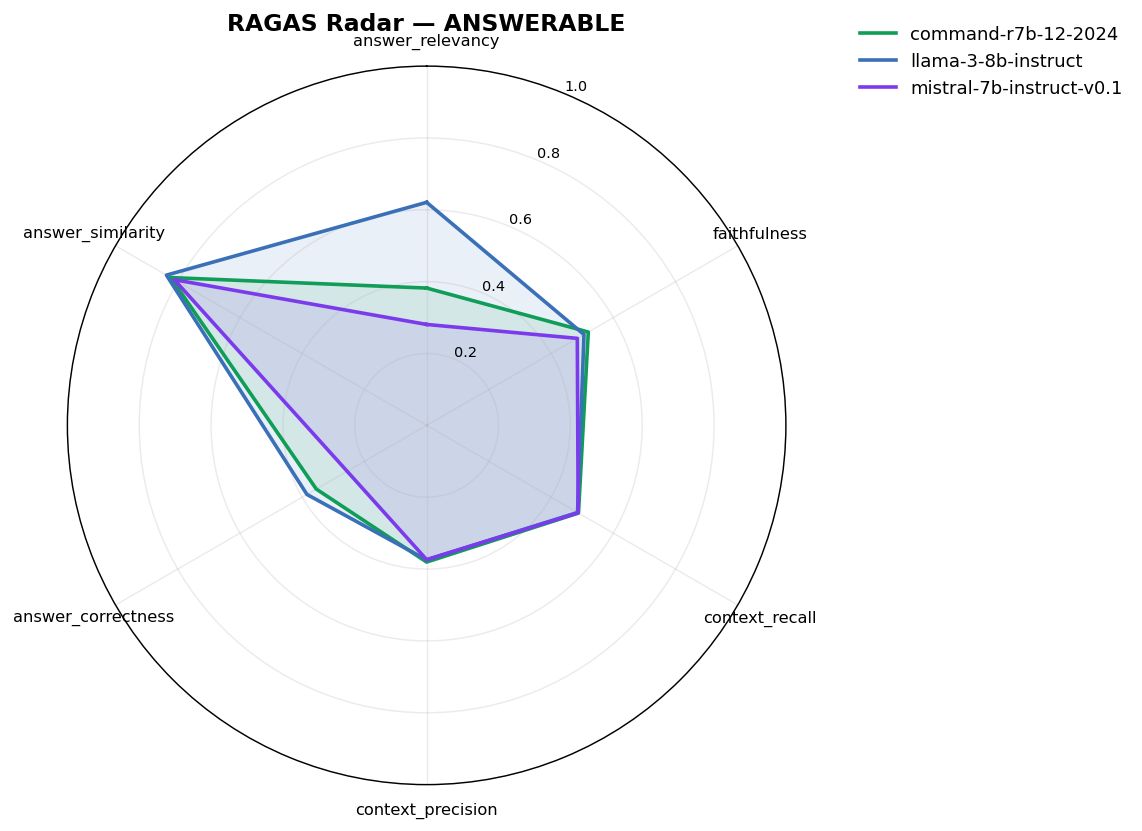

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_radar_answerable.png


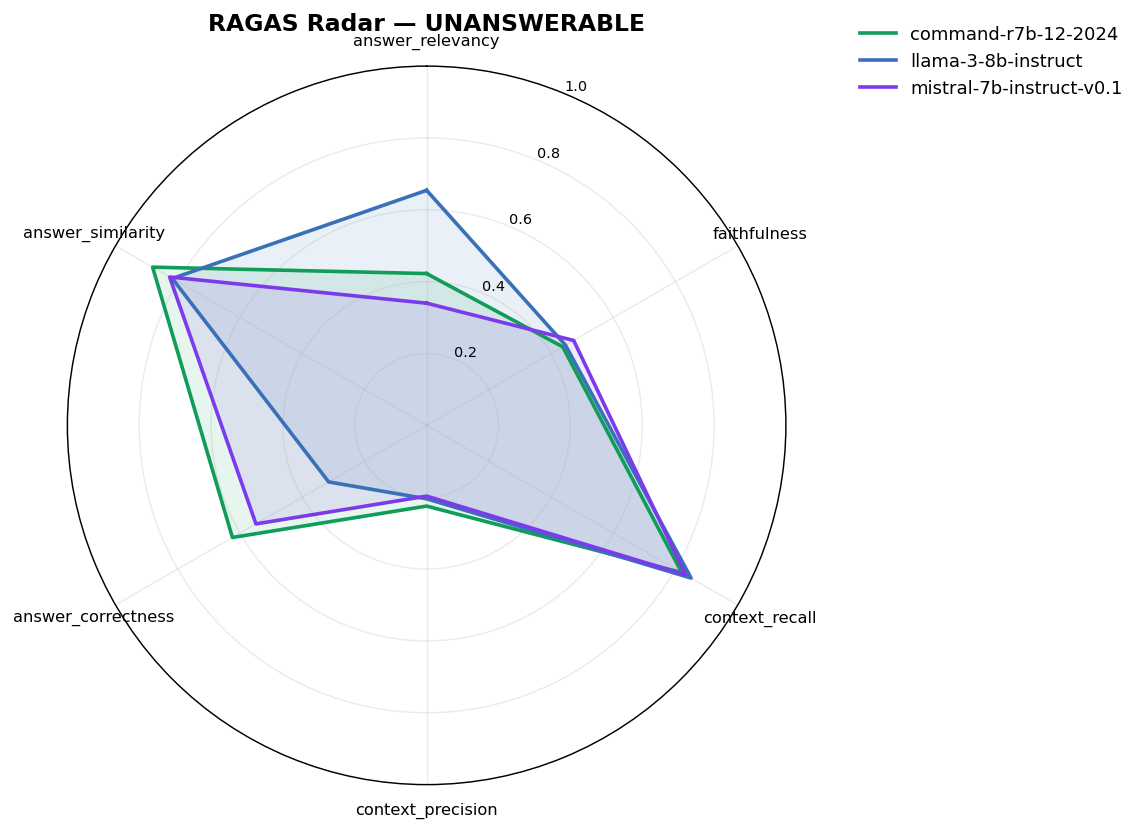

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_radar_unanswerable.png


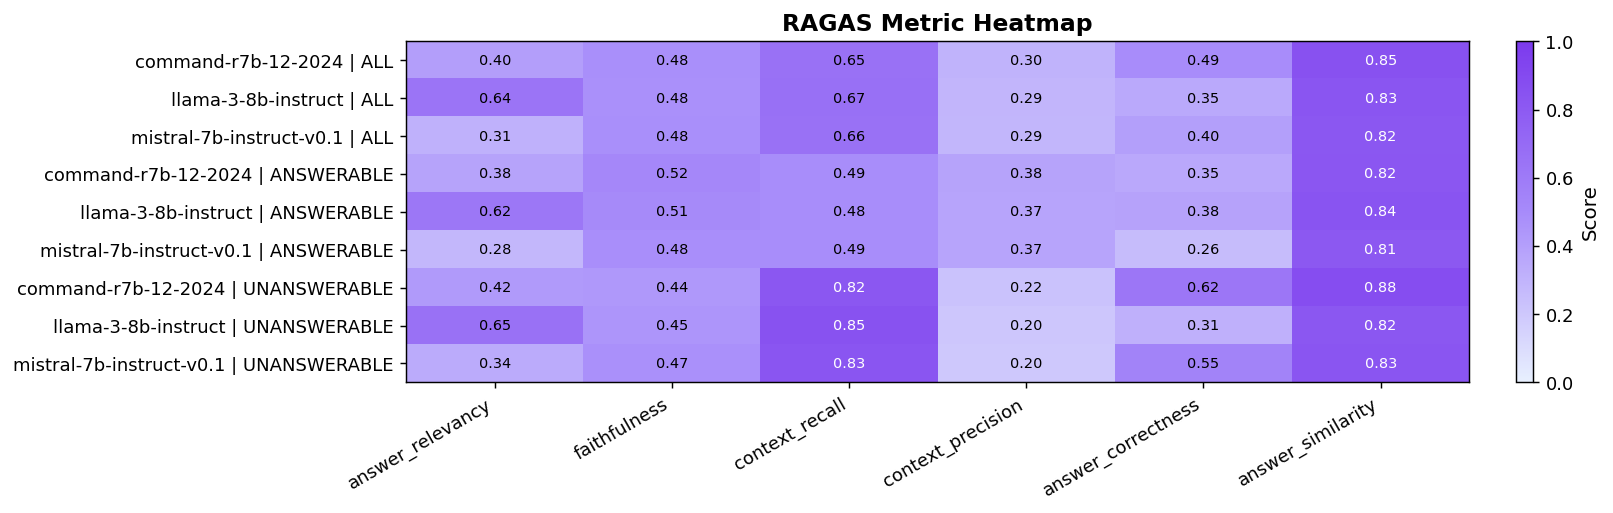

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_metric_heatmap.png
Saved rank table: arabicaqa_rag_results/ragas_full_llama_mistral_command\ragas_metric_ranks.csv


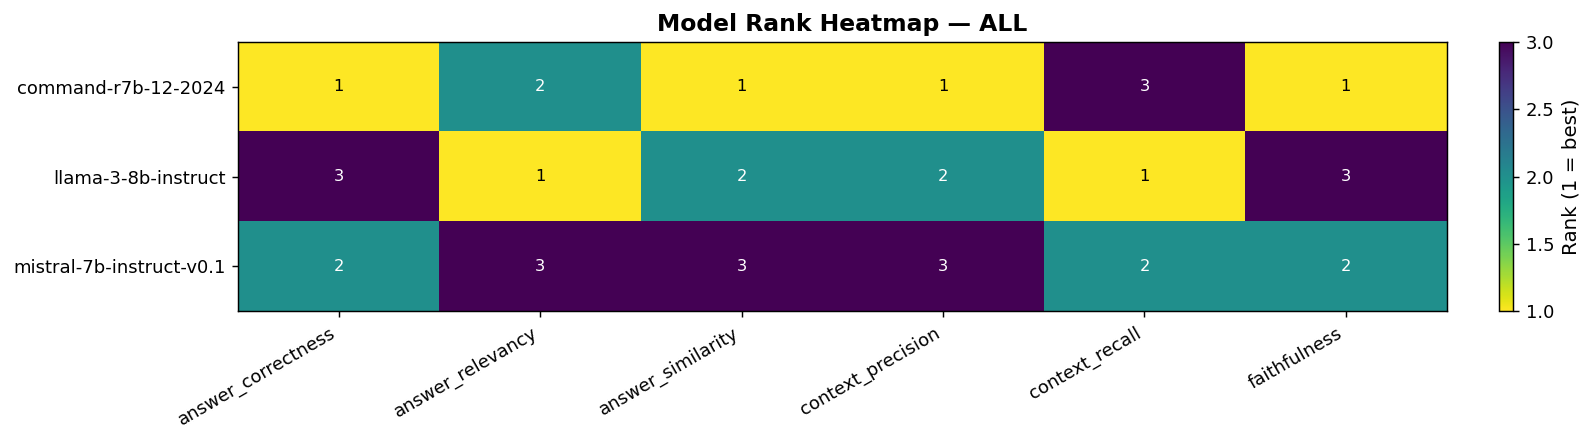

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_rank_heatmap_all.png


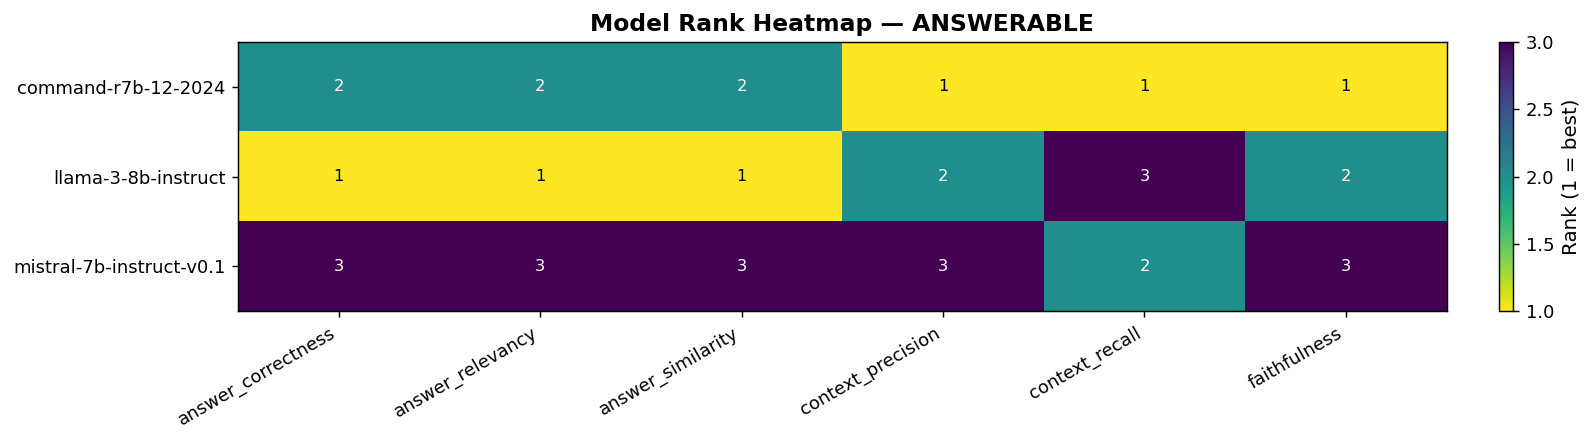

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_rank_heatmap_answerable.png


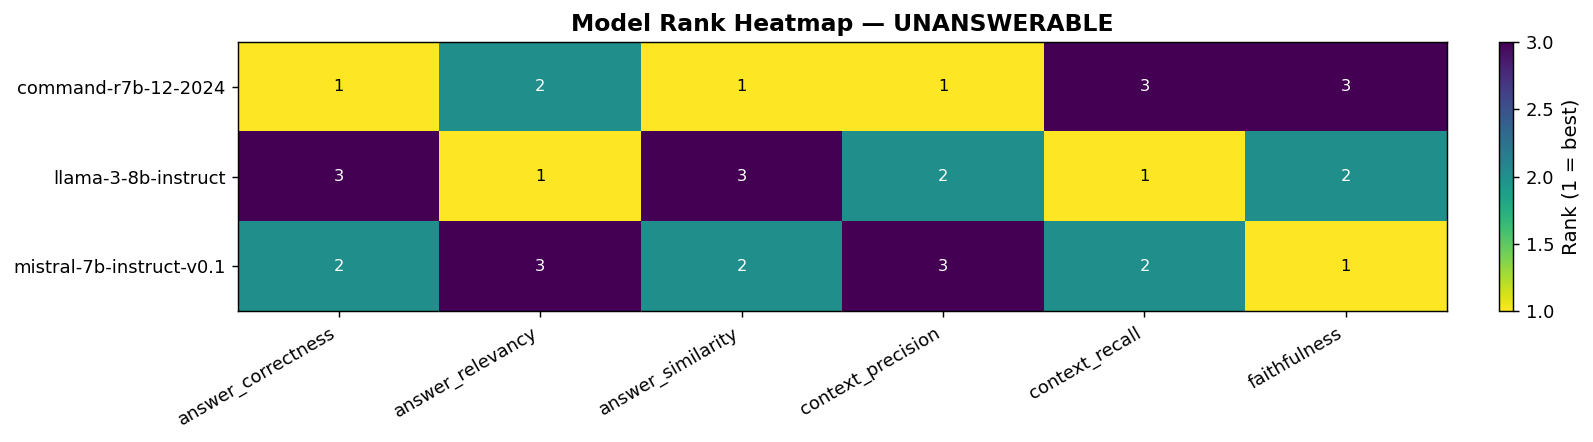

Saved: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures\ragas_rank_heatmap_unanswerable.png

Done. Additional figures saved in: arabicaqa_rag_results/ragas_full_llama_mistral_command\figures


In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch

# ============================================================
# 0) Paths
# ============================================================
OUTPUT_DIR = "arabicaqa_rag_results/ragas_full_llama_mistral_command"
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")
os.makedirs(FIG_DIR, exist_ok=True)

summary_path = os.path.join(OUTPUT_DIR, "ragas_summary_means.csv")

if not os.path.exists(summary_path):
    raise FileNotFoundError(f"Missing RAGAS summary file: {summary_path}")

df_plot = pd.read_csv(summary_path, encoding="utf-8-sig")

print("Loaded:", summary_path)
print(df_plot.round(4).to_string(index=False))

# ============================================================
# 1) Basic preparation
# ============================================================
df_plot["model"] = df_plot["model"].astype(str)
df_plot["subset"] = df_plot["subset"].astype(str).str.upper()
df_plot["group"] = df_plot["model"] + " | " + df_plot["subset"]

metadata_cols = {
    "model",
    "subset",
    "n_questions",
    "group",
    "generation_latency_mean_sec",
    "generation_latency_median_sec",
    "generation_latency_p95_sec",
    "ragas_avg_latency_sec_per_question",
}

metric_cols = [
    c for c in df_plot.columns
    if c not in metadata_cols
]

for c in metric_cols:
    df_plot[c] = pd.to_numeric(df_plot[c], errors="coerce")

metric_cols = [
    c for c in metric_cols
    if df_plot[c].notna().any()
]

print("\nDetected metrics:", metric_cols)

if len(metric_cols) == 0:
    raise ValueError("No RAGAS metric columns detected.")

# ============================================================
# 2) Theme / colors
# ============================================================
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 13

MODEL_COLORS = {
    "llama-3-8b-instruct": "#3A70B8",
    "mistral-7b-instruct-v0.1": "#7C3AED",
    "command-r7b-12-2024": "#0F9D58",
}

DEFAULT_COLOR = "#777777"

def get_contrast_text_color(im, value):
    rgba = im.cmap(im.norm(value))
    r, g, b = rgba[:3]

    luminance = 0.299 * r + 0.587 * g + 0.114 * b

    return "white" if luminance < 0.5 else "black"

# Colormap for heatmaps
theme_cmap = LinearSegmentedColormap.from_list(
    "theme_cmap_vals",
    ["#E8F0FE", "#A78BFA", "#7C3AED"]
)

SUBSET_ORDER = ["ALL", "ANSWERABLE", "UNANSWERABLE"]

# ============================================================
# 3) Radar chart for one subset
# ============================================================
def radar_chart_for_subset(df_plot, subset_name, metric_cols, fig_path_png, fig_path_pdf):
    sub = df_plot[df_plot["subset"].str.upper() == subset_name.upper()].copy()

    if sub.empty:
        print(f"[Radar] No rows for subset={subset_name}")
        return

    labels = metric_cols
    num_vars = len(labels)

    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]

    fig = plt.figure(figsize=(8, 6.5))
    ax = plt.subplot(111, polar=True)

    for _, row in sub.iterrows():
        model_name = str(row["model"])
        model_key = model_name.lower()

        values = [
            float(row[m]) if pd.notna(row[m]) else 0.0
            for m in labels
        ]
        values += values[:1]

        color = MODEL_COLORS.get(model_key, DEFAULT_COLOR)

        ax.plot(
            angles,
            values,
            linewidth=2,
            color=color,
            label=model_name
        )
        ax.fill(
            angles,
            values,
            color=color,
            alpha=0.10
        )

    ax.set_title(f"RAGAS Radar — {subset_name}", pad=20)
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels, fontsize=9)

    ax.set_ylim(0, 1.0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
    ax.set_yticklabels(["0.2", "0.4", "0.6", "0.8", "1.0"], fontsize=8)
    ax.grid(alpha=0.25)

    ax.legend(loc="upper left", bbox_to_anchor=(1.08, 1.08), frameon=False)

    plt.tight_layout()
    plt.savefig(fig_path_png, bbox_inches="tight")
    plt.savefig(fig_path_pdf, bbox_inches="tight")
    plt.show()
    plt.close()

    print("Saved:", fig_path_png)

for subset in SUBSET_ORDER:
    if subset in df_plot["subset"].unique():
        radar_chart_for_subset(
            df_plot,
            subset,
            metric_cols,
            os.path.join(FIG_DIR, f"ragas_radar_{subset.lower()}.png"),
            os.path.join(FIG_DIR, f"ragas_radar_{subset.lower()}.pdf"),
        )

# ============================================================
# 4) Heatmap of metric values: group x metric
# ============================================================
df_heat = df_plot.copy()

# Keep preferred order: ALL, ANSWERABLE, UNANSWERABLE
df_heat["subset_order"] = df_heat["subset"].apply(
    lambda x: SUBSET_ORDER.index(x) if x in SUBSET_ORDER else 999
)

df_heat = df_heat.sort_values(["subset_order", "model"]).copy()
df_heat["group"] = df_heat["model"] + " | " + df_heat["subset"]

val_pivot = df_heat.set_index("group")[metric_cols]

fig, ax = plt.subplots(figsize=(12.5, max(4, 0.45 * len(val_pivot))))
im = ax.imshow(
    val_pivot.values,
    aspect="auto",
    cmap=theme_cmap,
    vmin=0,
    vmax=1
)

ax.set_title("RAGAS Metric Heatmap")
ax.set_yticks(np.arange(len(val_pivot.index)))
ax.set_yticklabels(val_pivot.index.tolist())

ax.set_xticks(np.arange(len(val_pivot.columns)))
ax.set_xticklabels(val_pivot.columns.tolist(), rotation=30, ha="right")

cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label("Score")

for i in range(val_pivot.shape[0]):
    for j in range(val_pivot.shape[1]):
        v = val_pivot.values[i, j]
        if pd.notna(v):
            ax.text(
                j,
                i,
                f"{v:.2f}",
                ha="center",
                va="center",
                fontsize=8,
                color=get_contrast_text_color(im, v)
            )

plt.tight_layout()

png_path = os.path.join(FIG_DIR, "ragas_metric_heatmap.png")
pdf_path = os.path.join(FIG_DIR, "ragas_metric_heatmap.pdf")

plt.savefig(png_path, bbox_inches="tight")
plt.savefig(pdf_path, bbox_inches="tight")
plt.show()
plt.close()

print("Saved:", png_path)

# ============================================================
# 5) Replacement for old slope chart:
# Model ranking heatmap by metric and subset
# This is better when there are 3+ models.
# ============================================================
rank_rows = []

for subset in SUBSET_ORDER:
    df_sub = df_plot[df_plot["subset"] == subset].copy()

    if df_sub.empty:
        continue

    for metric in metric_cols:
        temp = df_sub[["model", metric]].copy()
        temp[metric] = pd.to_numeric(temp[metric], errors="coerce")
        temp = temp.dropna(subset=[metric])

        if temp.empty:
            continue

        # Higher score is better
        temp["rank"] = temp[metric].rank(ascending=False, method="min")

        for _, r in temp.iterrows():
            rank_rows.append({
                "subset": subset,
                "model": r["model"],
                "metric": metric,
                "score": float(r[metric]),
                "rank": int(r["rank"]),
            })

df_rank = pd.DataFrame(rank_rows)

if not df_rank.empty:
    rank_csv = os.path.join(OUTPUT_DIR, "ragas_metric_ranks.csv")
    df_rank.to_csv(rank_csv, index=False, encoding="utf-8-sig")
    print("Saved rank table:", rank_csv)

    for subset in SUBSET_ORDER:
        df_r = df_rank[df_rank["subset"] == subset].copy()

        if df_r.empty:
            continue

        pivot_rank = df_r.pivot_table(
            index="model",
            columns="metric",
            values="rank",
            aggfunc="first"
        )

        fig, ax = plt.subplots(figsize=(12.5, max(3.5, 0.5 * len(pivot_rank))))
        im = ax.imshow(
            pivot_rank.values,
            aspect="auto",
            cmap="viridis_r",
            vmin=1,
            vmax=max(3, int(df_plot["model"].nunique()))
        )

        ax.set_title(f"Model Rank Heatmap — {subset}")
        ax.set_yticks(np.arange(len(pivot_rank.index)))
        ax.set_yticklabels(pivot_rank.index.tolist())

        ax.set_xticks(np.arange(len(pivot_rank.columns)))
        ax.set_xticklabels(pivot_rank.columns.tolist(), rotation=30, ha="right")

        for i in range(pivot_rank.shape[0]):
            for j in range(pivot_rank.shape[1]):
                v = pivot_rank.values[i, j]
                if pd.notna(v):
                    ax.text(
                        j,
                        i,
                        f"{int(v)}",
                        ha="center",
                        va="center",
                        fontsize=9,
                        color=get_contrast_text_color(im, v)
                    )

        cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label("Rank (1 = best)")

        plt.tight_layout()

        png_path = os.path.join(FIG_DIR, f"ragas_rank_heatmap_{subset.lower()}.png")
        pdf_path = os.path.join(FIG_DIR, f"ragas_rank_heatmap_{subset.lower()}.pdf")

        plt.savefig(png_path, bbox_inches="tight")
        plt.savefig(pdf_path, bbox_inches="tight")
        plt.show()
        plt.close()

        print("Saved:", png_path)

print("\nDone. Additional figures saved in:", FIG_DIR)

## **EXTRA METRICS**

EXTRA METRICS EVALUATION
Loaded: arabicaqa_rag_results\predictions\comparison_llama_mistral_command_1000.csv
Shape: (1000, 21)
Columns: ['row_idx', 'split', 'document_id', 'question_id', 'question', 'context', 'correct_answers', 'is_impossible', 'is_answerable', 'retrieved_contexts', 'retrieved_doc_ids', 'retrieved_chunk_ids', 'predicted_answer_command', 'latency_sec_command', 'error_command', 'predicted_answer_llama', 'latency_sec_llama', 'error_llama', 'predicted_answer_mistral', 'latency_sec_mistral', 'error_mistral']

Detected models:
 - command
 - llama
 - mistral

Boolean check:
is_impossible:
is_impossible
False    500
True     500
Name: count, dtype: int64

is_answerable:
is_answerable
True     500
False    500
Name: count, dtype: int64

Retrieved doc ids check:
[1732461, 1732461, 1727247, 1364429, 1583150]
[1450526, 1583712, 1363076, 1732200, 1732200]
[1451158, 1451255, 1338855, 1363187, 1727301]
[1364225, 1450308, 1450843, 1450306, 1363239]
[1451158, 1339069, 1451255, 1363090

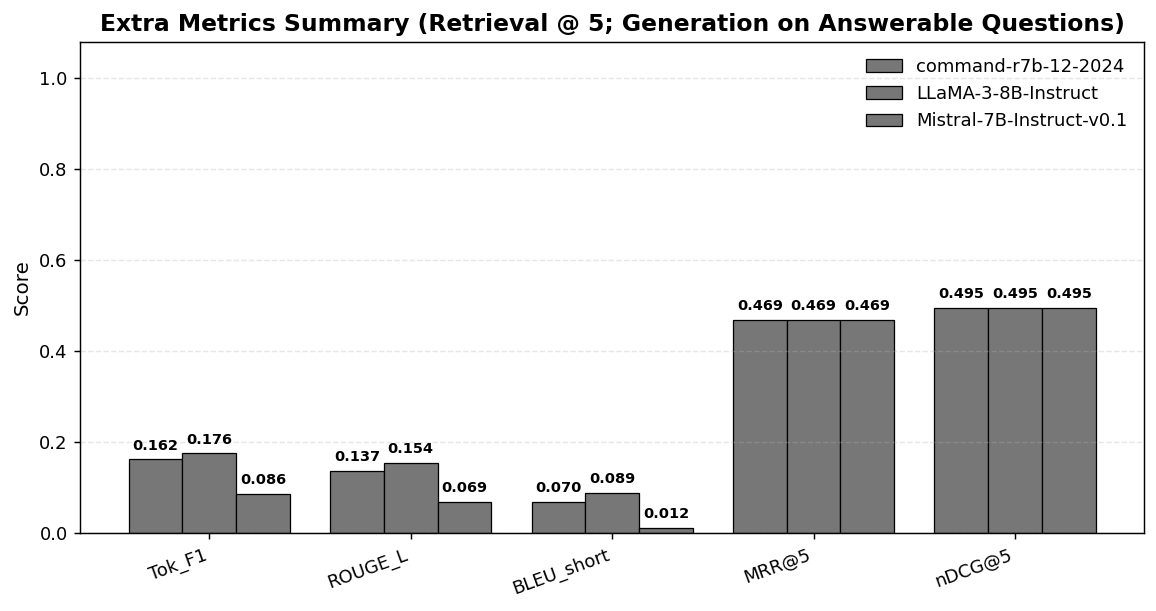

Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_core_grouped_bar.png
Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_core_grouped_bar.pdf


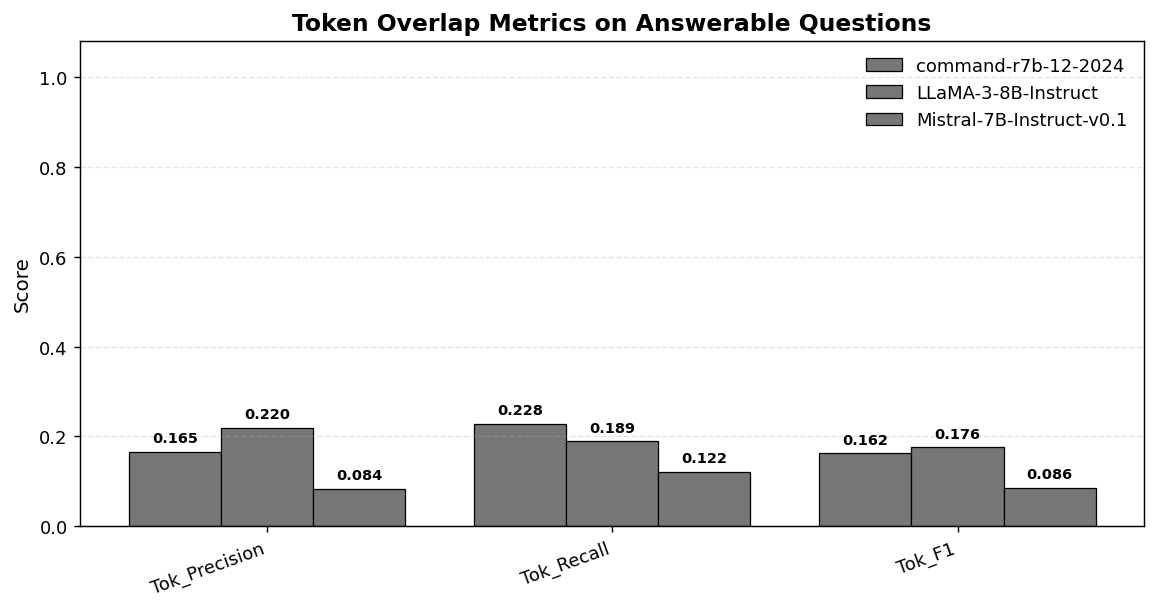

Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_token_prf_grouped_bar.png
Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_token_prf_grouped_bar.pdf


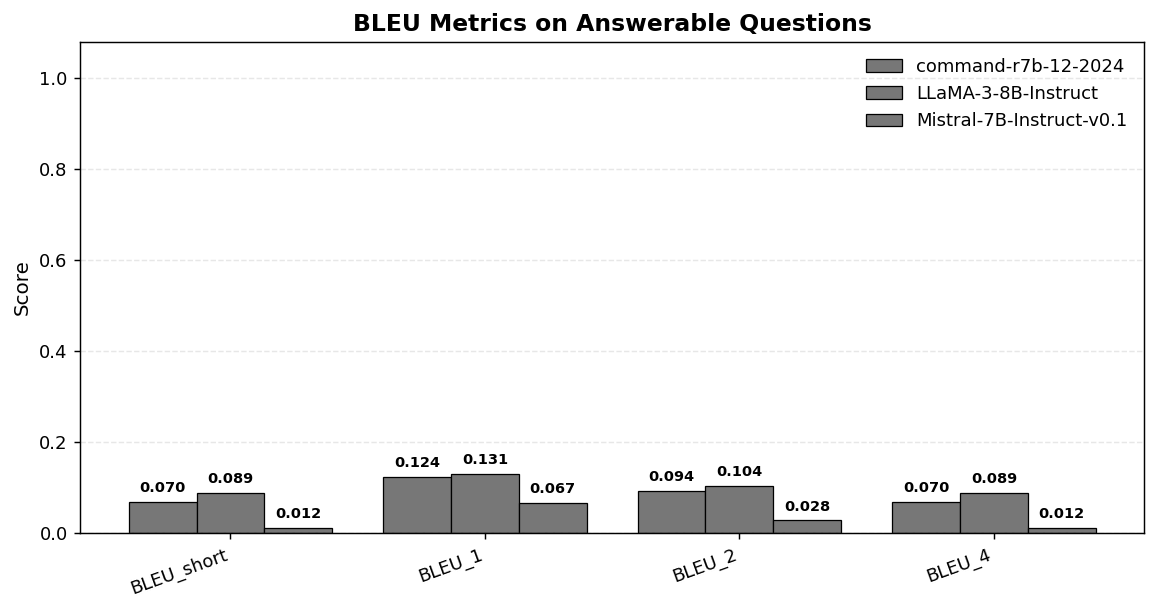

Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_bleu_grouped_bar.png
Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_bleu_grouped_bar.pdf


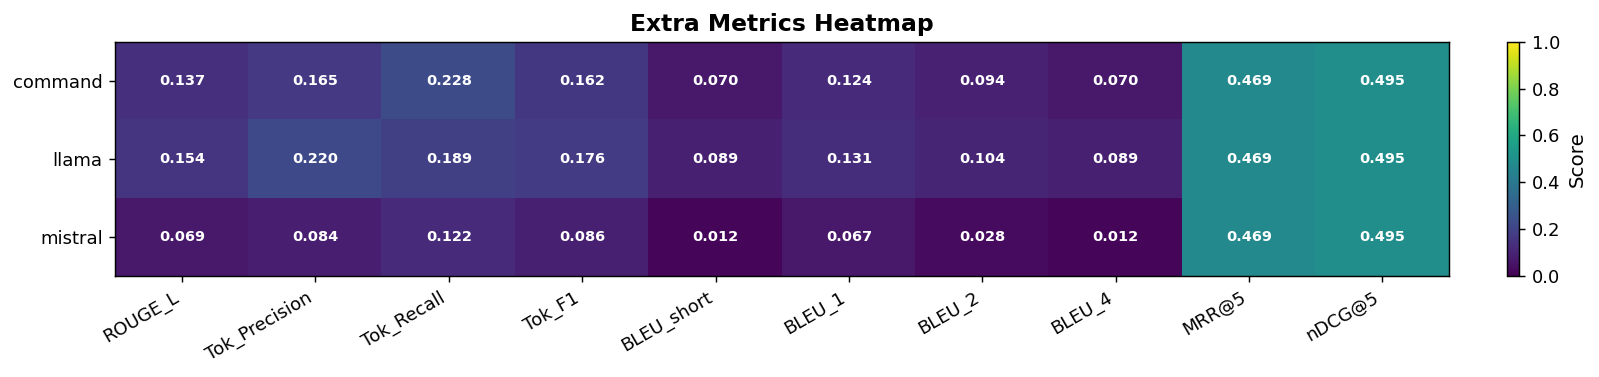

Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_metrics_heatmap.png
Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_metrics_heatmap.pdf


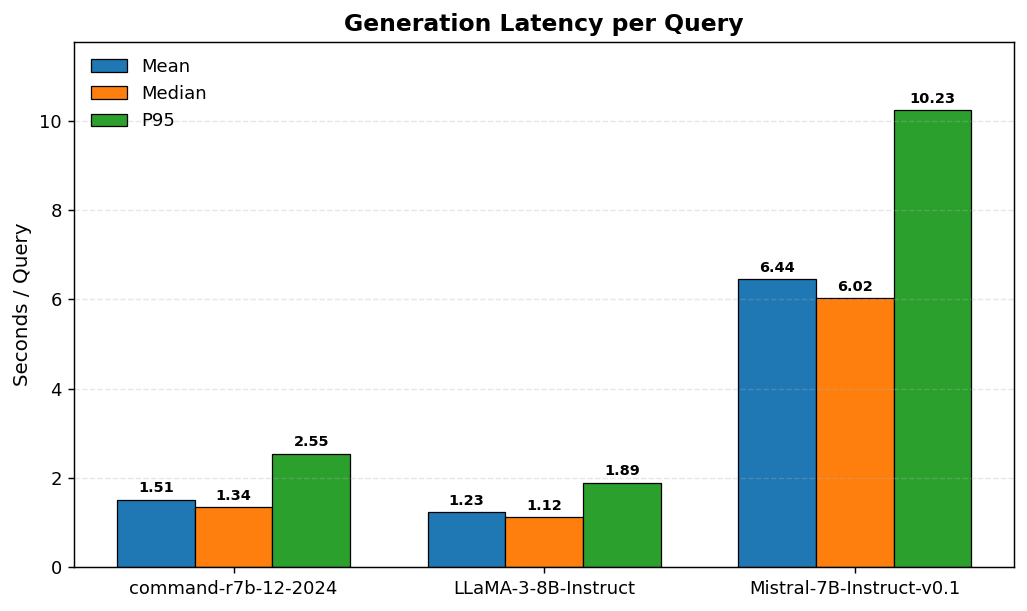

Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_generation_latency.png
Saved: arabicaqa_rag_results\extra_metrics_llama_mistral_command\figures\extra_generation_latency.pdf

Done. Extra metrics and figures saved in: arabicaqa_rag_results\extra_metrics_llama_mistral_command


In [2]:
# ============================================================
# FULL SCRIPT:
# Extra metrics for LLaMA + Mistral + Command
# Uses: comparison_llama_mistral_command_1000.csv
# - Retrieval metrics: MRR@K, nDCG@K
# - Generation metrics: ROUGE-L, BLEU, token Precision/Recall/F1
# - Saves per-question metrics
# - Saves model-level summary
# - Saves figures for 3+ models
# ============================================================

import os
import re
import ast
import math
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import Counter
from matplotlib import colormaps

# ============================================================
# CONFIG
# ============================================================
BASE_DIR = "arabicaqa_rag_results"

PRED_PATH = os.path.join(
    BASE_DIR,
    "predictions",
    "comparison_llama_mistral_command_1000.csv"
)

OUTPUT_DIR = os.path.join(BASE_DIR, "extra_metrics_llama_mistral_command")
FIG_DIR = os.path.join(OUTPUT_DIR, "figures")

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(FIG_DIR, exist_ok=True)

if not os.path.exists(PRED_PATH):
    raise FileNotFoundError(f"Prediction file not found: {PRED_PATH}")

TOPK = 5

CSV_SUMMARY_PATH = os.path.join(OUTPUT_DIR, "extra_metrics_summary.csv")
JSON_SUMMARY_PATH = os.path.join(OUTPUT_DIR, "extra_metrics_summary.json")
CSV_PER_QUESTION_PATH = os.path.join(OUTPUT_DIR, "extra_metrics_per_question.csv")
JSON_PER_QUESTION_PATH = os.path.join(OUTPUT_DIR, "extra_metrics_per_question.json")

MODEL_DISPLAY_NAMES = {
    "command": "command-r7b-12-2024",
    "llama": "LLaMA-3-8B-Instruct",
    "mistral": "Mistral-7B-Instruct-v0.1",
}

# ============================================================
# LOAD
# ============================================================
df_results = pd.read_csv(PRED_PATH, encoding="utf-8-sig")

print("=" * 100)
print("EXTRA METRICS EVALUATION")
print("=" * 100)
print("Loaded:", PRED_PATH)
print("Shape:", df_results.shape)
print("Columns:", list(df_results.columns))

# ============================================================
# REQUIRED COLUMNS
# ============================================================
required_cols = [
    "question",
    "correct_answers",
    "is_impossible",
    "is_answerable",
    "document_id",
    "retrieved_doc_ids",
]

missing = [c for c in required_cols if c not in df_results.columns]
if missing:
    raise KeyError(f"Missing required columns: {missing}")

# ============================================================
# DETECT MODELS
# ============================================================
prediction_prefix = "predicted_answer_"

model_keys = [
    c.replace(prediction_prefix, "")
    for c in df_results.columns
    if c.startswith(prediction_prefix)
]

if not model_keys:
    raise ValueError("No predicted_answer_* columns detected.")

print("\nDetected models:")
for m in model_keys:
    print(" -", m)

# ============================================================
# UTILITIES
# ============================================================
def safe_str(x):
    if x is None:
        return ""
    if isinstance(x, float) and math.isnan(x):
        return ""
    return str(x)

def safe_int(x, default=None):
    try:
        if x is None:
            return default
        if isinstance(x, float) and math.isnan(x):
            return default
        return int(float(x))
    except Exception:
        return default

def parse_bool(x):
    if pd.isna(x):
        return False

    if isinstance(x, bool):
        return x

    if isinstance(x, (int, float)):
        return bool(int(x))

    s = str(x).strip().lower()

    if s in ["true", "1", "yes", "y"]:
        return True

    if s in ["false", "0", "no", "n"]:
        return False

    return False

def parse_maybe_list(x):
    if x is None:
        return []

    if isinstance(x, float) and math.isnan(x):
        return []

    if isinstance(x, list):
        return [str(v).strip() for v in x if str(v).strip()]

    if isinstance(x, str):
        s = x.strip()

        if not s:
            return []

        if s.startswith("[") and s.endswith("]"):
            try:
                parsed = ast.literal_eval(s)
                if isinstance(parsed, list):
                    return [str(v).strip() for v in parsed if str(v).strip()]
            except Exception:
                pass

        return [s]

    return [str(x).strip()] if str(x).strip() else []

def parse_retrieved_doc_ids(x):
    values = parse_maybe_list(x)
    out = []

    for v in values:
        iv = safe_int(v, default=None)
        if iv is not None:
            out.append(iv)

    return out

def first_ref(x):
    refs = parse_maybe_list(x)
    return refs[0] if refs else ""

def normalize_arabic_text(s):
    s = safe_str(s).strip()

    # Remove Arabic diacritics
    s = re.sub(r"[\u064B-\u065F\u0670]", "", s)

    # Normalize Arabic variants
    s = re.sub(r"[إأآا]", "ا", s)
    s = re.sub(r"ى", "ي", s)
    s = re.sub(r"ؤ", "و", s)
    s = re.sub(r"ئ", "ي", s)
    s = re.sub(r"ة", "ه", s)

    # Remove tatweel
    s = re.sub(r"ـ", "", s)

    # Remove punctuation
    s = re.sub(r"[^\w\s\u0600-\u06FF]", " ", s)

    # Normalize whitespace
    s = re.sub(r"\s+", " ", s).strip()

    return s

def tokenize_arabic_simple(s):
    return normalize_arabic_text(s).split()

# ============================================================
# FIX BOOLEAN COLUMNS SAFELY
# ============================================================
df_results["is_impossible"] = df_results["is_impossible"].apply(parse_bool)
df_results["is_answerable"] = df_results["is_answerable"].apply(parse_bool)

print("\nBoolean check:")
print("is_impossible:")
print(df_results["is_impossible"].value_counts(dropna=False))
print("\nis_answerable:")
print(df_results["is_answerable"].value_counts(dropna=False))

# Safety consistency check
inconsistent = (df_results["is_answerable"] == df_results["is_impossible"]).sum()
if inconsistent > 0:
    print(f"\nWARNING: Found {inconsistent} rows where is_answerable == is_impossible.")
    print("Fixing is_answerable as the opposite of is_impossible.")
    df_results["is_answerable"] = ~df_results["is_impossible"]

# ============================================================
# RETRIEVAL METRICS
# ============================================================
def mrr_at_k(gold_doc_id, retrieved_doc_ids, k):
    if gold_doc_id is None or not isinstance(retrieved_doc_ids, list):
        return np.nan

    if len(retrieved_doc_ids) == 0:
        return np.nan

    for i, rid in enumerate(retrieved_doc_ids[:k]):
        if rid == gold_doc_id:
            return 1.0 / (i + 1)

    return 0.0

def ndcg_at_k_single_hit(gold_doc_id, retrieved_doc_ids, k):
    if gold_doc_id is None or not isinstance(retrieved_doc_ids, list):
        return np.nan

    if len(retrieved_doc_ids) == 0:
        return np.nan

    for i, rid in enumerate(retrieved_doc_ids[:k]):
        if rid == gold_doc_id:
            return 1.0 / np.log2(i + 2)

    return 0.0

df_results["gold_document_id_int"] = df_results["document_id"].apply(safe_int)
df_results["retrieved_doc_ids_parsed"] = df_results["retrieved_doc_ids"].apply(parse_retrieved_doc_ids)

print("\nRetrieved doc ids check:")
print(df_results["retrieved_doc_ids_parsed"].head().to_string(index=False))
print("Rows with empty retrieved_doc_ids:", (df_results["retrieved_doc_ids_parsed"].apply(len) == 0).sum())

df_results[f"MRR@{TOPK}"] = df_results.apply(
    lambda r: mrr_at_k(
        r["gold_document_id_int"],
        r["retrieved_doc_ids_parsed"],
        TOPK
    ),
    axis=1
)

df_results[f"nDCG@{TOPK}"] = df_results.apply(
    lambda r: ndcg_at_k_single_hit(
        r["gold_document_id_int"],
        r["retrieved_doc_ids_parsed"],
        TOPK
    ),
    axis=1
)

retrieval_mrr_mean = float(df_results[f"MRR@{TOPK}"].mean(skipna=True))
retrieval_ndcg_mean = float(df_results[f"nDCG@{TOPK}"].mean(skipna=True))

print(f"\n[Retrieval] MRR@{TOPK}: {retrieval_mrr_mean:.6f}")
print(f"[Retrieval] nDCG@{TOPK}: {retrieval_ndcg_mean:.6f}")

# ============================================================
# GENERATION METRICS
# ============================================================
def token_prf_single(pred, ref):
    pred_tokens = tokenize_arabic_simple(pred)
    ref_tokens = tokenize_arabic_simple(ref)

    if len(pred_tokens) == 0 and len(ref_tokens) == 0:
        return 1.0, 1.0, 1.0

    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0, 0.0, 0.0

    pred_counts = Counter(pred_tokens)
    ref_counts = Counter(ref_tokens)

    overlap = sum((pred_counts & ref_counts).values())

    precision = overlap / len(pred_tokens)
    recall = overlap / len(ref_tokens)
    f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) > 0 else 0.0

    return precision, recall, f1

def lcs_length(a, b):
    n, m = len(a), len(b)

    if n == 0 or m == 0:
        return 0

    dp = [0] * (m + 1)

    for i in range(1, n + 1):
        prev = 0
        for j in range(1, m + 1):
            temp = dp[j]
            if a[i - 1] == b[j - 1]:
                dp[j] = prev + 1
            else:
                dp[j] = max(dp[j], dp[j - 1])
            prev = temp

    return dp[m]

def rouge_l_single(pred, ref):
    pred_tokens = tokenize_arabic_simple(pred)
    ref_tokens = tokenize_arabic_simple(ref)

    if len(pred_tokens) == 0 and len(ref_tokens) == 0:
        return 1.0

    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0

    lcs = lcs_length(pred_tokens, ref_tokens)

    precision = lcs / len(pred_tokens)
    recall = lcs / len(ref_tokens)

    if precision + recall == 0:
        return 0.0

    beta = precision / (recall + 1e-12)
    rouge_l = ((1 + beta**2) * precision * recall) / (recall + beta**2 * precision + 1e-12)

    return float(rouge_l)

def modified_precision(pred_tokens, ref_tokens, n):
    if len(pred_tokens) < n:
        return 0.0

    pred_ngrams = Counter(tuple(pred_tokens[i:i+n]) for i in range(len(pred_tokens) - n + 1))
    ref_ngrams = Counter(tuple(ref_tokens[i:i+n]) for i in range(len(ref_tokens) - n + 1))

    overlap = sum((pred_ngrams & ref_ngrams).values())
    total = sum(pred_ngrams.values())

    if total == 0:
        return 0.0

    return overlap / total

def bleu_score(pred, ref, max_n=4):
    pred_tokens = tokenize_arabic_simple(pred)
    ref_tokens = tokenize_arabic_simple(ref)

    if len(pred_tokens) == 0 and len(ref_tokens) == 0:
        return 1.0

    if len(pred_tokens) == 0 or len(ref_tokens) == 0:
        return 0.0

    effective_n = min(max_n, len(pred_tokens), len(ref_tokens))

    if effective_n <= 0:
        return 0.0

    precisions = []

    for n in range(1, effective_n + 1):
        p = modified_precision(pred_tokens, ref_tokens, n)
        # smoothing
        if p == 0:
            p = 1e-9
        precisions.append(p)

    log_precision = sum(math.log(p) for p in precisions) / effective_n

    pred_len = len(pred_tokens)
    ref_len = len(ref_tokens)

    if pred_len > ref_len:
        bp = 1.0
    else:
        bp = math.exp(1 - ref_len / pred_len)

    return float(bp * math.exp(log_precision))

def bleu_single(pred, ref):
    bleu_short = bleu_score(pred, ref, max_n=4)
    bleu_1 = bleu_score(pred, ref, max_n=1)
    bleu_2 = bleu_score(pred, ref, max_n=2)
    bleu_4 = bleu_score(pred, ref, max_n=4)

    return bleu_short, bleu_1, bleu_2, bleu_4

# ============================================================
# COMPUTE PER-QUESTION METRICS
# ============================================================
per_question_rows = []

for _, row in df_results.iterrows():
    base = {
        "row_idx": row.get("row_idx", row.name),
        "question_id": row.get("question_id", ""),
        "document_id": row.get("document_id", ""),
        "question": row.get("question", ""),
        "is_impossible": bool(row.get("is_impossible", False)),
        "is_answerable": bool(row.get("is_answerable", False)),
        f"MRR@{TOPK}": row.get(f"MRR@{TOPK}", np.nan),
        f"nDCG@{TOPK}": row.get(f"nDCG@{TOPK}", np.nan),
    }

    ref = first_ref(row.get("correct_answers", ""))

    for model_key in model_keys:
        pred_col = f"predicted_answer_{model_key}"
        gen_latency_col = f"latency_sec_{model_key}"
        error_col = f"error_{model_key}"

        pred = row.get(pred_col, "")

        out = base.copy()
        out["model"] = model_key
        out["prediction"] = pred
        out["reference"] = ref

        out["generation_latency_sec"] = row.get(gen_latency_col, np.nan) if gen_latency_col in df_results.columns else np.nan
        out["error"] = row.get(error_col, "") if error_col in df_results.columns else ""

        if bool(row.get("is_answerable", False)):
            tok_p, tok_r, tok_f1 = token_prf_single(pred, ref)
            rouge_l = rouge_l_single(pred, ref)
            bleu_short, bleu_1, bleu_2, bleu_4 = bleu_single(pred, ref)
        else:
            tok_p, tok_r, tok_f1 = np.nan, np.nan, np.nan
            rouge_l = np.nan
            bleu_short, bleu_1, bleu_2, bleu_4 = np.nan, np.nan, np.nan, np.nan

        out["Tok_Precision"] = tok_p
        out["Tok_Recall"] = tok_r
        out["Tok_F1"] = tok_f1
        out["ROUGE_L"] = rouge_l
        out["BLEU_short"] = bleu_short
        out["BLEU_1"] = bleu_1
        out["BLEU_2"] = bleu_2
        out["BLEU_4"] = bleu_4

        per_question_rows.append(out)

df_extra_pq = pd.DataFrame(per_question_rows)

# ============================================================
# SUMMARY
# ============================================================
generation_metric_cols = [
    "ROUGE_L",
    "Tok_Precision",
    "Tok_Recall",
    "Tok_F1",
    "BLEU_short",
    "BLEU_1",
    "BLEU_2",
    "BLEU_4",
]

summary_rows = []

for model_key in model_keys:
    df_m = df_extra_pq[df_extra_pq["model"] == model_key].copy()
    df_m_ans = df_m[df_m["is_answerable"] == True].copy()

    row = {
        "model": model_key,
        "n_questions_all": int(len(df_m)),
        "n_questions_answerable": int(len(df_m_ans)),
        f"MRR@{TOPK}": float(df_m[f"MRR@{TOPK}"].mean(skipna=True)),
        f"nDCG@{TOPK}": float(df_m[f"nDCG@{TOPK}"].mean(skipna=True)),
        "generation_latency_mean_sec": float(df_m["generation_latency_sec"].mean(skipna=True)),
        "generation_latency_median_sec": float(df_m["generation_latency_sec"].median(skipna=True)),
        "generation_latency_p95_sec": float(df_m["generation_latency_sec"].quantile(0.95)),
    }

    for metric_name in generation_metric_cols:
        row[metric_name] = float(df_m_ans[metric_name].mean(skipna=True))

    summary_rows.append(row)

df_summary = pd.DataFrame(summary_rows)

# ============================================================
# SAVE
# ============================================================
df_extra_pq.to_csv(CSV_PER_QUESTION_PATH, index=False, encoding="utf-8-sig")
df_extra_pq.to_json(JSON_PER_QUESTION_PATH, orient="records", force_ascii=False, indent=2)

df_summary.to_csv(CSV_SUMMARY_PATH, index=False, encoding="utf-8-sig")
df_summary.to_json(JSON_SUMMARY_PATH, orient="records", force_ascii=False, indent=2)

print("\nSaved:")
print("Per-question CSV:", CSV_PER_QUESTION_PATH)
print("Per-question JSON:", JSON_PER_QUESTION_PATH)
print("Summary CSV:", CSV_SUMMARY_PATH)
print("Summary JSON:", JSON_SUMMARY_PATH)

print("\nExtra metrics summary:")
print(df_summary.round(4).to_string(index=False))

df_summary_plot = df_summary.copy()
df_summary_plot["model"] = df_summary_plot["model"].map(
    lambda x: MODEL_DISPLAY_NAMES.get(str(x), str(x))
)

# ============================================================
# PLOTTING
# ============================================================
plt.rcParams["figure.dpi"] = 130
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["axes.titleweight"] = "bold"
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 13

MODEL_COLORS = {
    "Command-R7B-12-2024": "#0F9D58",
    "LLaMA-3-8B-Instruct": "#3A70B8",
    "Mistral-7B-Instruct-v0.1": "#7C3AED",
}

DEFAULT_COLOR = "#777777"

def save_and_show(fig, name):
    png = os.path.join(FIG_DIR, f"{name}.png")
    pdf = os.path.join(FIG_DIR, f"{name}.pdf")

    fig.tight_layout()
    fig.savefig(png, bbox_inches="tight")
    fig.savefig(pdf, bbox_inches="tight")

    plt.show()
    plt.close(fig)

    print("Saved:", png)
    print("Saved:", pdf)

def grouped_bar(df, metrics, title, ylabel, filename):
    models = df["model"].astype(str).tolist()
    x = np.arange(len(metrics))
    width = 0.8 / max(len(models), 1)

    fig, ax = plt.subplots(figsize=(max(9, len(metrics) * 1.25), 4.8))

    for i, model in enumerate(models):
        values = (
            df[df["model"].astype(str) == model][metrics]
            .iloc[0]
            .astype(float)
            .values
        )

        offset = (i - (len(models) - 1) / 2) * width

        bars = ax.bar(
            x + offset,
            values,
            width,
            label=model,
            color=MODEL_COLORS.get(model.lower(), DEFAULT_COLOR),
            edgecolor="black",
            linewidth=0.7
        )

        # Add value labels on top of bars
        for bar, value in zip(bars, values):
            if np.isnan(value):
                continue

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.015,
                f"{value:.3f}",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold"
            )

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=20, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_ylim(0, 1.08)
    ax.set_title(title)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(frameon=False)

    save_and_show(fig, filename)

# ============================================================
# CORE METRICS FIGURE
# ============================================================
core_metrics = [
    "Tok_F1",
    "ROUGE_L",
    "BLEU_short",
    f"MRR@{TOPK}",
    f"nDCG@{TOPK}",
]
core_metrics = [m for m in core_metrics if m in df_summary.columns]



grouped_bar(
    df_summary_plot,
    core_metrics,
    f"Extra Metrics Summary (Retrieval @ {TOPK}; Generation on Answerable Questions)",
    "Score",
    "extra_core_grouped_bar"
)

# ============================================================
# TOKEN PRF FIGURE
# ============================================================
prf_metrics = ["Tok_Precision", "Tok_Recall", "Tok_F1"]
prf_metrics = [m for m in prf_metrics if m in df_summary.columns]

grouped_bar(
    df_summary_plot,
    prf_metrics,
    "Token Overlap Metrics on Answerable Questions",
    "Score",
    "extra_token_prf_grouped_bar"
)

# ============================================================
# BLEU FIGURE
# ============================================================
bleu_metrics = ["BLEU_short", "BLEU_1", "BLEU_2", "BLEU_4"]
bleu_metrics = [m for m in bleu_metrics if m in df_summary.columns]

grouped_bar(
    df_summary_plot,
    bleu_metrics,
    "BLEU Metrics on Answerable Questions",
    "Score",
    "extra_bleu_grouped_bar"
)

# ============================================================
# HEATMAP
# ============================================================
heat_metrics = [
    "ROUGE_L",
    "Tok_Precision",
    "Tok_Recall",
    "Tok_F1",
    "BLEU_short",
    "BLEU_1",
    "BLEU_2",
    "BLEU_4",
    f"MRR@{TOPK}",
    f"nDCG@{TOPK}",
]
heat_metrics = [m for m in heat_metrics if m in df_summary.columns]

if heat_metrics:
    mat = df_summary.set_index("model")[heat_metrics].astype(float)

    cmap = colormaps["viridis"].copy()
    cmap.set_bad(color="lightgray")

    masked_values = np.ma.masked_invalid(mat.values)

    fig, ax = plt.subplots(figsize=(12.5, max(3.0, 0.65 * len(mat))))

    im = ax.imshow(masked_values, aspect="auto", vmin=0, vmax=1, cmap=cmap)

    ax.set_title("Extra Metrics Heatmap")
    ax.set_yticks(np.arange(len(mat.index)))
    ax.set_yticklabels(mat.index.tolist())

    ax.set_xticks(np.arange(len(mat.columns)))
    ax.set_xticklabels(mat.columns.tolist(), rotation=30, ha="right")

    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            val = mat.values[i, j]

            if np.isnan(val):
                label = "NA"
                text_color = "black"
            else:
                label = f"{val:.3f}"
                rgba = im.cmap(im.norm(val))
                r, g, b, _ = rgba
                luminance = 0.299 * r + 0.587 * g + 0.114 * b
                text_color = "black" if luminance > 0.55 else "white"

            ax.text(
                j,
                i,
                label,
                ha="center",
                va="center",
                fontsize=8,
                color=text_color,
                fontweight="bold"
            )

    cbar = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cbar.set_label("Score")

    save_and_show(fig, "extra_metrics_heatmap")

# ============================================================
# LATENCY FIGURE
# ============================================================
latency_metrics = [
    "generation_latency_mean_sec",
    "generation_latency_median_sec",
    "generation_latency_p95_sec",
]
latency_metrics = [m for m in latency_metrics if m in df_summary.columns]

if latency_metrics:
    models = df_summary_plot["model"].unique()
    x = np.arange(len(models))
    width = 0.25

    fig, ax = plt.subplots(figsize=(8, 4.8))

    bars_mean = ax.bar(
        x - width,
        df_summary_plot["generation_latency_mean_sec"],
        width,
        label="Mean",
        edgecolor="black",
        linewidth=0.7
    )

    bars_median = ax.bar(
        x,
        df_summary_plot["generation_latency_median_sec"],
        width,
        label="Median",
        edgecolor="black",
        linewidth=0.7
    )

    bars_p95 = ax.bar(
        x + width,
        df_summary_plot["generation_latency_p95_sec"],
        width,
        label="P95",
        edgecolor="black",
        linewidth=0.7
    )

    # Add value labels on top of latency bars
    for bars in [bars_mean, bars_median, bars_p95]:
        for bar in bars:
            value = bar.get_height()

            if np.isnan(value):
                continue

            ax.text(
                bar.get_x() + bar.get_width() / 2,
                value + (0.01 * df_summary_plot["generation_latency_p95_sec"].max()),
                f"{value:.2f}",
                ha="center",
                va="bottom",
                fontsize=8,
                fontweight="bold"
            )

    ax.set_title("Generation Latency per Query")
    ax.set_ylabel("Seconds / Query")
    ax.set_xticks(x)
    ax.set_xticklabels(models)
    ax.grid(axis="y", linestyle="--", alpha=0.3)
    ax.legend(frameon=False)

    # Add extra space above bars for labels
    ymax = df_summary_plot["generation_latency_p95_sec"].max()
    ax.set_ylim(0, ymax * 1.15)

    save_and_show(fig, "extra_generation_latency")

print("\nDone. Extra metrics and figures saved in:", OUTPUT_DIR)